In [1]:
import os
os.environ["PATH"] = "/global/common/software/nersc9/texlive/2024/bin/x86_64-linux:" + os.environ["PATH"]

In [2]:
%matplotlib inline

import importlib.util
import json
import sys
import pickle
from pathlib import Path



In [3]:
import corner
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch
from astropy import units as u
from astropy.coordinates import SkyCoord, Galactocentric, ICRS
from numpy.random import PCG64, SeedSequence
from ml_collections import ConfigDict



/global/homes/e/emarin4/.conda/envs/sbi-stream/lib/python3.10/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [4]:
import time
t0 = time.time(); import sbi_stream; print('sbi_stream:', time.time()-t0)

sbi_stream: 0.003348112106323242


In [5]:
sys.path.append('/home/tvnguyen/projects/sbi_stream/ella_code/sbi_stream')

import sbi_stream
from sbi_stream.transforms import build_transformation
from sbi_stream.models import NPE, GNNEmbedding, TransformerEmbedding



In [6]:
torch.set_num_threads(8)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

device: cuda


### Read in the config file and the PS mock data

In [7]:
def json_to_config_dict(json_path: str) -> ConfigDict:
    with open(json_path, "r") as f:
        config_data = json.load(f)
    return ConfigDict(config_data)

config = json_to_config_dict('/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/ella_config_2mil_9d_nocorr_withuncert_newnorm.json')
model_config = config.model.value
pre_transforms_config = config.pre_transforms.value
norm_dict = config.norm_dict.value

features = config.data.value.features
labels = config.data.value.labels
print('features:', features)
print('labels:', labels)
#print('phi1-min:', config.data.value.phi1_min)
#print('phi1-max:', config.features.phi1_max)
phi1_min, phi1_max = -20, 16

features: ['phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist']
labels: ['log_mass', 'log_scale_radius', 'phi1_impact_today', 'time_impact', 'impact_parameter', 'v_rel_para', 'v_rel_perp', 'angle_pos_at_impact', 'delta_angle']


In [8]:
import pandas as pd
from torch_geometric.data import Data

aau_path = '/global/homes/e/emarin4/scratch/training_sims/aau_sbi_fastsims/workspace/vel_disp_test/combined_members_prepared.csv'
aau = pd.read_csv(aau_path)
print(f"Total AAU stars (before phi1 cut): {len(aau)}")

# Apply the same phi1 window used elsewhere so the inference dataset matches it
# aau = aau[(aau['phi1'] >= phi1_min) & (aau['phi1'] < phi1_max)].reset_index(drop=True)
# print(f"Total AAU stars (after phi1 cut [{phi1_min}, {phi1_max})): {len(aau)}")

# --- Add new synthetic stars that follow the REAL AAU kink, not the simulated
# unperturbed track ---
# Fit each feature locally to the real AAU data in/around the kink itself, so
# new stars land on the observed higher-phi2 branch, not the smooth simulated
# orbit (which has no kink to begin with).

# kink_phi1_min, kink_phi1_max = -15, -9   # <-- match the kink's actual phi1 extent
# fit_buffer = 1        # small padding around the kink window for the local fit
# fit_degree = 3         # keep low -- this fit must stay local, not average over the whole stream
# n_new_stars = 50
# density_seed = 123
# density_rng = np.random.default_rng(density_seed)

# fit_mask = (aau['phi1'] >= kink_phi1_min - fit_buffer) & (aau['phi1'] < kink_phi1_max + fit_buffer)
# aau_local = aau[fit_mask]
# print(f"Fitting local kink track to {len(aau_local)} real stars in "
#       f"[{kink_phi1_min - fit_buffer}, {kink_phi1_max + fit_buffer})")

# new_phi1 = density_rng.uniform(kink_phi1_min, kink_phi1_max, size=n_new_stars)
# new_rows = {'phi1': new_phi1}

# # keep the fitted coeffs around so the mock-plotting cell can overlay them
# kink_local_tracks = {}
# kink_fit_phi1_min = kink_phi1_min - fit_buffer
# kink_fit_phi1_max = kink_phi1_max + fit_buffer

# peak_phi1, peak_phi2 = -10.0, 2.0  # <-- vertex of the AAU kink (upside-down V)

# for col in ['phi2', 'vel_calib', 'pm1', 'pm2', 'distance_kpc']:
#     if col == 'phi2':
#         # skewed upside-down V: fit each side's slope separately from the real
#         # local data, pinned through the (peak_phi1, peak_phi2) vertex --
#         # a smooth polynomial arch can't represent a sharp, asymmetric kink
#         left_mask  = aau_local['phi1'] < peak_phi1
#         right_mask = ~left_mask

#         def _slope_through_peak(mask):
#             dx = aau_local.loc[mask, 'phi1'].values - peak_phi1
#             dy = aau_local.loc[mask, 'phi2'].values - peak_phi2
#             return (dx * dy).sum() / (dx * dx).sum()

#         slope_left  = _slope_through_peak(left_mask)
#         slope_right = _slope_through_peak(right_mask)

#         def local_track(phi1_vals, _sl=slope_left, _sr=slope_right):
#             phi1_vals = np.asarray(phi1_vals, dtype=float)
#             slopes = np.where(phi1_vals < peak_phi1, _sl, _sr)
#             return peak_phi2 + slopes * (phi1_vals - peak_phi1)

#         resid_std = (aau_local['phi2'] - local_track(aau_local['phi1'])).std()
#     else:
#         coeffs = np.polyfit(aau_local['phi1'], aau_local[col], deg=fit_degree)
#         local_track = np.poly1d(coeffs)
#         resid_std = (aau_local[col] - local_track(aau_local['phi1'])).std()

#     new_rows[col] = local_track(new_phi1) + density_rng.normal(0, resid_std, size=n_new_stars)
#     kink_local_tracks[col] = local_track

# # realistic per-star uncertainties: resample from the same local real stars
# err_idx = density_rng.choice(len(aau_local), size=n_new_stars, replace=True)
# for err_col in ['pm1_error', 'pm2_error', 'vr_error']:
#     new_rows[err_col] = aau_local[err_col].values[err_idx]

# new_stars = pd.DataFrame(new_rows)
# aau = pd.concat([aau, new_stars], ignore_index=True)
# print(f"Added {n_new_stars} synthetic stars along the AAU kink [{kink_phi1_min}, {kink_phi1_max}); "
#       f"total AAU stars now {len(aau)}")

# # --- Add extra stars stacked vertically in phi2 at the kink peak, to push the
# # observed peak phi2 even higher than the V-fit reaches (needs the block
# # above to have run: uses kink_local_tracks, aau_local, peak_phi1, peak_phi2) ---
# n_extra_vertical = 20            # <-- how many extra stars to add
# extra_phi2_max = 4.5              # <-- how high in phi2 to stack them (must exceed peak_phi2)
# vertical_phi1_half_width = 1.5    # keep these tightly clustered in phi1 near the peak

# extra_phi1 = density_rng.uniform(peak_phi1 - vertical_phi1_half_width,
#                                   peak_phi1 + vertical_phi1_half_width,
#                                   size=n_extra_vertical)
# extra_phi2 = density_rng.uniform(peak_phi2, extra_phi2_max, size=n_extra_vertical)
# extra_rows = {'phi1': extra_phi1, 'phi2': extra_phi2}

# for col in ['vel_calib', 'pm1', 'pm2', 'distance_kpc']:
#     col_resid_std = (aau_local[col] - kink_local_tracks[col](aau_local['phi1'])).std()
#     extra_rows[col] = kink_local_tracks[col](extra_phi1) + density_rng.normal(0, col_resid_std, size=n_extra_vertical)

# err_idx_extra = density_rng.choice(len(aau_local), size=n_extra_vertical, replace=True)
# for err_col in ['pm1_error', 'pm2_error', 'vr_error']:
#     extra_rows[err_col] = aau_local[err_col].values[err_idx_extra]

# extra_stars = pd.DataFrame(extra_rows)
# aau = pd.concat([aau, extra_stars], ignore_index=True)
# print(f"Added {n_extra_vertical} extra vertical stars near phi1={peak_phi1}, "
#       f"phi2 in [{peak_phi2}, {extra_phi2_max}]; total AAU stars now {len(aau)}")





seed = 27 
rng = np.random.default_rng(seed)

dist_values    = aau['distance_kpc'].values.astype(np.float32)
dist_noise     = rng.normal(loc=0, scale=0.1 * np.abs(dist_values))
dist_perturbed = dist_values + dist_noise

# Save alongside phi1 so the plotting notebook can align rows safely
dist_pert_out = pd.DataFrame({
    'phi1': aau['phi1'].values,
    'distance_kpc_raw': dist_values,
    'distance_kpc_perturbed': dist_perturbed,
})
dist_pert_path = '/global/homes/e/emarin4/scratch/training_sims/aau_sbi_fastsims/workspace/vel_disp_test/aau_dist_perturbed_seed27.csv'
dist_pert_out.to_csv(dist_pert_path, index=False)


# Build feature matrix with perturbed distances
feat = np.column_stack([
    aau['phi1'].values,
    aau['phi2'].values,
    aau['vel_calib'].values,
    aau['pm1'].values,
    aau['pm2'].values,
    dist_perturbed,            # <-- perturbed instead of raw
]).astype(np.float32)

# USE for no dist uncertainties: Build feature matrix matching training order: ['phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist']
# feat = np.column_stack([
#     aau['phi1'].values,
#     aau['phi2'].values,
#     aau['vel_calib'].values,
#     aau['pm1'].values,
#     aau['pm2'].values,
#     aau['distance_kpc'].values,
# ]).astype(np.float32)

# Real observed uncertainties: [pm1_err, pm2_err, vr_err]
feat_unc = np.column_stack([
    aau['pm1_error'].values,
    aau['pm2_error'].values,
    aau['vr_error'].values,
]).astype(np.float32)

x = np.concatenate([feat, feat_unc], axis=1)  # (N, 9)

pos = np.column_stack([aau['phi1'].values, aau['phi2'].values]).astype(np.float32)

dummy_y = torch.zeros(1, len(labels), dtype=torch.float32)

graph = Data(
    x=torch.tensor(x, dtype=torch.float32),
    y=dummy_y,
    pos=torch.tensor(pos, dtype=torch.float32),
)

data = [graph]
print(data)
print(f"x shape: {graph.x.shape}")

Total AAU stars (before phi1 cut): 150
[Data(x=[150, 9], y=[1, 9], pos=[150, 2])]
x shape: torch.Size([150, 9])


In [9]:
print(aau.columns)

Index(['gaia_source_id', 'ra', 'dec', 'pmra', 'pmdec', 'phi1', 'phi2',
       'distance_modulus', 'vel_calib', 'file_location', 'dm_imputed',
       'distance_kpc', 'vel_imputed', 'pm1', 'pm2', 'vr_error', 'pm1_error',
       'pm2_error'],
      dtype='object')


log_mass: 0.0000
log_scale_radius: 0.0000
phi1_impact_today: 0.0000
time_impact: 0.0000
impact_parameter: 0.0000
v_rel_para: 0.0000
v_rel_perp: 0.0000
angle_pos_at_impact: 0.0000
delta_angle: 0.0000


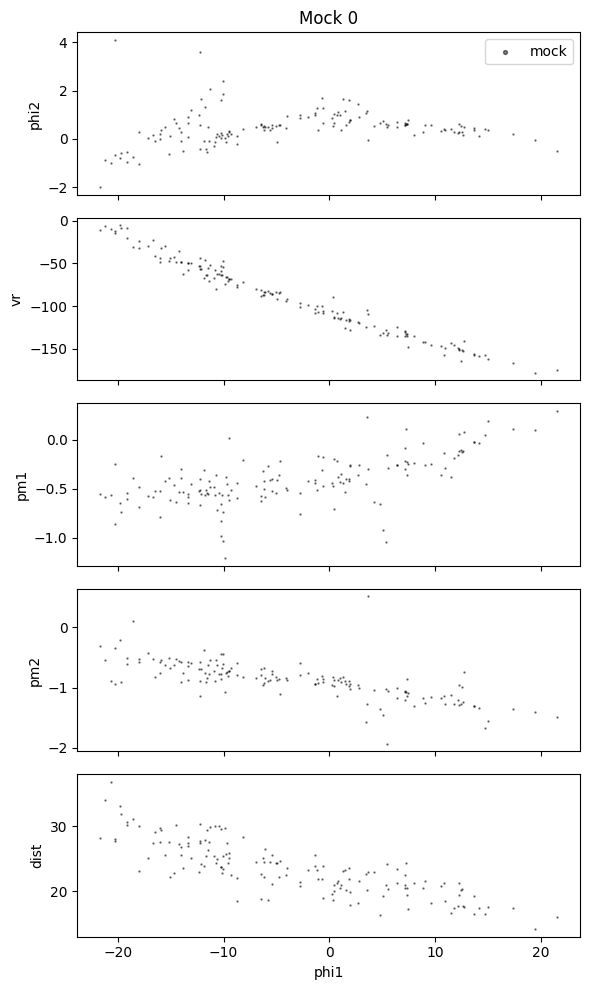

In [10]:
#Looking at 1 mock for testing

labels = ['log_mass', 'log_scale_radius', 'phi1_impact_today', 'time_impact',
          'impact_parameter', 'v_rel_para', 'v_rel_perp',
          'angle_pos_at_impact', 'delta_angle', 'angle_vel_at_impact', 'delta_phi1']

i = 0 #73
d = data[i]

truths = d.y.squeeze(0).numpy()
true_params_dict = dict(zip(labels, truths))

#Look at truths
for l, v in true_params_dict.items():
    print(f"{l}: {v:.4f}")

#Plot the stream
stream = d.x.numpy()   
phi1 = stream[:, 0]

# Fitted AAU tracks (phi2, vr, pm1, pm2 vs phi1) used elsewhere to detrend/
# normalize model inputs -- overlaid here as a sanity check on the raw mock.
import pickle as _pickle


# feature name -> aau column name, to look up the local kink fit made in the
# data-setup cell (kink_local_tracks), if that block was run
feat_to_kink_col = {'phi2': 'phi2', 'vr': 'vel_calib', 'pm1': 'pm1', 'pm2': 'pm2', 'dist': 'distance_kpc'}
kink_tracks_available = 'kink_local_tracks' in globals()

features = ['phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist']
fig, axes = plt.subplots(5, figsize=(6, 10), sharex=True)
for j, ax in enumerate(axes):
    feat = features[j + 1]
    coord = stream[:, 1 + j]
    ax.scatter(phi1, coord, s=0.5, c='k', alpha=0.5, label='mock')


    # kink_col = feat_to_kink_col.get(feat)
    # if kink_tracks_available and kink_col in kink_local_tracks:
    #     kink_track = kink_local_tracks[kink_col]  # already callable (poly1d or the phi2 V-function)
    #     kink_phi1_fine = np.linspace(kink_fit_phi1_min, kink_fit_phi1_max, 100)
    #     ax.plot(kink_phi1_fine, kink_track(kink_phi1_fine), color='tab:green', lw=2, label='AAU kink fit')

    ax.set_ylabel(features[j+1])  

axes[0].legend(loc='upper right', markerscale=4)
axes[-1].set_xlabel(features[0])
axes[0].set_title(f'Mock {i}')
plt.tight_layout()
plt.show()


In [11]:
# import pandas as pd
# aau_path = '/global/homes/e/emarin4/scratch/training_sims/aau_sbi_fastsims/workspace/vel_disp_test/combined_members_prepared.csv'
# aau = pd.read_csv(aau_path)

# # Apply same phi1 window
# aau_cut = aau[(aau['phi1'] >= phi1_min) & (aau['phi1'] < phi1_max)]

# aau_cols = {
#     'phi2': 'phi2',
#     'vr':   'vel_calib',
#     'pm1':  'pm1',
#     'pm2':  'pm2',
#     'dist': 'distance_kpc',
# }

# fig, axes = plt.subplots(5, figsize=(6, 10), sharex=True)
# for j, ax in enumerate(axes):
#     feat = features[j + 1]
#     ax.scatter(phi1_ps,                stream_ps[:, 1 + j],          s=0.5,  c='steelblue', alpha=0.5, label='PS')
#     ax.scatter(phi1_nbody,             stream_nbody[:, 1 + j],        s=0.5,  c='k',         alpha=0.5, label='N-body')
#     ax.scatter(aau_cut['phi1'].values, aau_cut[aau_cols[feat]].values, s=2,    c='crimson',   alpha=0.9, label='AAU', zorder=5)
#     ax.set_ylabel(feat)

# axes[0].legend(markerscale=4, loc='upper right')
# axes[-1].set_xlabel('phi1')
# axes[0].set_title('N-body vs PS vs AAU data')
# plt.tight_layout()
# plt.show()

### Read in the model

In [12]:
def build_embedding(model_config: ConfigDict):
    """Build a fresh (randomly initialized) embedding network.

    Args:
        model_config: Architecture config with a `model.embedding` section
            (see configs/debug.py / scripts/train_npe.py's config.model).

    Returns:
        A freshly constructed GNNEmbedding or TransformerEmbedding.

    Raises:
        ValueError: If `model_config.embedding.type` is not recognized.
    """
    embed_cfg = model_config.embedding
    model_type = embed_cfg.get('type', 'gnn')
    if model_type == 'gnn':
        return GNNEmbedding(
            input_size=model_config.input_size,
            gnn_args=embed_cfg.gnn,
            mlp_args=embed_cfg.mlp,
            loss_type=embed_cfg.get('loss_type', 'mse'),
            loss_args=embed_cfg.get('loss_args', None),
            conditional_mlp_args=embed_cfg.get('conditional_mlp', None),
            # NPE handles optimizer, scheduler, and pre_transforms
            optimizer_args=None,
            scheduler_args=None,
            pre_transforms=None,
        )
    elif model_type == 'transformer':
        return TransformerEmbedding(
            input_size=model_config.input_size,
            transformer_args=embed_cfg.transformer,
            loss_type=embed_cfg.get('loss_type', 'mse'),
            loss_args=embed_cfg.get('loss_args', None),
            mlp_args=embed_cfg.get('mlp', None),
            optimizer_args=None,
            scheduler_args=None,
            pre_transforms=None,
        )
    raise ValueError(f"Unsupported embedding model type: {model_type}")


def build_npe(
    model_config: ConfigDict,
    pre_transforms,
    norm_dict: dict,
    optimizer_args: ConfigDict = None,
    scheduler_args: ConfigDict = None,
):
    """Build a fresh NPE model, ready to have a checkpoint's weights loaded in.

    Args:
        model_config: Architecture config (round_0/model_config.json).
        pre_transforms: Pre-transformation pipeline passed to NPE.
        norm_dict: Fixed normalization dict for the whole run.
        optimizer_args: Optimizer config for this round's training.
        scheduler_args: Scheduler config for this round's training.

    Returns:
        A freshly constructed (randomly initialized) NPE model with the
        stored architecture. Call `load_state_dict` (or use
        `jgnn.training.fit(..., reset_optimizer=True)`) to warm-start it
        from a previous round's checkpoint.
    """
    embedding_nn = build_embedding(model_config)
    return NPE(
        input_size=model_config.input_size,
        output_size=model_config.output_size,
        flows_args=model_config.flows,
        embedding_nn=embedding_nn,
        optimizer_args=optimizer_args,
        scheduler_args=scheduler_args,
        norm_dict=norm_dict,
        pre_transforms=pre_transforms,
        init_flows_from_embedding=False,
    )

In [13]:
pre_transforms = build_transformation(**pre_transforms_config)
model = build_npe(model_config,pre_transforms=pre_transforms,norm_dict=norm_dict)
model = model.to(DEVICE).eval()

DEBUG embedding_output_size: 12
[NPE] Flows built from scratch with 276,186 parameters


In [14]:
import wandb
run = wandb.init(entity="desc_sbi_stream", project="sbi_aau_stepbystep")
artifact = run.use_artifact("desc_sbi_stream/sbi_aau_stepbystep/model-49mun87y:v41", type="model")
#nocorr_with_uncert_new_norm: ifqaui4g
# artifact = run.use_artifact("desc_sbi_stream/sbi_aau_stepbystep/model-iocfmvpx:v41", type="model")
artifact_dir = artifact.download()

# load weights from the artifact
checkpoint_path = Path(artifact_dir) / "model.ckpt"
checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['state_dict'])

wandb: Currently logged in as: emarin4 (desc_sbi_stream) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb:   1 of 1 files downloaded.  


<All keys matched successfully>

### Inference

In [15]:
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from sbi_stream.datasets import io_utils, preprocess_utils

In [16]:
import sys
import types
import importlib.util
from pathlib import Path

EMARIN4_SBI_STREAM_ROOT = "/global/homes/e/emarin4/scratch/sbi_stream"

def load_particle_dataset_from(root_dir):
    """Load particle_dataset.py (and its sibling io_utils/preprocess_utils)
    from a specific sbi_stream root, without disturbing any other
    already-imported sbi_stream package (e.g. tvnguyen's copy)."""
    pkg_name = "sbi_stream_emarin4"  # distinct name, won't collide with `sbi_stream`

    if pkg_name not in sys.modules:
        # register a fake parent package pointing at the datasets dir
        datasets_dir = Path(root_dir) / "sbi_stream" / "datasets"

        pkg = types.ModuleType(pkg_name)
        pkg.__path__ = [str(datasets_dir)]
        sys.modules[pkg_name] = pkg

        for mod_name in ["io_utils", "preprocess_utils", "particle_dataset"]:
            mod_path = datasets_dir / f"{mod_name}.py"
            spec = importlib.util.spec_from_file_location(f"{pkg_name}.{mod_name}", mod_path)
            module = importlib.util.module_from_spec(spec)
            sys.modules[f"{pkg_name}.{mod_name}"] = module
            spec.loader.exec_module(module)
            setattr(pkg, mod_name, module)

    return sys.modules[f"{pkg_name}.particle_dataset"]

particle_dataset = load_particle_dataset_from(EMARIN4_SBI_STREAM_ROOT)

print("Loaded from:", particle_dataset.__file__)
print("Has _subtract_track_from_data:", hasattr(particle_dataset, "_subtract_track_from_data"))

Loaded from: /global/homes/e/emarin4/scratch/sbi_stream/sbi_stream/datasets/particle_dataset.py
Has _subtract_track_from_data: True


In [17]:
import copy

feature_names = ['phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist']

track_paths = {
    'phi2': '/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/stream_track_phi2_poly.pkl',
    'vr':   '/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/stream_track_vr_poly.pkl',
    'pm1':  '/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/stream_track_pm1_poly.pkl',
    'pm2':  '/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/stream_track_pm2_poly.pkl',
    'dist': '/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/stream_track_dist_poly.pkl',
}

x_loc = torch.tensor(norm_dict.x_loc, dtype=torch.float32)
x_scale = torch.tensor(norm_dict.x_scale, dtype=torch.float32)

graph = copy.deepcopy(data[i])   # <-- copy, don't alias data[i]

graph = particle_dataset._subtract_track_from_data(
    [graph], feature_names, track_feature=None, track_path=track_paths
)[0]

graph.x = (graph.x - x_loc) / x_scale
graph = pre_transforms(graph)
graph_loader = DataLoader([graph], batch_size=1, shuffle=False)

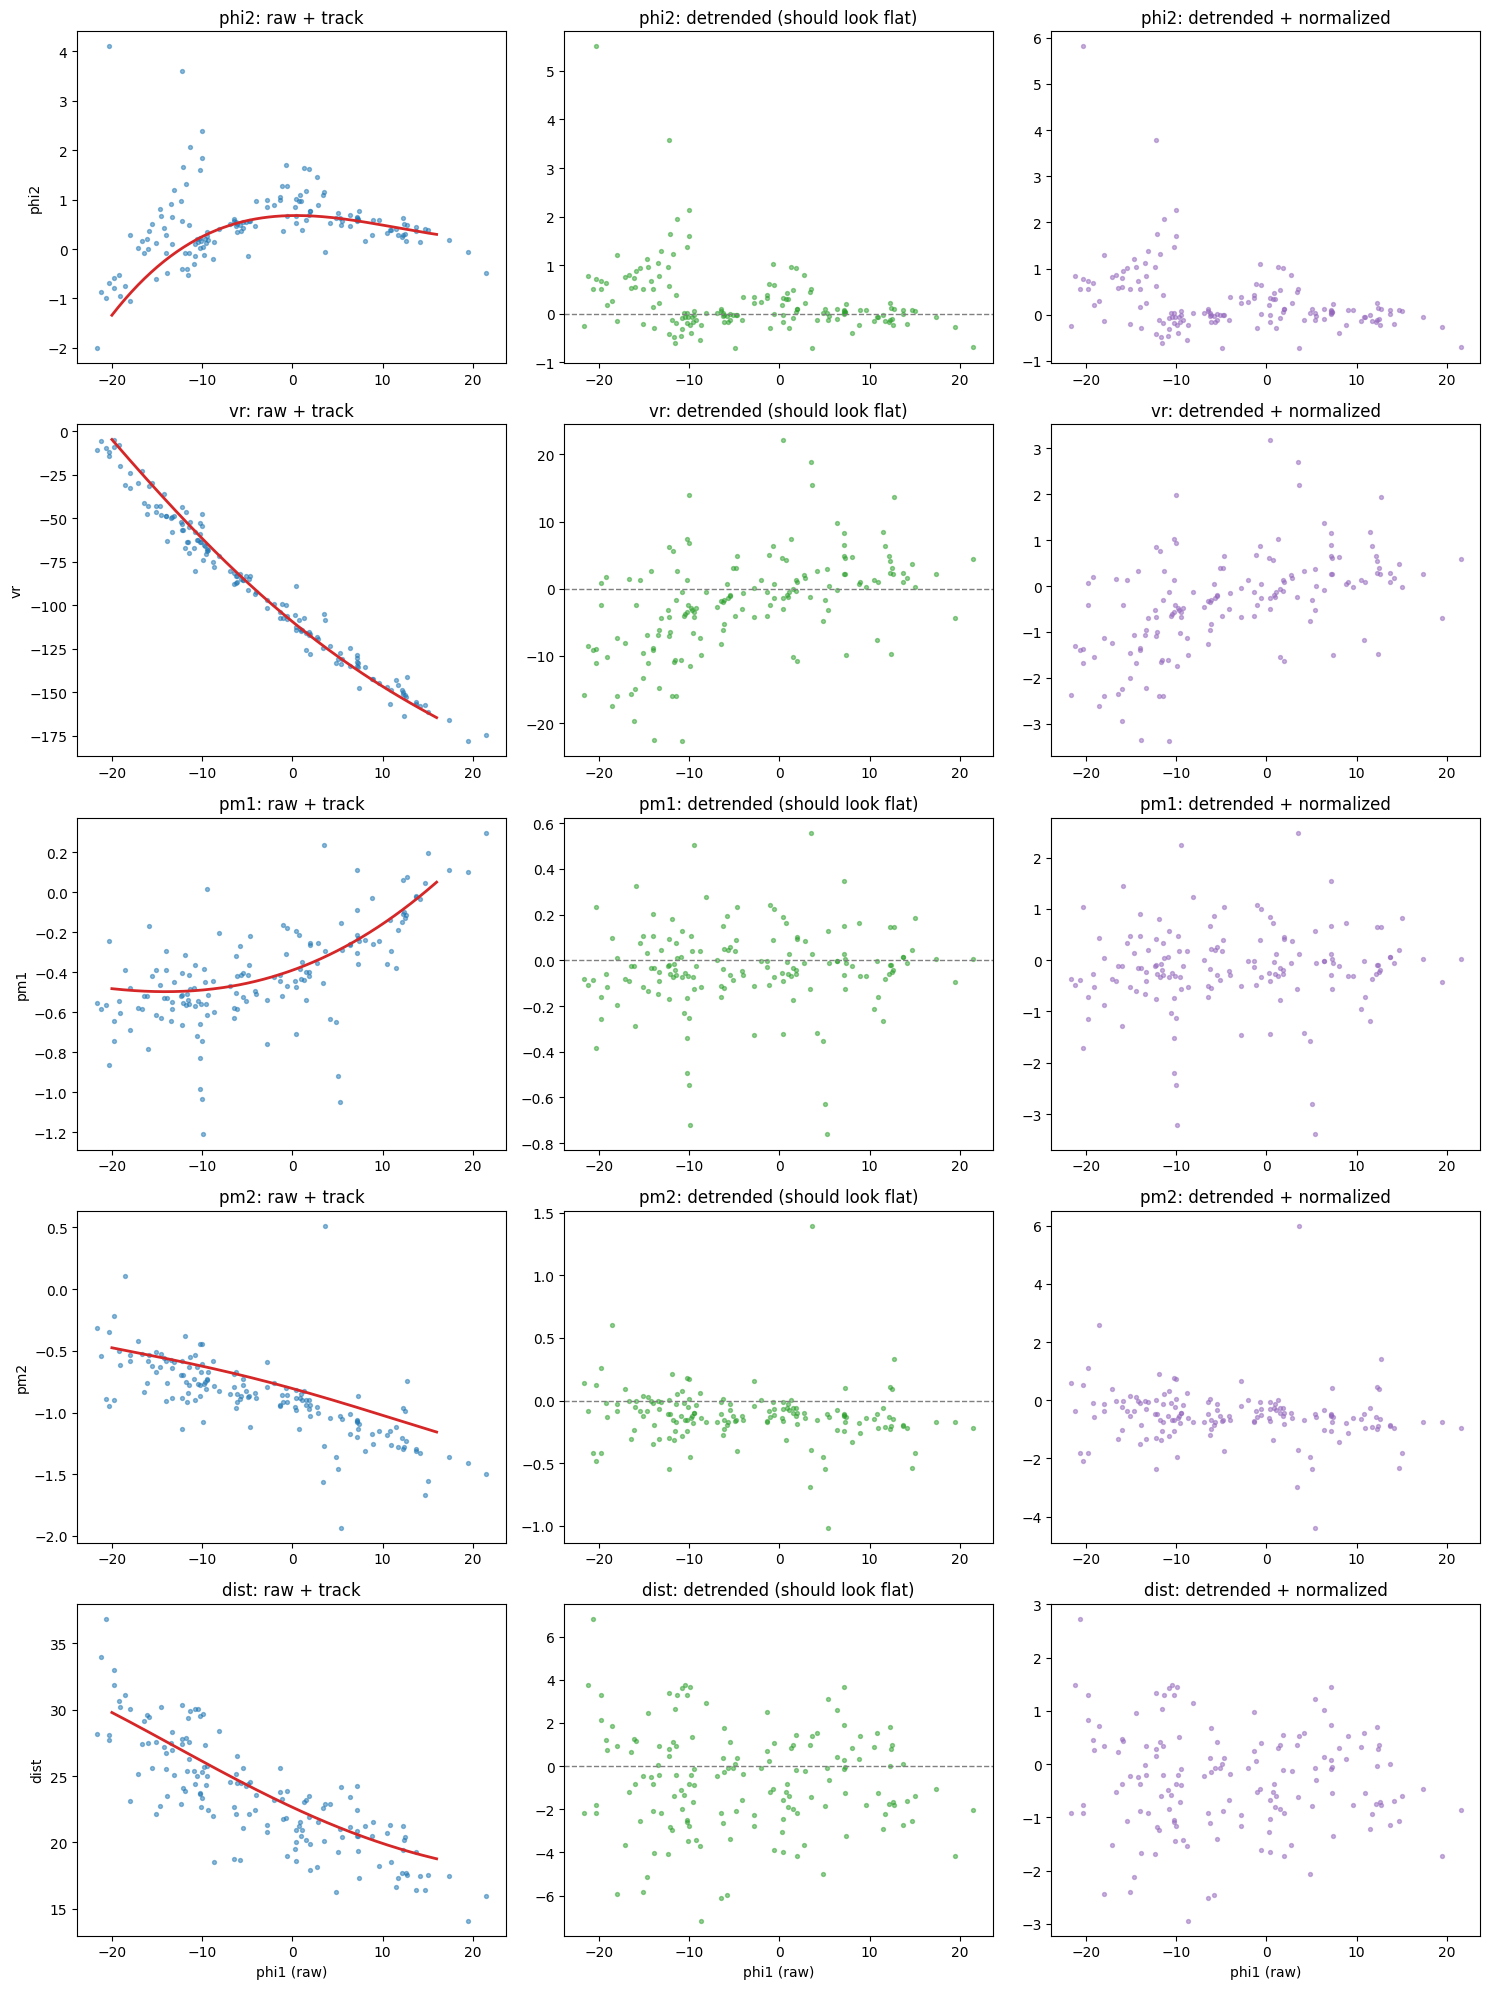

feature     raw std   detrended std   normalized mean   normalized std
phi2         0.7343          0.7178            0.2907           0.7554
vr          43.2701          7.3953           -0.3616           1.0815
pm1          0.2516          0.1843           -0.1640           0.8212
pm2          0.3170          0.2213           -0.5243           0.9528
dist         4.1912          2.3510           -0.3097           0.9526


In [18]:
import copy
import matplotlib.pyplot as plt

feature_names = ['phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist']
phi1_idx = feature_names.index("phi1")

# work on a fresh copy so we don't clobber the graph you'll actually run inference on
graph_raw = copy.deepcopy(data[i])
graph_detrended = copy.deepcopy(graph_raw)

# apply detrending only (no normalization yet), so we can compare raw vs detrended
graph_detrended = particle_dataset._subtract_track_from_data(
    [graph_detrended], feature_names, track_feature=None, track_path=track_paths
)[0]

# apply normalization on top of the detrended version (this matches your actual pipeline)
graph_normalized = copy.deepcopy(graph_detrended)
graph_normalized.x = (graph_normalized.x - x_loc) / x_scale

phi1_vals = graph_raw.x[:, phi1_idx].numpy()

features_to_plot = ['phi2', 'vr', 'pm1', 'pm2', 'dist']

fig, axes = plt.subplots(len(features_to_plot), 3, figsize=(15, 4 * len(features_to_plot)))

for row, feat in enumerate(features_to_plot):
    feat_idx = feature_names.index(feat)

    raw_vals = graph_raw.x[:, feat_idx].numpy()
    detrended_vals = graph_detrended.x[:, feat_idx].numpy()
    normalized_vals = graph_normalized.x[:, feat_idx].numpy()

    # overlay the fitted track on the raw panel
    track, info = particle_dataset._load_track_poly(track_paths[feat])
    phi1_fine = np.linspace(info["phi1_min"], info["phi1_max"], 200)
    track_curve = track(phi1_fine)

    axes[row, 0].scatter(phi1_vals, raw_vals, s=8, alpha=0.5)
    axes[row, 0].plot(phi1_fine, track_curve, color="tab:red", lw=2)
    axes[row, 0].set_title(f"{feat}: raw + track")
    axes[row, 0].set_ylabel(feat)

    axes[row, 1].scatter(phi1_vals, detrended_vals, s=8, alpha=0.5, color="tab:green")
    axes[row, 1].axhline(0, color="gray", lw=1, ls="--")
    axes[row, 1].set_title(f"{feat}: detrended (should look flat)")

    axes[row, 2].scatter(phi1_vals, normalized_vals, s=8, alpha=0.5, color="tab:purple")
    axes[row, 2].set_title(f"{feat}: detrended + normalized")

for ax in axes[-1, :]:
    ax.set_xlabel("phi1 (raw)")

plt.tight_layout()
plt.show()

# quick numeric summary
print(f"{'feature':<8} {'raw std':>10} {'detrended std':>15} {'normalized mean':>17} {'normalized std':>16}")
for feat in features_to_plot:
    feat_idx = feature_names.index(feat)
    raw_std = graph_raw.x[:, feat_idx].std().item()
    detrended_std = graph_detrended.x[:, feat_idx].std().item()
    norm_mean = graph_normalized.x[:, feat_idx].mean().item()
    norm_std = graph_normalized.x[:, feat_idx].std().item()
    print(f"{feat:<8} {raw_std:>10.4f} {detrended_std:>15.4f} {norm_mean:>17.4f} {norm_std:>16.4f}")

In [19]:
# Inference
all_posteriors = model.sample_from_loader(graph_loader, num_samples=100000)

# convert posterior back to physical units
y_loc = torch.tensor(norm_dict.y_loc, dtype=torch.float32)
y_scale = torch.tensor(norm_dict.y_scale, dtype=torch.float32)
all_posteriors = all_posteriors * y_scale + y_loc

all_posteriors = all_posteriors.cpu().numpy()  # move to CPU and convert to numpy array

100%|██████████| 1/1 [00:01<00:00,  1.78s/it]


In [20]:
# posterior = all_posteriors[0]
# fig = corner.corner(
#     posterior,
#     truths=true_params_dict.values(),
#     labels=labels,
#     show_titles=True,
#     title_fmt=".2f",
# )

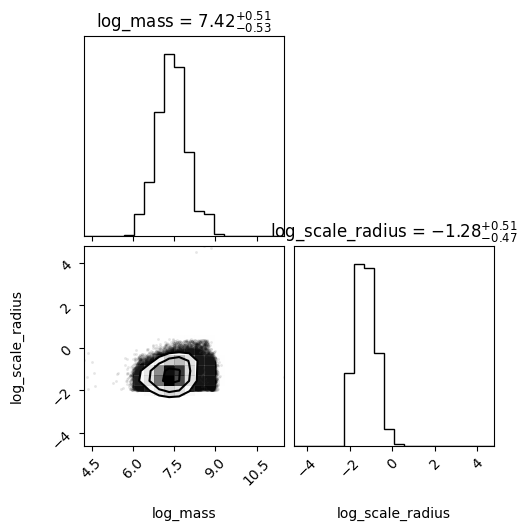

In [21]:
plt.close('all')

idx = [labels.index('log_mass'), labels.index('log_scale_radius')]

posterior_sub = all_posteriors[0][:, idx]
labels_sub = ['log_mass', 'log_scale_radius']

fig = corner.corner(
    posterior_sub,
    labels=labels_sub,
    show_titles=True,
    title_fmt=".2f",
)
plt.show()

In [22]:
def plot_pretty(dpi=175, fontsize=15, labelsize=15, figsize=(10, 8), tex=True):
    # import pyplot and set some parameters to make plots prettier

    plt.rc('savefig', dpi=dpi)
    plt.rc('text', usetex=tex)
    plt.rc('font', size=fontsize)
    plt.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
    plt.rc('xtick.major', pad=5)
    plt.rc('xtick.minor', pad=5)
    plt.rc('ytick.major', pad=5)
    plt.rc('ytick.minor', pad=5)
    plt.rc('figure', figsize=figsize)

    mpl.rcParams['xtick.labelsize'] = labelsize
    mpl.rcParams['ytick.labelsize'] = labelsize
    mpl.rcParams.update({'figure.autolayout': True})

from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

def colorbar(mappable):
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    return fig.colorbar(mappable, cax=cax)

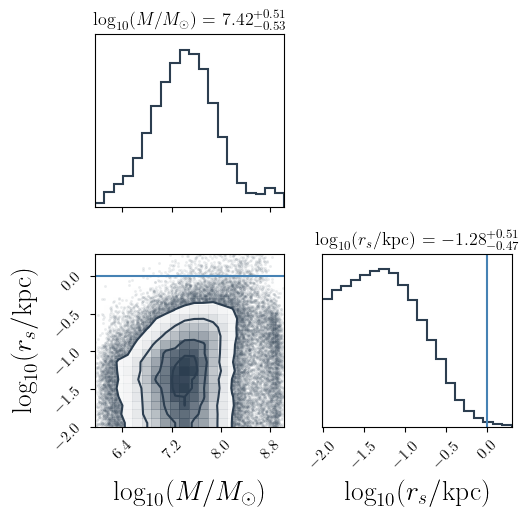

In [23]:
plot_pretty(dpi=175, fontsize=15, labelsize=13, figsize=(8, 8), tex=True)

plt.close('all')  # clear any stale figure state

# indices for the params you care about
idx = [labels.index('log_mass'), labels.index('log_scale_radius')]
posterior_sub = all_posteriors[0][:, idx]          # (num_samples, 2)
truths_sub = [true_params_dict['log_mass'], true_params_dict['log_scale_radius']]
#labels_sub = ['log_mass', 'log_scale_radius']
labels_sub = [
    r'$\log_{10}(M/M_\odot)$',
    r'$\log_{10}(r_s/\mathrm{kpc})$'
]

fig = corner.corner(
    posterior_sub,
    truths=truths_sub,
    labels=labels_sub,
    show_titles=True,
    title_fmt=".2f",
    truth_color="#4682b4",
    color="#2c3e50",
    hist_kwargs={"color": "#2c3e50", "linewidth": 1.5},
    label_kwargs={"fontsize": 20},
    title_kwargs={"fontsize": 13},
    range = [0.999, 0.999],
)

# diagonal axes for a 2-param corner plot are at positions 0 and 3
# n_params = len(labels_sub)
# diag_axes = [fig.axes[i * n_params + i] for i in range(n_params)]
# truth_color = "#4682b4"
# for ax, true_val, label in zip(diag_axes, truths_sub, labels_sub):
#     ax.text(
#         0.5, 1.15,
#         f"True: {true_val:.2f}",
#         color=truth_color,
#         ha='center', va='bottom',
#         transform=ax.transAxes,
#         fontsize=15,
#     )

# tidy up tick label sizes on all axes (corner sets its own by default)
for ax in fig.axes:
    ax.tick_params(labelsize=11)

#fig.suptitle("AAU Subhalo Posterior: log_mass vs log_scale_radius", y=1.05, fontsize=15)

#plt.savefig("corner_log_mass_log_scale_radius.pdf", bbox_inches="tight")
plt.show()

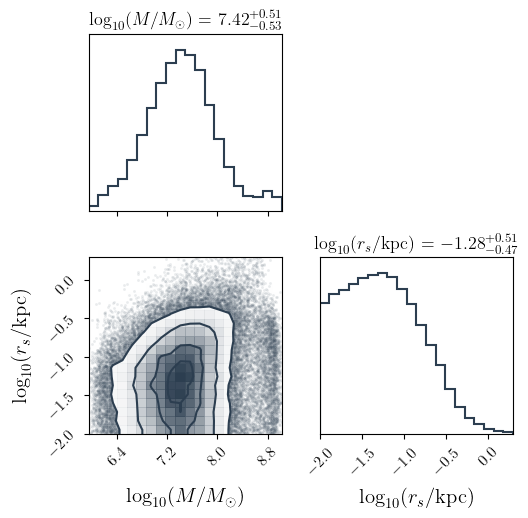

In [24]:
plot_pretty(dpi=175, fontsize=15, labelsize=13, figsize=(8, 8), tex=True)

plt.close('all')

idx = [labels.index('log_mass'), labels.index('log_scale_radius')]
posterior_sub = all_posteriors[0][:, idx]
labels_sub = [
    r'$\log_{10}(M/M_\odot)$',
    r'$\log_{10}(r_s/\mathrm{kpc})$'
]

fig = corner.corner(
    posterior_sub,
    labels=labels_sub,
    show_titles=True,
    title_fmt=".2f",
    color="#2c3e50",
    hist_kwargs={"color": "#2c3e50", "linewidth": 1.5},
    label_kwargs={"fontsize": 15},
    title_kwargs={"fontsize": 13},
    range=[0.999, 0.999],
)

for ax in fig.axes:
    ax.tick_params(labelsize=11)

plt.show()

In [25]:
color_aau = '#AA3377'

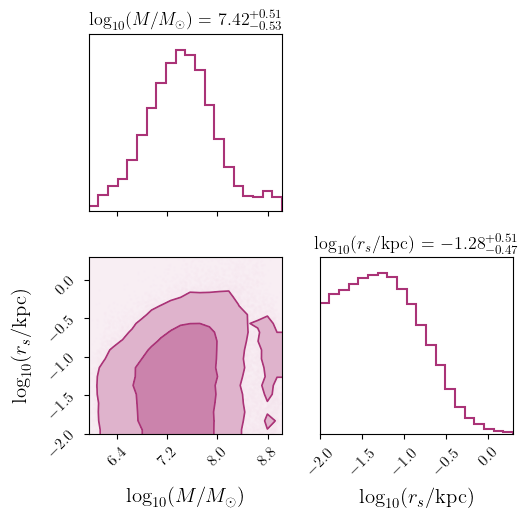

In [26]:
import matplotlib.colors as mcolors

plot_pretty(dpi=175, fontsize=15, labelsize=13, figsize=(8, 8), tex=True)
plt.close('all')

idx = [labels.index('log_mass'), labels.index('log_scale_radius')]
posterior_sub = all_posteriors[0][:, idx]
#truths_sub = [true_params_dict['log_mass'], true_params_dict['log_scale_radius']]
labels_sub = [
    r'$\log_{10}(M/M_\odot)$',
    r'$\log_{10}(r_s/\mathrm{kpc})$'
]
''
steel = mcolors.to_rgb(color_aau)
cmap_sb = mcolors.LinearSegmentedColormap.from_list(
    'white_to_steelblue',
    [(0,   (1, 1, 1)),
     (0.4, (*steel, 0.35)),
     (1.0, (*steel, 0.85)),
    ]
)

fig = corner.corner(
    posterior_sub,
    #truths=truths_sub,
    labels=labels_sub,
    show_titles=True,
    title_fmt=".2f",
    #truth_color='black',
    color=color_aau,
    fill_contours=True,
    levels=[0.68, 0.95],
    hist_kwargs={"color": color_aau, "linewidth": 1.5},
    contour_kwargs={"colors": [color_aau], "linewidths": 1.2},
    contourf_kwargs={"cmap": cmap_sb, "colors": None},
    label_kwargs={"fontsize": 15},
    title_kwargs={"fontsize": 13},
    range=[0.999, 0.999],
)

# n_params = len(labels_sub)
# diag_axes = [fig.axes[i * n_params + i] for i in range(n_params)]
# for ax, true_val in zip(diag_axes, truths_sub):
#     ax.text(
#         0.5, 1.15, f"True: {true_val:.2f}",
#         color='black',
#         ha='center', va='bottom',
#         transform=ax.transAxes,
#         fontsize=15,
#     )

for ax in fig.axes:
    ax.tick_params(labelsize=11)

plt.show()

In [27]:
# plt.close('all')

# fig = corner.corner(
#     posterior_sub,
#     truths=truths_sub,
#     labels=labels_sub,
#     show_titles=True,
#     title_fmt=".2f",
#     fig=plt.figure(figsize=(22, 22)),
#     #range = [0.9999, 0.9999, 0.9999, 0.9999, 0.9999, 0.9999, 0.9999, 0.9999, 0.9999],
# )

# n_params = len(labels_sub)
# diag_axes = [fig.axes[i * n_params + i] for i in range(n_params)]

# truth_color = "#4682b4"
# for ax, true_val, label in zip(diag_axes, truths_sub, labels_sub):
#     ax.text(
#         0.5, 1.15,
#         f"true: {true_val:.2f}",
#         color=truth_color,
#         ha='center', va='bottom',
#         transform=ax.transAxes,
#         fontsize=13,
#     )

# plt.tight_layout()
# plt.show()

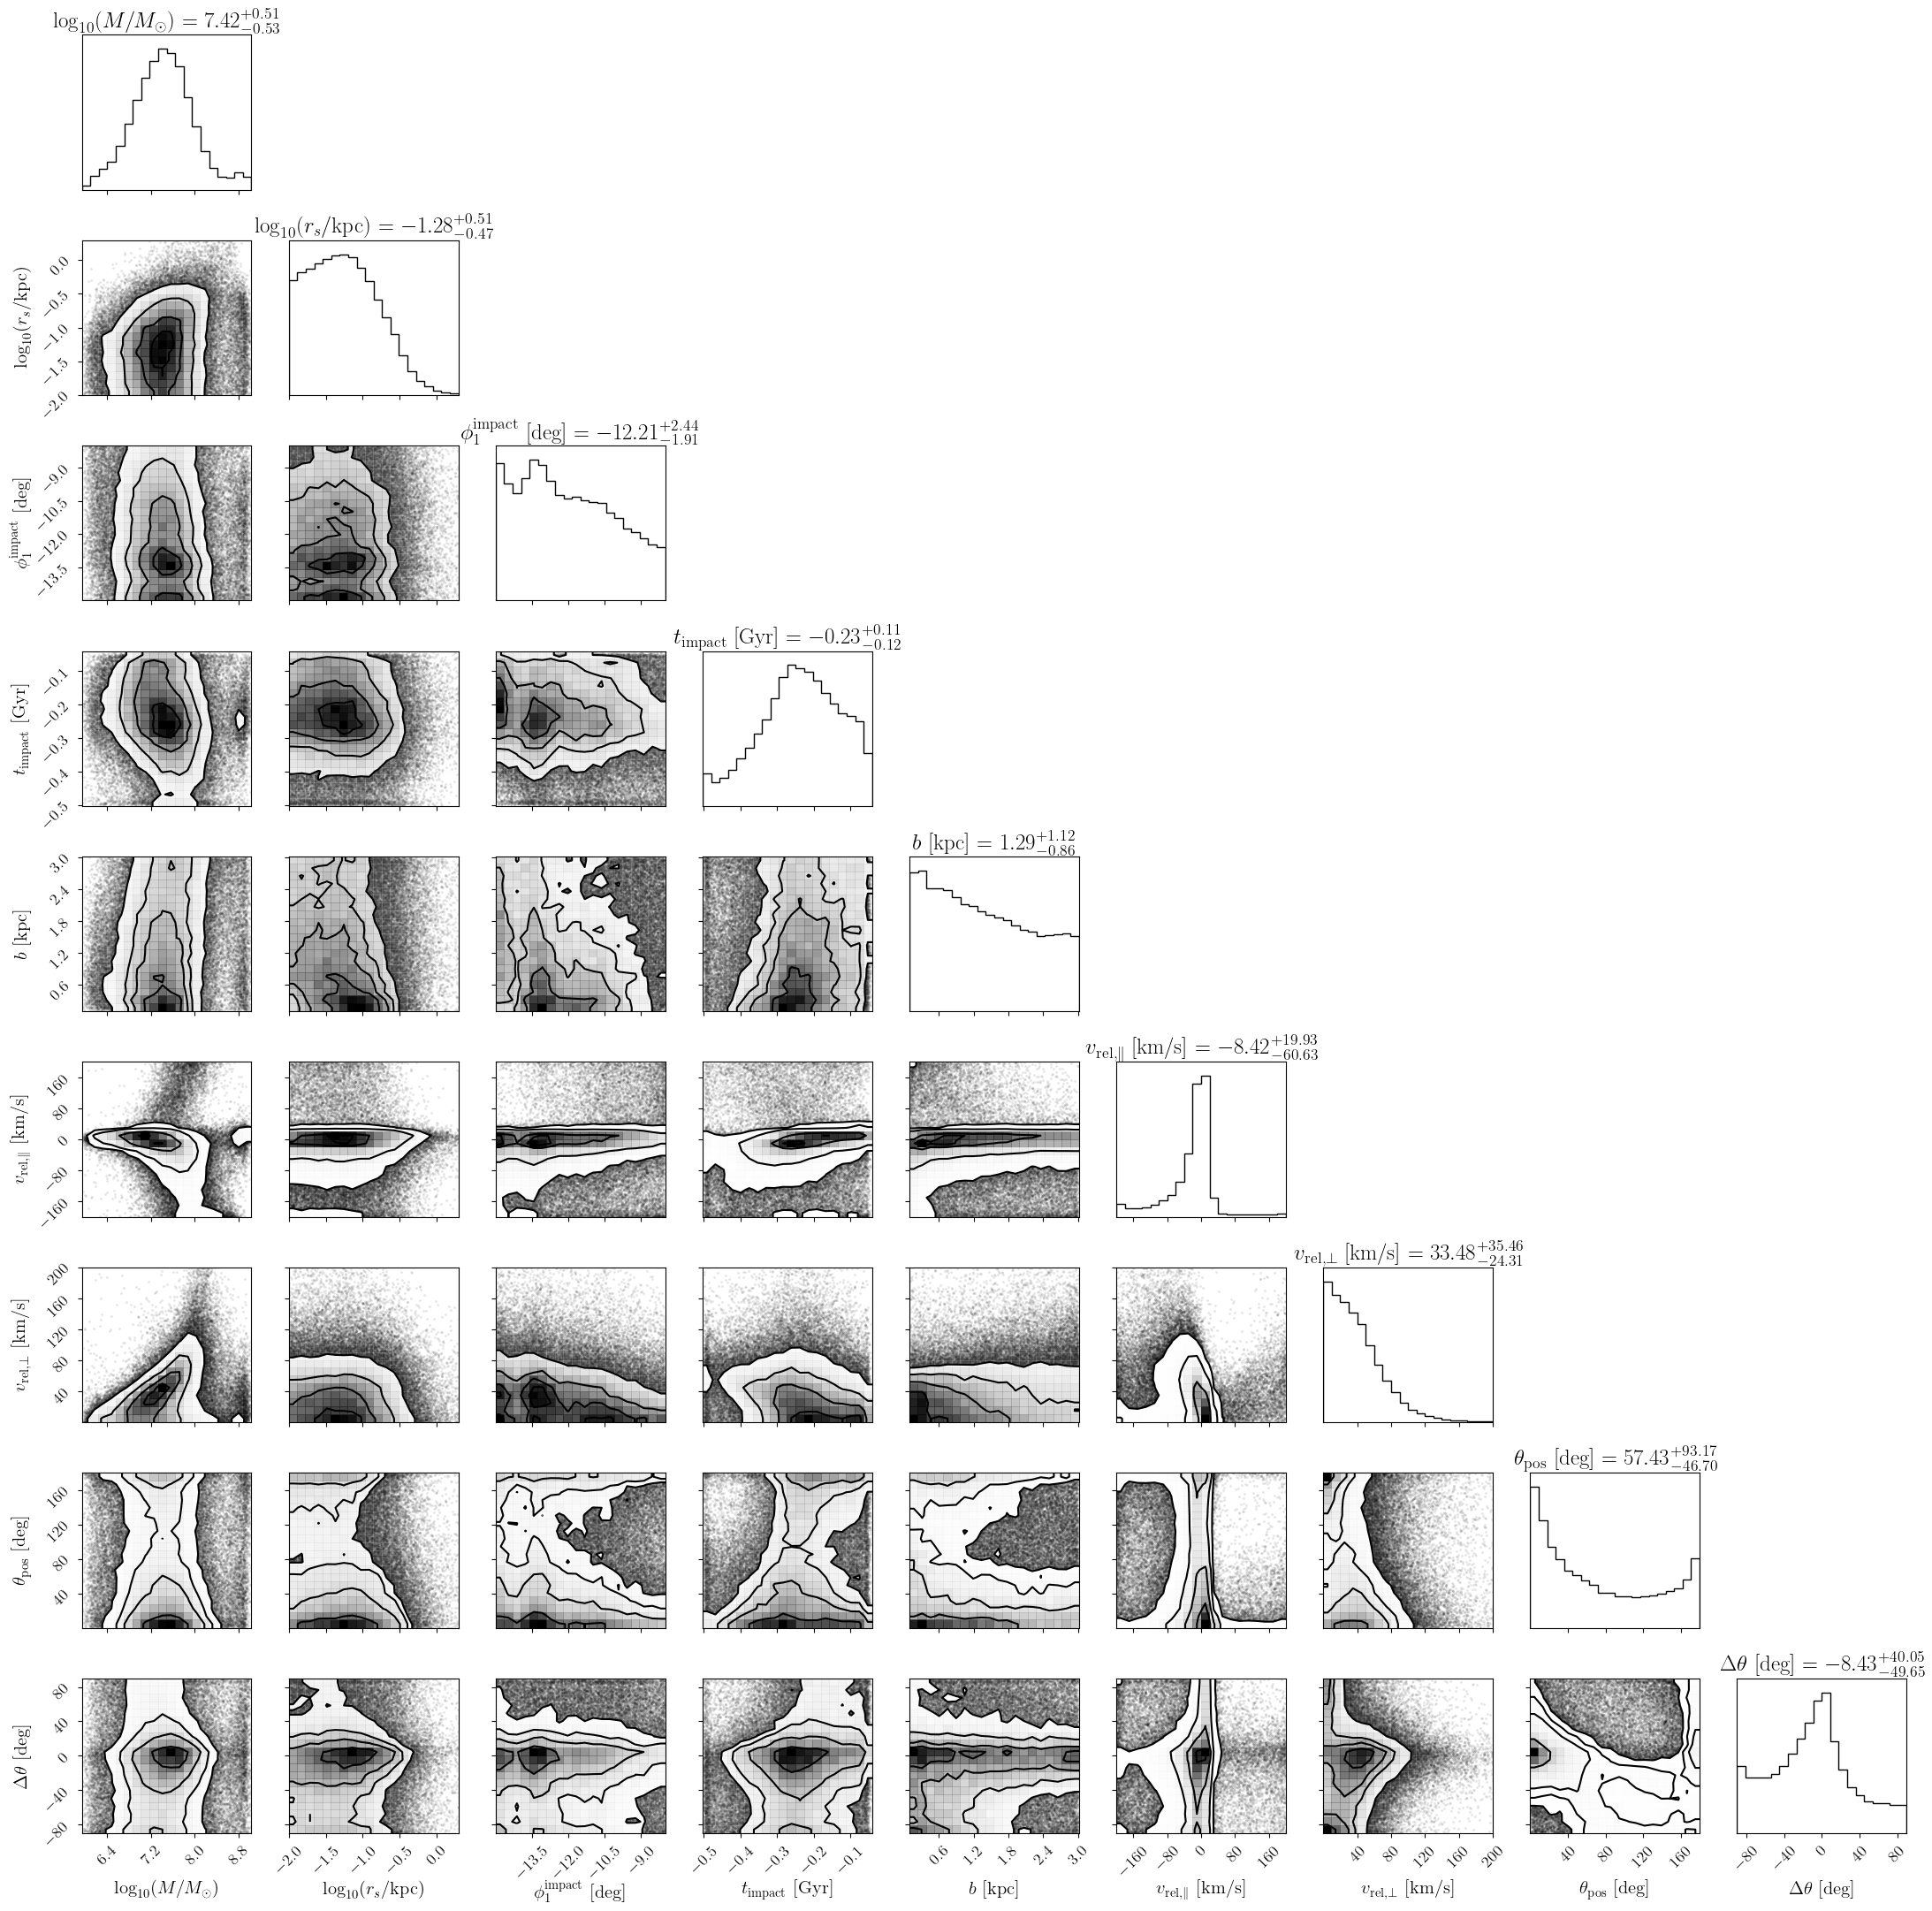

In [28]:
plt.close('all')

labels_sub = [
    'log_mass', 'log_scale_radius', 'phi1_impact_today', 'time_impact',
    'impact_parameter', 'v_rel_para', 'v_rel_perp',
    'angle_pos_at_impact', 'delta_angle',
]

idx = [labels.index(l) for l in labels_sub]
posterior_sub = all_posteriors[0][:, idx]          # (num_samples, 9)

label_info = {
    'log_mass':             (r'$\log_{10}(M/M_\odot)$', None),
    'log_scale_radius':     (r'$\log_{10}(r_s / \mathrm{kpc})$', None),
    'phi1_impact_today':    (r'$\phi_1^{\rm impact}$ [deg]', (-15, -8)),
    'time_impact':          (r'$t_{\rm impact}$ [Gyr]', None),
    'impact_parameter':     (r'$b$ [kpc]', None),
    'v_rel_para':           (r'$v_{\rm rel,\parallel}$ [km/s]', (-200, 200)),
    'v_rel_perp':           (r'$v_{\rm rel,\perp}$ [km/s]', (0, 200)),
    'angle_pos_at_impact':  (r'$\theta_{\rm pos}$ [deg]', (0, 180)),
    'delta_angle':          (r'$\Delta\theta$ [deg]', (-90, 90)),
}

labels_display = [label_info[l][0] for l in labels_sub]
plot_range     = [label_info[l][1] if label_info[l][1] is not None else 0.999 for l in labels_sub]

fig = corner.corner(
    posterior_sub,
    labels=labels_display,
    show_titles=True,
    title_fmt=".2f",
    fig=plt.figure(figsize=(22, 22)),
    range=plot_range,
)

plt.tight_layout()
plt.show()

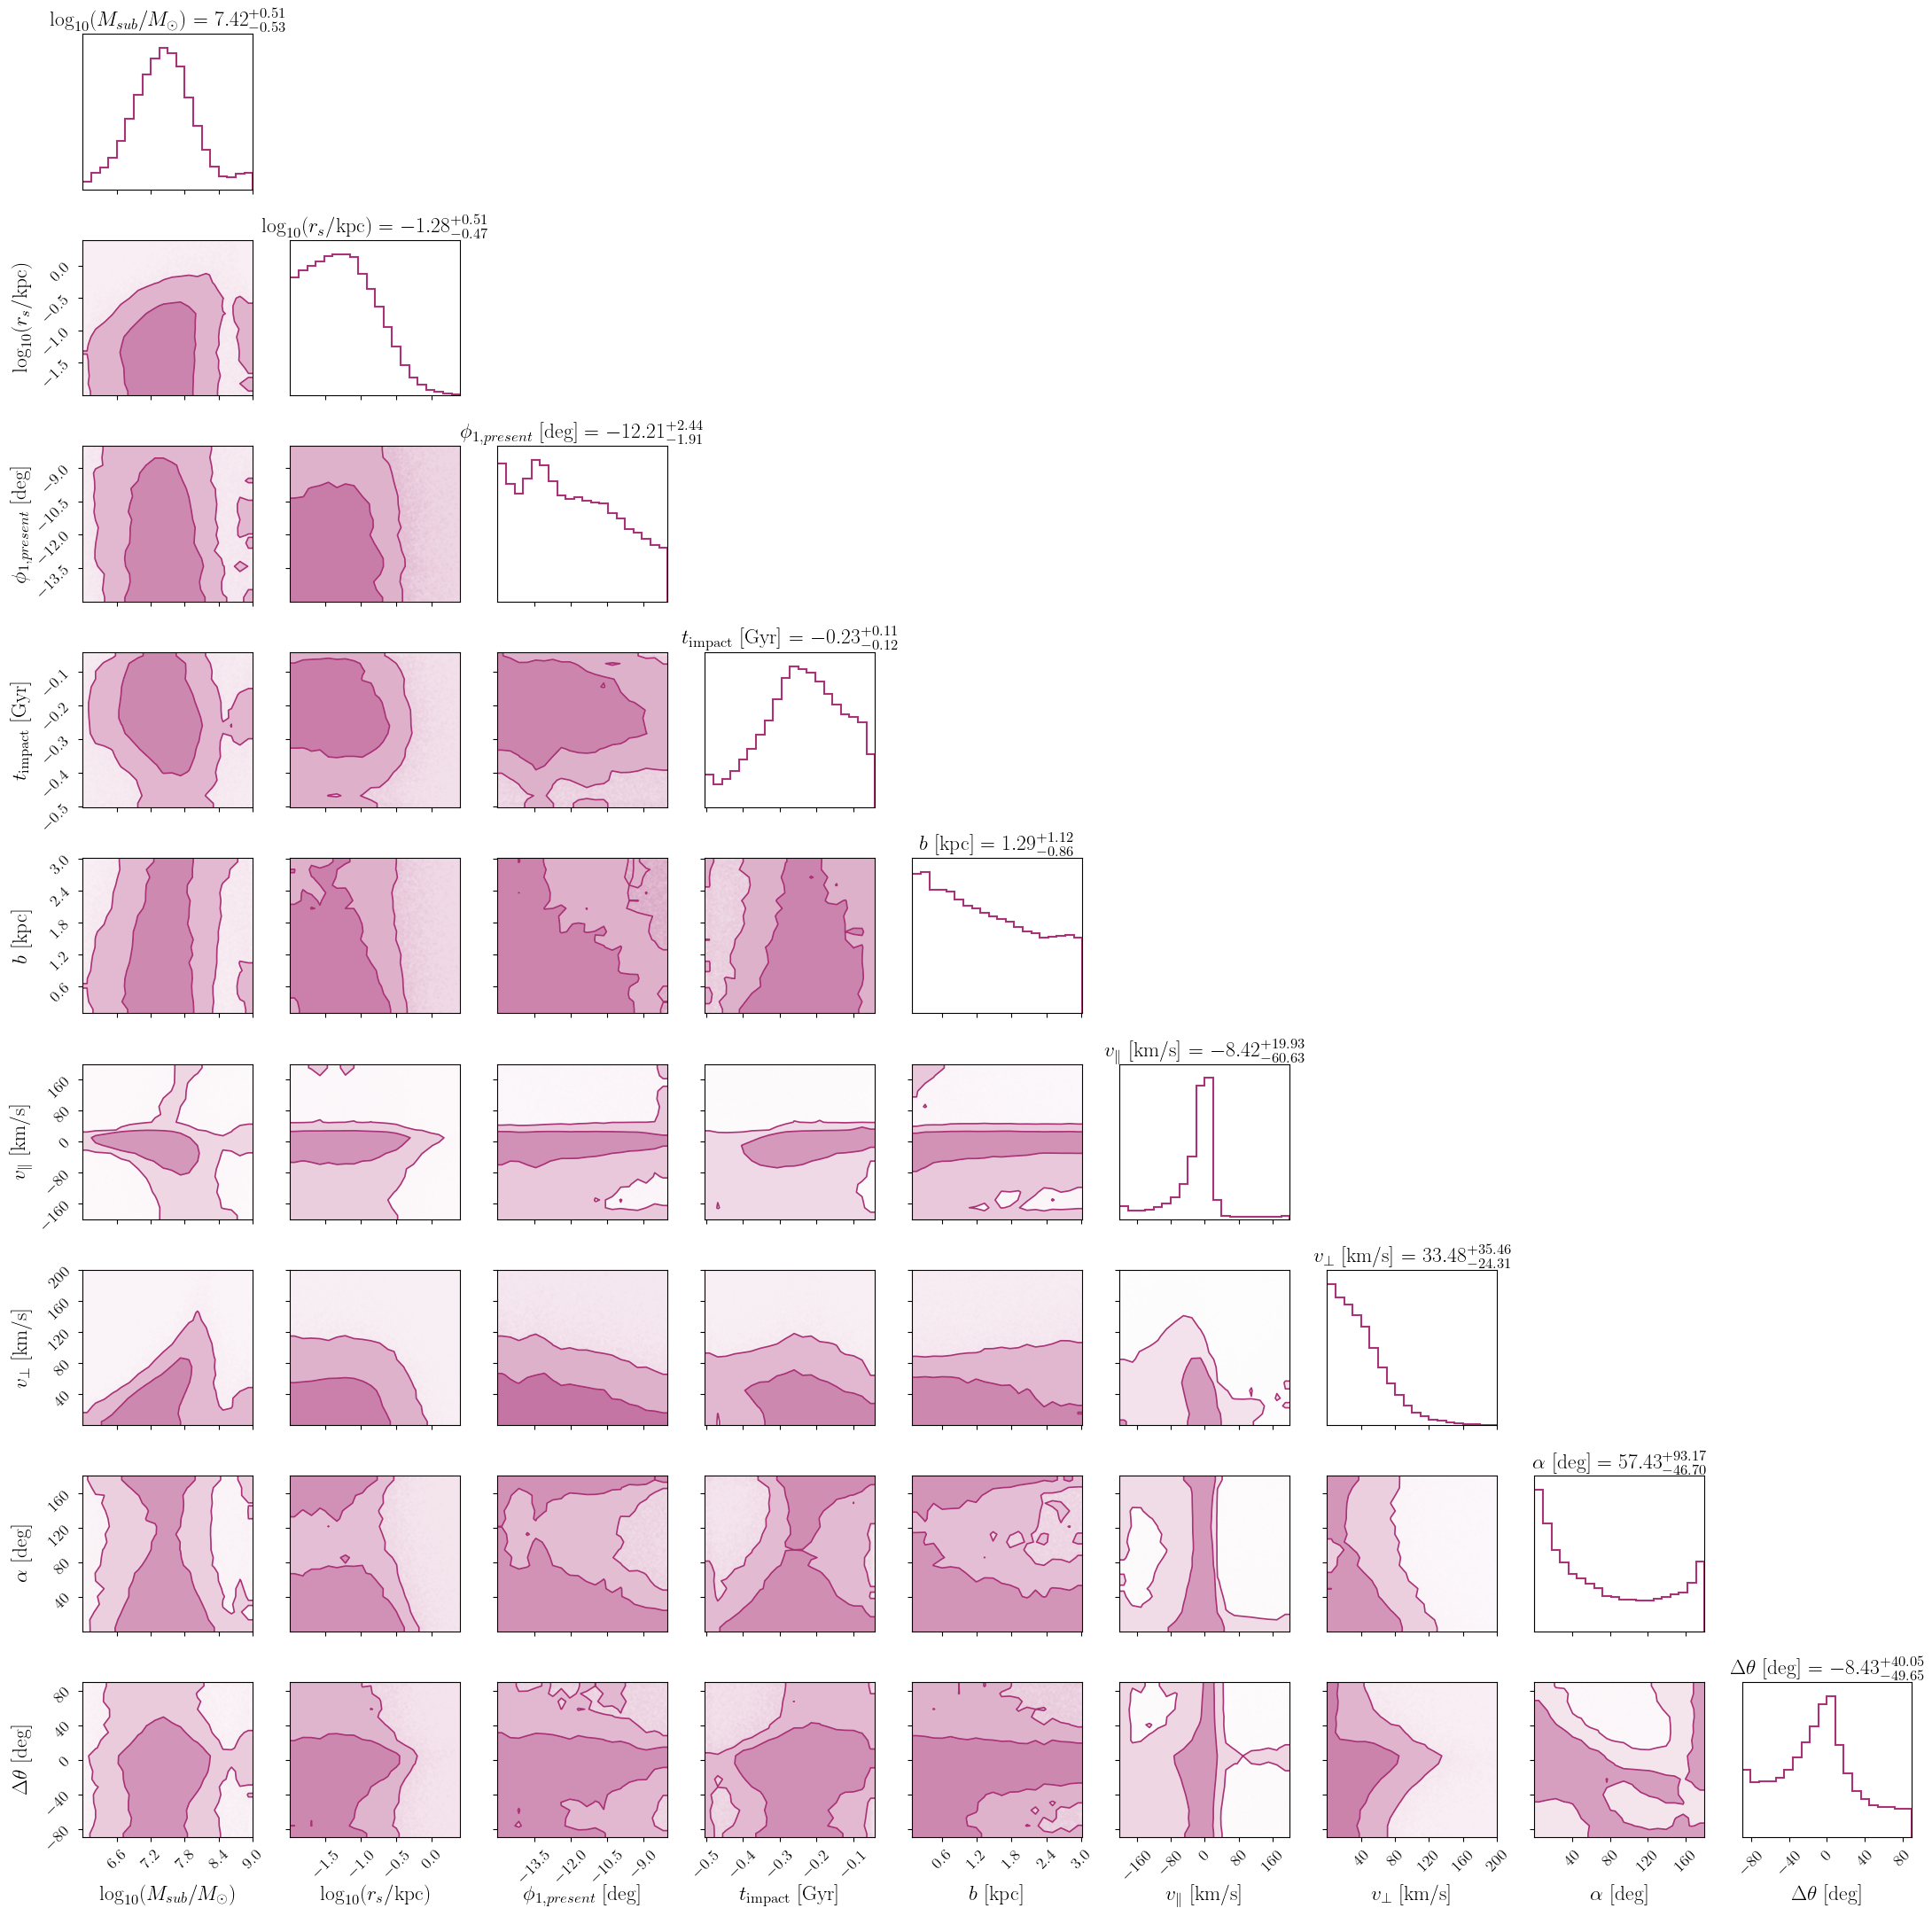

In [29]:
import matplotlib.colors as mcolors

plt.close('all')

labels_sub = [
    'log_mass', 'log_scale_radius', 'phi1_impact_today', 'time_impact',
    'impact_parameter', 'v_rel_para', 'v_rel_perp',
    'angle_pos_at_impact', 'delta_angle',
]

idx = [labels.index(l) for l in labels_sub]
posterior_sub = all_posteriors[0][:, idx]

label_info = {
    'log_mass':             (r'$\log_{10}(M_{sub}/M_\odot)$',            (6, 9)),
    'log_scale_radius':     (r'$\log_{10}(r_s / \mathrm{kpc})$',   (-2.0, 0.4)),
    'phi1_impact_today':    (r'$\phi_{1, present}$ [deg]',        (-15, -8)),
    'time_impact':          (r'$t_{\rm impact}$ [Gyr]',             None),
    'impact_parameter':     (r'$b$ [kpc]',                          None),
    'v_rel_para':           (r'$v_{\parallel}$ [km/s]',     (-200, 200)),
    'v_rel_perp':           (r'$v_{\perp}$ [km/s]',         (0, 200)),
    'angle_pos_at_impact':  (r'$\alpha$ [deg]',           (0, 180)),
    'delta_angle':          (r'$\Delta\theta$ [deg]',               (-90, 90)),
}

labels_display = [label_info[l][0] for l in labels_sub]
plot_range     = [label_info[l][1] if label_info[l][1] is not None else 0.999 for l in labels_sub]

steel = mcolors.to_rgb(color_aau)
cmap_sb = mcolors.LinearSegmentedColormap.from_list(
    'white_to_color_aau',
    [(0,   (1, 1, 1)),
     (0.4, (*steel, 0.35)),
     (1.0, (*steel, 0.85)),
    ]
)

fig_corner = corner.corner(
    posterior_sub,
    labels=labels_display,
    show_titles=True,
    title_fmt=".2f",
    fig=plt.figure(figsize=(22, 22)),
    color=color_aau,
    fill_contours=True,
    levels=[0.68, 0.95],
    hist_kwargs={"color": color_aau, "linewidth": 1.5},
    contour_kwargs={"colors": [color_aau], "linewidths": 1.2},
    contourf_kwargs={"cmap": cmap_sb, "colors": None},
    label_kwargs={"fontsize": 17},
    title_kwargs={"fontsize": 17},
    range=plot_range,
)

for ax in fig.axes:
    ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

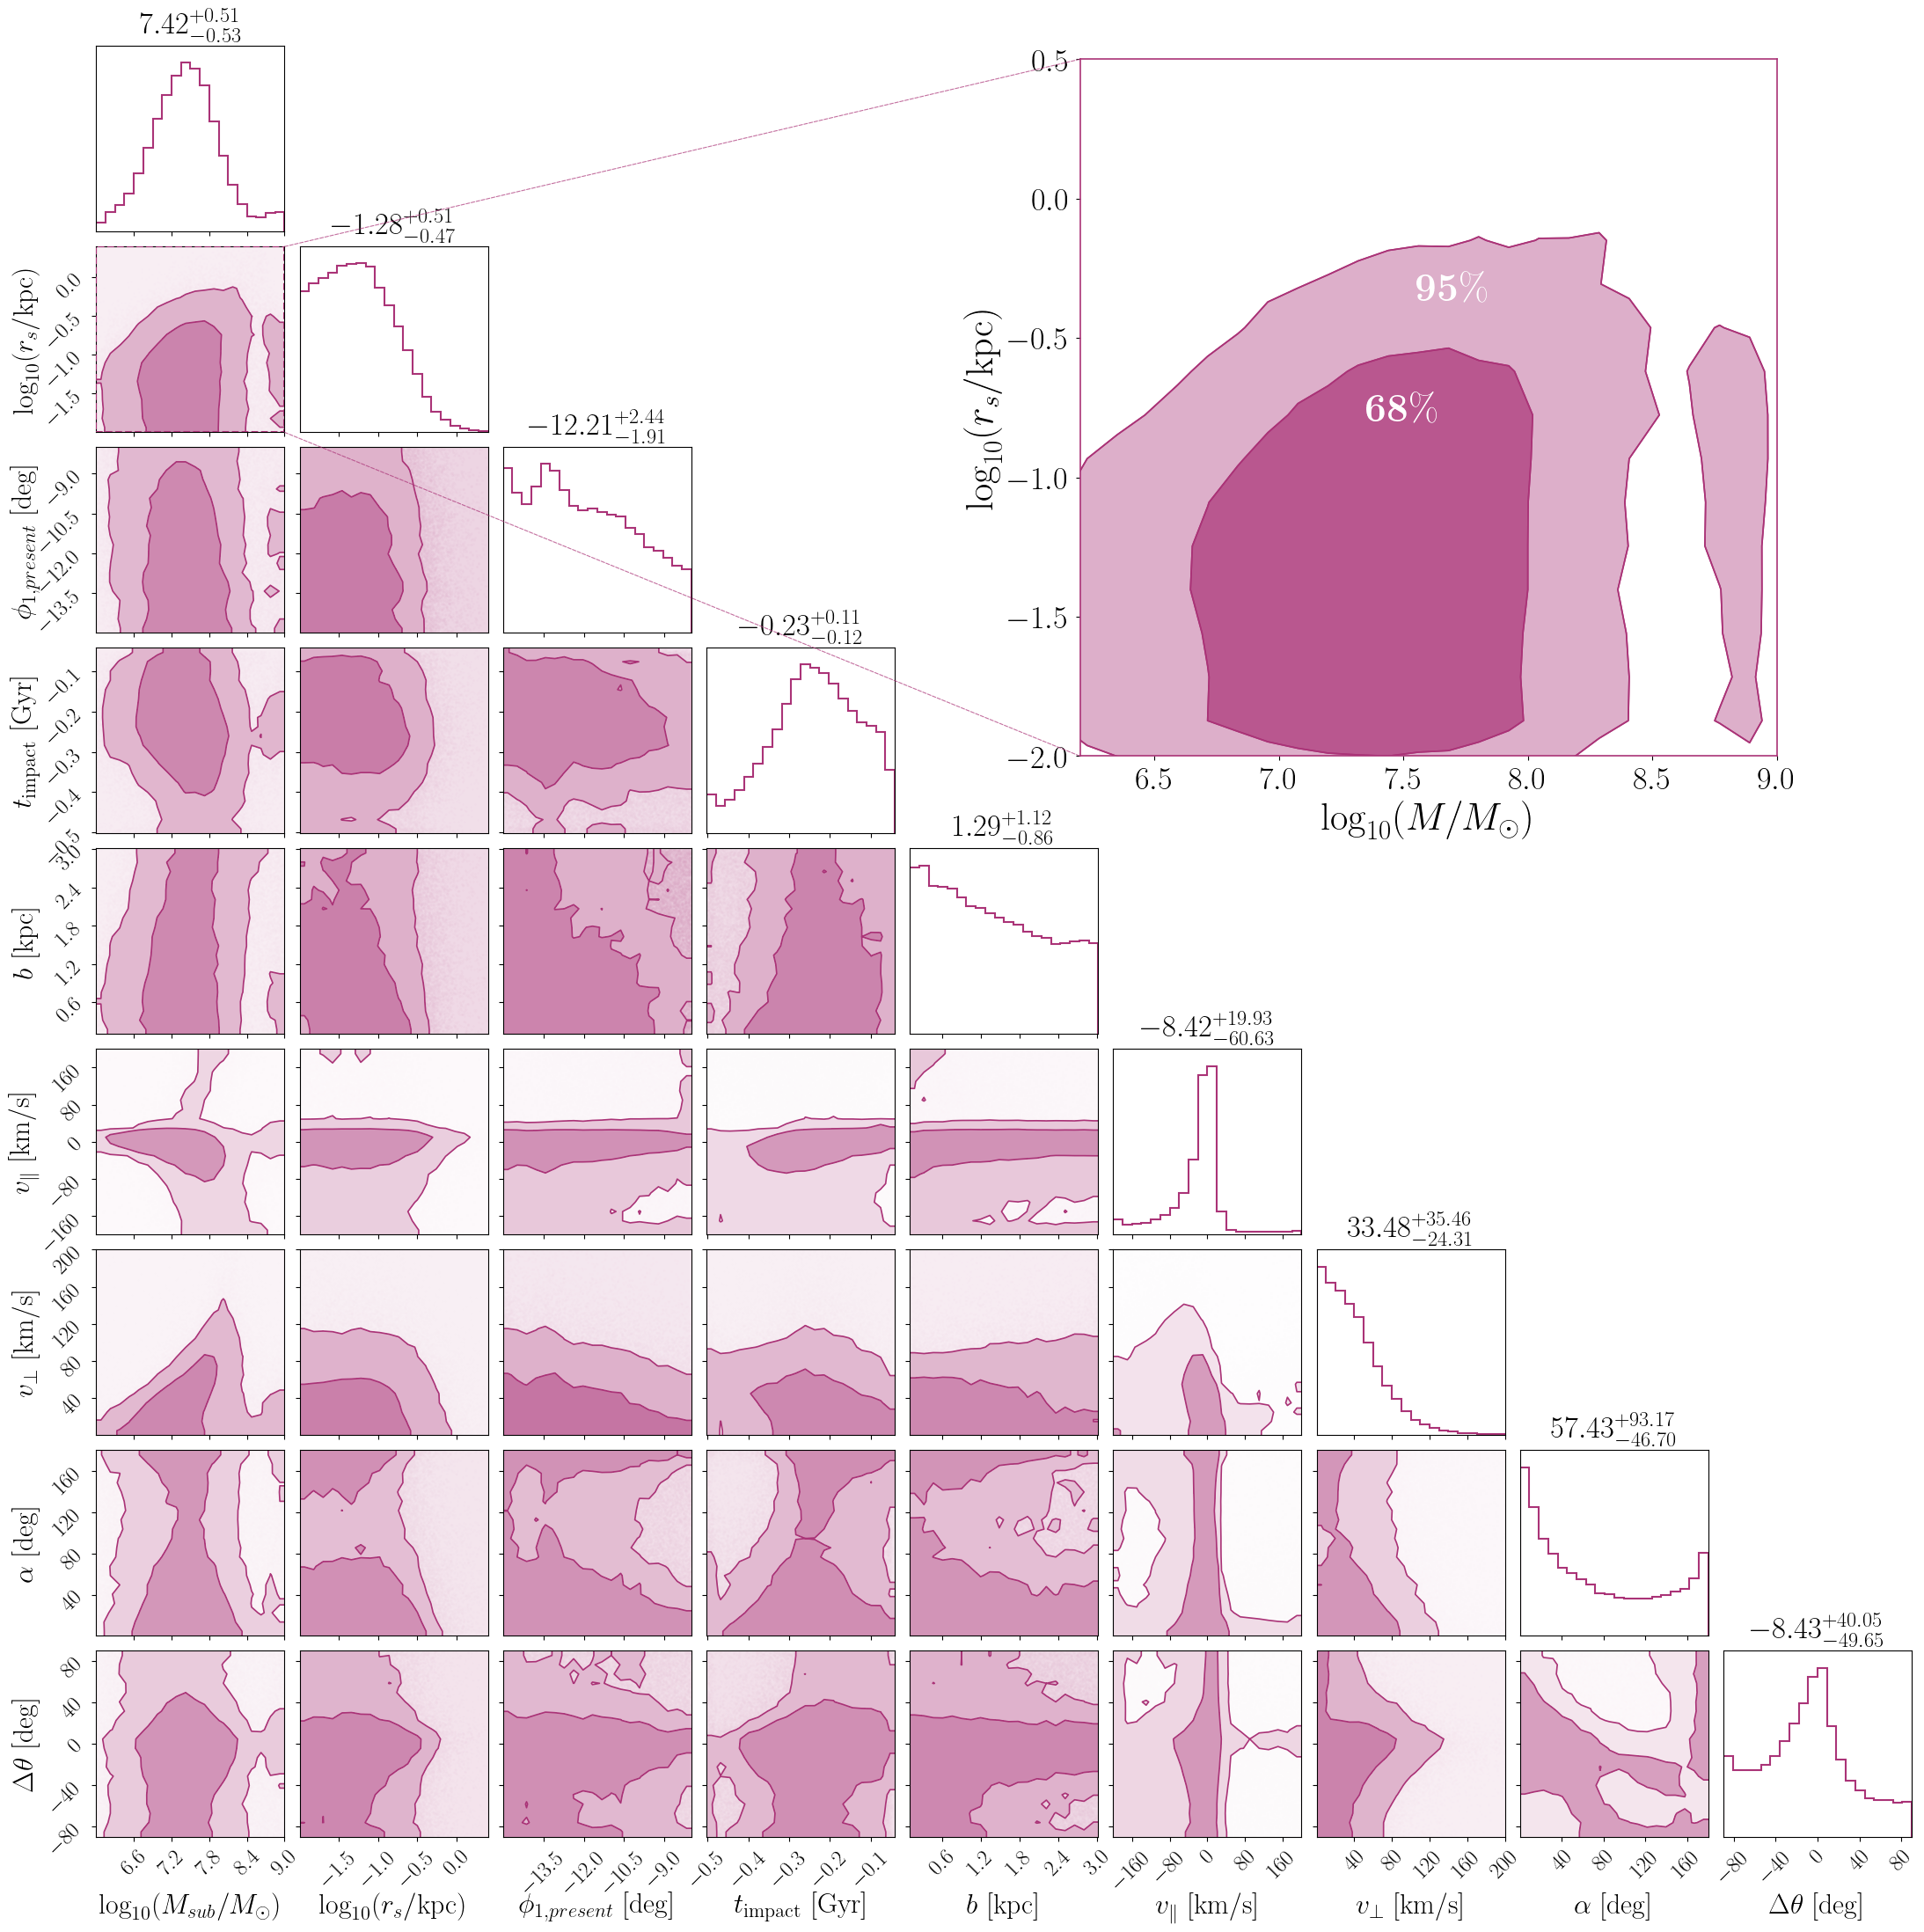

In [30]:
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import copy

plt.rcParams.update({'font.size': 28})   # scales everything that doesn't have an explicit override

fig = copy.deepcopy(fig_corner)

ndim = len(labels_sub)
axes2d = np.array(fig.axes).reshape(ndim, ndim)
ax_mr  = axes2d[1, 0]   # log_scale_radius (y) vs log_mass (x)

# Update all existing text in the copied corner figure
for ax in fig.axes:
    ax.tick_params(labelsize=18)
    ax.xaxis.label.set_fontsize(23)
    ax.yaxis.label.set_fontsize(23)
    ax.xaxis.labelpad = 14
    ax.yaxis.labelpad = 14
    for txt in ax.texts:
        txt.set_fontsize(25)
        t = txt.get_text()
        # corner title: "some label = $value$" or "some label = value"
        # strip everything up to and including the last "="
        if '=' in t:
            txt.set_text(t.split('=', 1)[1].strip())

# Instead of trying to parse the title string, just clear and rewrite
# corner stores the quantile values in the title; we recompute them directly
quantiles = [0.16, 0.5, 0.84]
for i, ax in enumerate(np.diag(axes2d)):
    # Clear all existing text on diagonal axes
    for txt in ax.texts:
        txt.set_visible(False)
    # Recompute and write just the value
    q16, q50, q84 = np.percentile(posterior_sub[:, i], [16, 50, 84])
    new_title = f'${q50:.2f}^{{+{q84-q50:.2f}}}_{{-{q50-q16:.2f}}}$'
    ax.set_title(new_title, fontsize=25, pad=10)

fig.subplots_adjust(hspace=0.08, wspace=0.08) 


# ── 3. Add an inset ──────────────────────────────────────────────────────────
inset_w, inset_h = 0.36, 0.36
inset_x, inset_y = 0.56, 0.61          # ← adjust x to move left/right

ax_inset = fig.add_axes([inset_x, inset_y, inset_w, inset_h])

# ── 4. Re-draw filled contours on the inset ──────────────────────────────────
def _hpd_contour_levels(x, y, bins=50, levels=(0.68, 0.95)):
    H, xe, ye = np.histogram2d(x, y, bins=bins)
    xc = 0.5 * (xe[1:] + xe[:-1])
    yc = 0.5 * (ye[1:] + ye[:-1])
    Hf = np.sort(H.flatten())[::-1]
    sm = np.cumsum(Hf); sm /= sm[-1]
    V  = np.sort([Hf[min(np.searchsorted(sm, lv), len(Hf) - 1)] for lv in levels])
    return xc, yc, H, V

x_samp = posterior_sub[:, 0]   # log_mass
y_samp = posterior_sub[:, 1]   # log_scale_radius

xc, yc, H, V = _hpd_contour_levels(x_samp, y_samp, bins=60)

ax_inset.contourf(xc, yc, H.T,
                  levels=list(V) + [H.max() * (1 + 1e-4)],
                  cmap=cmap_sb, zorder=2)
ax_inset.contour(xc, yc, H.T, levels=V,
                 colors=[color_aau], linewidths=1.2, zorder=3)

# Label the contour levels on the inset
ax_inset.contourf(xc, yc, H.T,
                  levels=list(V) + [H.max() * (1 + 1e-4)],
                  cmap=cmap_sb, zorder=2)
ax_inset.contour(xc, yc, H.T, levels=V,
                 colors=[color_aau], linewidths=1.2, zorder=3)

# Manual contour labels — place near top of each contour
# Adjust x,y coords to taste after seeing the plot
ax_inset.text(7.7, -0.33, r'$\mathbf{95\%}$',         
              fontsize=32, color='white', fontweight='extra bold',
              ha='center', va='center', zorder=5)
ax_inset.text(7.5, -0.76, r'$\mathbf{68\%}$',        
              fontsize=32, color='white', fontweight='extra bold',
              ha='center', va='center', zorder=5)

# ── 5. Zoom range ────────────────────────────────────────────────────────────
ax_inset.set_xlim(6.2, 9.0)
ax_inset.set_ylim(-2.0, 0.5)

ax_inset.set_xlabel(r'$\log_{10}(M/M_\odot)$',        fontsize=32)
ax_inset.set_ylabel(r'$\log_{10}(r_s/\mathrm{kpc})$', fontsize=32)
ax_inset.tick_params(labelsize=26)

# ── 6. Rectangle spanning the full ax_mr panel ───────────────────────────────
from matplotlib.patches import ConnectionPatch

xlim = ax_mr.get_xlim()
ylim = ax_mr.get_ylim()

rect = plt.Rectangle(
    (xlim[0], ylim[0]), xlim[1] - xlim[0], ylim[1] - ylim[0],
    linewidth=1.5, edgecolor=color_aau, facecolor='none',
    linestyle='--', zorder=10, transform=ax_mr.transData,
)
ax_mr.add_patch(rect)

# Connector lines from top corners of ax_mr to bottom corners of inset
for (src_x, src_y), (dst_x, dst_y) in [
    ((xlim[1], ylim[1]), (0.0, 1.0)),   # top-right    → inset top-left
    ((xlim[1], ylim[0]), (0.0, 0.0)),   # bottom-right → inset bottom-left
]:
    con = ConnectionPatch(
        xyA=(src_x, src_y), coordsA=ax_mr.transData,
        xyB=(dst_x, dst_y), coordsB=ax_inset.transAxes,
        arrowstyle='-', linewidth=0.8,
        color=color_aau, linestyle='--', alpha=0.7,
    )
    fig.add_artist(con)

# ── 7. Style the inset ───────────────────────────────────────────────────────
for spine in ax_inset.spines.values():
    spine.set_edgecolor(color_aau)
    spine.set_linewidth(1.2)

ax_inset.set_facecolor('white')
#ax_inset.set_title('Mass–size zoom', fontsize=8, color=color_aau, pad=3)

fig.canvas.draw()
fig.savefig('aau_9d_corner_with_inset.pdf', dpi=300, bbox_inches='tight')
display(fig)

In [31]:
import pickle

# ── save AAU mass-radius contour arrays ───────────────────────────────────────
x_samp = posterior_sub[:, 0]   # log_mass
y_samp = posterior_sub[:, 1]   # log_scale_radius

xc, yc, H, V = _hpd_contour_levels(x_samp, y_samp, bins=60)

aau_contour = {
    'xc'      : xc,        # log_mass bin centers
    'yc'      : yc,        # log_scale_radius bin centers
    'H'       : H,         # 2D histogram
    'V'       : V,         # contour levels [68%, 95%]
    'x_samp'  : x_samp,   # raw posterior samples — log_mass
    'y_samp'  : y_samp,   # raw posterior samples — log_scale_radius
    'color'   : color_aau,
    'xlim'    : (6.2, 9.0),
    'ylim'    : (-2.0, 0.5),
}

save_path = '/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/aau_mass_radius_contour.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(aau_contour, f)
print(f"Saved to {save_path}")

Saved to /global/homes/e/emarin4/scratch/sbi_stream_personal/inference/aau_mass_radius_contour.pkl


In [32]:
all_posteriors_flat = all_posteriors.squeeze(0)  # (num_samples, output_size)

In [33]:
model.eval()
with torch.no_grad():
    # Replicate sample_from_batch to get the embedding
    batch = next(iter(graph_loader))
    if model.pre_transforms is not None:
        batch = model.pre_transforms(batch)
    batch_dict = model.embedding_nn._prepare_batch(batch)
    embedding = model.embedding_nn(batch_dict)  # (1, embedding_dim)

    # Normalize posterior samples back to model's internal space
    posterior_tensor = torch.tensor(all_posteriors, dtype=torch.float32).to(embedding.device)
    posterior_normalized = (posterior_tensor - y_loc.to(embedding.device)) / y_scale.to(embedding.device)

    # Score in chunks to avoid OOM
    posterior_normalized_flat = posterior_normalized.squeeze(0)  # (100000, 9)

    chunk_size = 10000
    log_probs_list = []
    for i in range(0, len(posterior_normalized_flat), chunk_size):
        chunk = posterior_normalized_flat[i:i + chunk_size]
        emb_expanded = embedding.expand(len(chunk), -1)
        lp = model.log_prob(emb_expanded, chunk)
        log_probs_list.append(lp.cpu())
        
log_probs_np = torch.cat(log_probs_list).numpy()

top10_idx = np.argsort(log_probs_np)[::-1][:10]

print("Top 10 highest-probability samples:")
print(f"{'Rank':<6}", " ".join(f"{l:>22}" for l in labels_sub))
print("-" * (6 + 23 * len(labels_sub)))

for rank, idx in enumerate(top10_idx):
    vals = all_posteriors_flat[idx].flatten()
    print(f"{rank+1:<6}", " ".join(f"{v:>22.4f}" for v in vals))

best = all_posteriors_flat[top10_idx[0]].flatten()
best_dict = dict(zip(labels_sub, best))
print("\nMAP estimate:")
for k, v in best_dict.items():
    print(f"  {k}: {v:.4f}")

Top 10 highest-probability samples:
Rank                 log_mass       log_scale_radius      phi1_impact_today            time_impact       impact_parameter             v_rel_para             v_rel_perp    angle_pos_at_impact            delta_angle
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1                      7.3337                -0.6454               -11.1948                -0.0600                 0.8147                15.2579                 0.0119               181.2733                51.0196
2                      7.2782                -0.9849               -13.8114                -0.0606                 1.3439                 8.0062                 5.2815               179.7818                42.1207
3                      7.2648                -0.9084               -13.1965                -0.2505          

### Make PS Stream From MAP

In [34]:
import sys
import pickle
import numpy as np

sys.path.append("/global/homes/e/emarin4/scratch/training_sims/aau_sbi_fastsims/workspace/scripts")

import sims_funcs_refined as sfr

sys.path.append("/global/homes/e/emarin4/scratch/training_sims")

import Nbody_streams.nbody_streams as nbody
import agama
agama.setUnits(mass=1, length=1, velocity=1)

In [35]:
BASE_PATH = "/global/homes/e/emarin4/scratch/training_sims/aau_sbi_fastsims/scripts"

potMW  = agama.Potential(file=f"{BASE_PATH}/McMillan17_nora.ini")
accMW  = np.loadtxt(f"{BASE_PATH}/accMW")
trajLMC = np.loadtxt(f"{BASE_PATH}/trajLMC")

potacc  = agama.Potential(type='UniformAcceleration', file=accMW)
potLMC  = agama.Potential(file=f"{BASE_PATH}/LMC_nora.ini")
potLMCm = agama.Potential(potential=potLMC, center=trajLMC)

potTotal = agama.Potential(potMW, potLMCm, potacc)

In [36]:
with open("/global/homes/e/emarin4/scratch/training_sims/aau_sbi_fastsims/workspace/stream_unperturbed_810.pkl", "rb") as f:
    streamdata = pickle.load(f)
meta = streamdata["metadata"]

distrib_stripping = np.load("/global/homes/e/emarin4/scratch/training_sims/Nbody_streams/examples/output/host_potential/gauss_stripping_810.npy")

In [37]:
# Fill peak from MAP estimate
peak = {
    "log_mass":            best_dict["log_mass"],
    "log_scale_radius":    best_dict["log_scale_radius"],
    "phi1_impact_today":   best_dict["phi1_impact_today"],
    "time_impact":         best_dict["time_impact"],
    "impact_parameter":    best_dict["impact_parameter"],
    "v_rel_para":          best_dict["v_rel_para"],
    "v_rel_perp":          best_dict["v_rel_perp"],
    "angle_pos_at_impact": best_dict["angle_pos_at_impact"],
    "delta_angle":         best_dict["delta_angle"],
}

print("MAP peak values:")
for k, v in peak.items():
    print(f"  {k}: {v:.4f}")



MAP peak values:
  log_mass: 7.3337
  log_scale_radius: -0.6454
  phi1_impact_today: -11.1948
  time_impact: -0.0600
  impact_parameter: 0.8147
  v_rel_para: 15.2579
  v_rel_perp: 0.0119
  angle_pos_at_impact: 181.2733
  delta_angle: 51.0196


In [38]:
# Build pert_dict properly using sfr.create_perturber_dict

# Get the unperturbed stream particles in Cartesian coords and phi1
stream_cart  = streamdata["stream"]["part_xv"]      # (N, 6) Galactocentric Cartesian
stream_phi1  = streamdata["phi1"]           # (N,) phi1 coords of unperturbed stream

pert_dict = sfr.create_perturber_dict(
    stream_today_cart        = stream_cart,
    stream_today_phi1        = stream_phi1,
    potential                = potTotal,
    mass_perturber           = 10 ** best_dict["log_mass"],
    scaleradius_perturber    = 10 ** best_dict["log_scale_radius"],
    impact_phi1              = best_dict["phi1_impact_today"],
    impact_time              = float(best_dict["time_impact"]),
    impact_parameter         = best_dict["impact_parameter"],
    v_rel_parallel           = best_dict["v_rel_para"],
    v_rel_perpendicular      = best_dict["v_rel_perp"],
    alpha_position           = best_dict["angle_pos_at_impact"],
    alpha_velocity           = best_dict["angle_pos_at_impact"] + best_dict["delta_angle"],
    time_window              = sfr.compute_time_window(best_dict["v_rel_perp"], best_dict["v_rel_para"],
                                                        best_dict["impact_parameter"])
)

print("Perturber dict:")
for k, v in pert_dict.items():
    if hasattr(v, '__len__'):
        print(f"  {k}: {v}")
    else:
        print(f"  {k}: {v:.4f}")

Perturber dict:
  mass: 21563476.3439
  scaleRadius: 0.2262
  w_subhalo_impact: [-15.53448233 -16.28095055 -28.49752588  32.1634836  172.82707241
  10.33655184]
  time_impact: -0.0600
  time_window: 3.0000


In [39]:
def simulate_stream_from_pert(pert_dict, meta, distrib_stripping):
    stream_perturb = nbody.fast_sims.create_particle_spray_stream(
        pot_host=potTotal,
        initmass=meta["prog_mass_Msun"],
        scaleradius=meta["prog_scaleradius_kpc"],
        prog_pot_kind='Plummer',
        sat_cen_present=meta["prog_wtoday"],
        num_particles=meta["num_particles"],
        time_end=0.0,
        time_total=meta["Age_stream_Gyr"],
        save_rate=1,
        time_stripping=distrib_stripping,
        add_perturber=pert_dict,
        verbose=False,
        dissolve_progenitor=True,
        seed=None,
    )
    part_xv = stream_perturb["part_xv"]
    coords  = sfr.galcen_to_aau_full(part_xv)
    feature_names = ['phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist']
    feats   = np.column_stack([coords[name] for name in feature_names])
    return feats, part_xv

feats, part_xv = simulate_stream_from_pert(pert_dict, meta, distrib_stripping)
print(f"Simulated stream: {feats.shape[0]} particles, {feats.shape[1]} features")

Simulated stream: 200 particles, 6 features


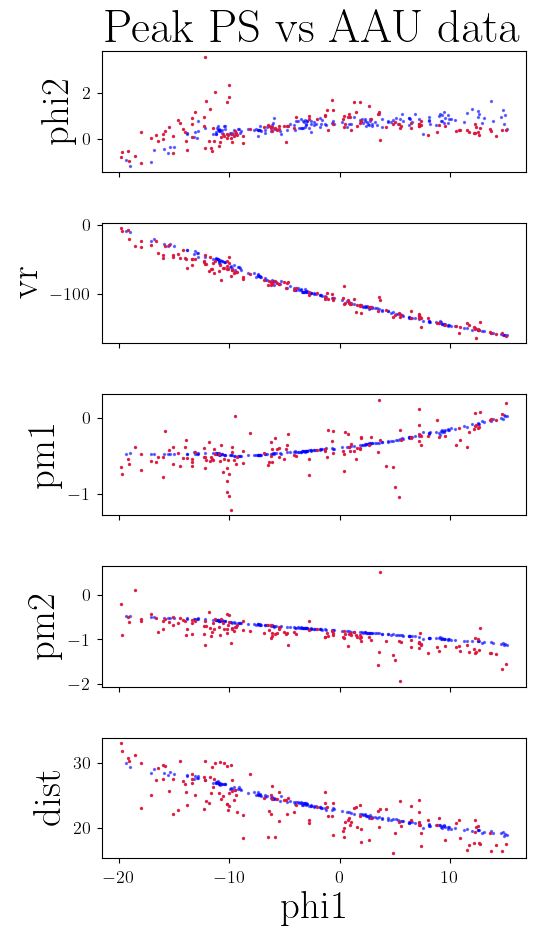

In [40]:
features = ['phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist']

phi1_ps_peak = feats[:, 0]
mask = (phi1_ps_peak >= -20) & (phi1_ps_peak < 16)
feats_cut = feats[mask]
phi1_cut  = feats_cut[:, 0]

# Raw AAU data exactly as it was fed to the model -- data[i].x, before any
# detrending/normalization -- so this reflects upstream edits to `aau`
# (e.g. the synthetic kink stars). aau_cut reloads
# combined_members_prepared.csv fresh in its own cell and would miss those.
stream_used = d.x.numpy()
phi1_used = stream_used[:, 0]
mask_used = (phi1_used >= -20) & (phi1_used < 16)
stream_used_cut = stream_used[mask_used]

fig, axes = plt.subplots(5, figsize=(6, 10), sharex=True)
for j, ax in enumerate(axes):
    #ax.scatter(phi1_nbody,        stream_nbody[:, 1 + j], s=0.5, c='k',         alpha=0.5, label='N-body (obs)')
    ax.scatter(phi1_cut,          feats_cut[:, 1 + j],    s=2, c='blue', alpha=0.5, label='PS (peak)')
    ax.scatter(stream_used_cut[:, 0], stream_used_cut[:, 1 + j],
               s=2, c='crimson', alpha=0.9, label='AAU data (as fed to model, pre-norm)', zorder=5)
    ax.set_ylabel(features[j + 1])

#axes[0].legend(markerscale=2, loc='upper right')
axes[-1].set_xlabel('phi1')
axes[0].set_title('Peak PS vs AAU data')
plt.tight_layout()
plt.show()

In [41]:
top100_idx = np.argsort(log_probs_np)[::-1][:100]
top1000_idx = np.argsort(log_probs_np)[::-1][:1000]

In [42]:
top100_feats = []
top1000_feats = []
w_impact_all = []
t_impact_all = []

for rank, idx in enumerate(top1000_idx):
    params = dict(zip(labels_sub, all_posteriors_flat[idx].flatten()))
    print(f"Simulating rank {rank + 1} / 100 ...")

    pert = sfr.create_perturber_dict(
        stream_today_cart        = stream_cart,
        stream_today_phi1        = stream_phi1,
        potential                = potTotal,
        mass_perturber           = 10 ** params["log_mass"],
        scaleradius_perturber    = 10 ** params["log_scale_radius"],
        impact_phi1              = params["phi1_impact_today"],
        impact_time              = float(params["time_impact"]),
        impact_parameter         = params["impact_parameter"],
        v_rel_parallel           = params["v_rel_para"],
        v_rel_perpendicular      = params["v_rel_perp"],
        alpha_position           = params["angle_pos_at_impact"],
        alpha_velocity           = params["angle_pos_at_impact"] + params["delta_angle"],
        time_window              = sfr.compute_time_window(
                                       params["v_rel_perp"], params["v_rel_para"],
                                       params["impact_parameter"])
    )

    feats_i, _ = simulate_stream_from_pert(pert, meta, distrib_stripping)
    top1000_feats.append(feats_i)
    w_impact_all.append(pert["w_subhalo_impact"])
    t_impact_all.append(pert["time_impact"])

print("Done.")

Simulating rank 1 / 100 ...
Simulating rank 2 / 100 ...
Simulating rank 3 / 100 ...
Simulating rank 4 / 100 ...
Simulating rank 5 / 100 ...
Simulating rank 6 / 100 ...
Simulating rank 7 / 100 ...
Simulating rank 8 / 100 ...
Simulating rank 9 / 100 ...
Simulating rank 10 / 100 ...
Simulating rank 11 / 100 ...
Simulating rank 12 / 100 ...
Simulating rank 13 / 100 ...
Simulating rank 14 / 100 ...
Simulating rank 15 / 100 ...
Simulating rank 16 / 100 ...
Simulating rank 17 / 100 ...
Simulating rank 18 / 100 ...
Simulating rank 19 / 100 ...
Simulating rank 20 / 100 ...
Simulating rank 21 / 100 ...
Simulating rank 22 / 100 ...
Simulating rank 23 / 100 ...
Simulating rank 24 / 100 ...
Simulating rank 25 / 100 ...
Simulating rank 26 / 100 ...
Simulating rank 27 / 100 ...
Simulating rank 28 / 100 ...
Simulating rank 29 / 100 ...
Simulating rank 30 / 100 ...
Simulating rank 31 / 100 ...
Simulating rank 32 / 100 ...
Simulating rank 33 / 100 ...
Simulating rank 34 / 100 ...
Simulating rank 35 / 10

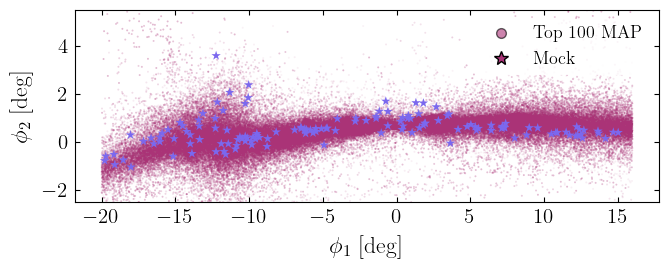

In [43]:
plot_pretty(dpi=175, fontsize=17, labelsize=15, figsize=(8, 4), tex=True)

from matplotlib.lines import Line2D

alphas = np.linspace(0.05, 0.35, 1000)[::-1]

fig, ax = plt.subplots(1, 1, figsize=(7, 3))

for rank, feats_i in enumerate(top1000_feats):
    phi1_i      = feats_i[:, 0]
    mask_i      = (phi1_i >= phi1_min) & (phi1_i < phi1_max)
    feats_cut_i = feats_i[mask_i]
    ax.scatter(
        feats_cut_i[:, 0], feats_cut_i[:, 1],
        s=2, c=color_aau, alpha=alphas[rank],
        edgecolors='none', rasterized=True,
    )

# # Original PS — stars
# ax.scatter(
#     ps_phi1, ps_cols['phi2'],
#     s=40, c=color_aau, alpha=0.9, zorder=6,
#     marker='*', edgecolors='none', rasterized=True,
# )

#ax.scatter(phi1, coord['phi2'], s=0.5, c=color_aau, marker='*', alpha=0.5)

ax.scatter(stream_used_cut[:, 0], stream_used_cut[:, 1],
               s=50, c='mediumslateblue', alpha=1.0, zorder=6, marker='*', edgecolors='none', rasterized=True)


#ax.set_ylim(ylims[0])
ax.set_ylabel(r'$\phi_2$ [deg]', labelpad=6)
ax.set_xlabel(r'$\phi_1$ [deg]', labelpad=6)
ax.yaxis.set_minor_locator(plt.AutoLocator())
ax.tick_params(which='both', direction='in', top=True, right=True)

legend_elements = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=color_aau,
           markersize=7, alpha=0.6, label='Top 100 MAP'),
    Line2D([0], [0], marker='*', color='none', markerfacecolor=color_aau,
           markersize=10, label='Mock'),
]

ax.legend(handles=legend_elements, loc='upper right',
          framealpha=0.85, edgecolor='none', fontsize=13)
#ax.set_title('Top 100 MAP Streams — Spatial', fontsize=16, pad=10)
ax.set_ylim(-2.5, 5.5)
plt.tight_layout()
plt.show()

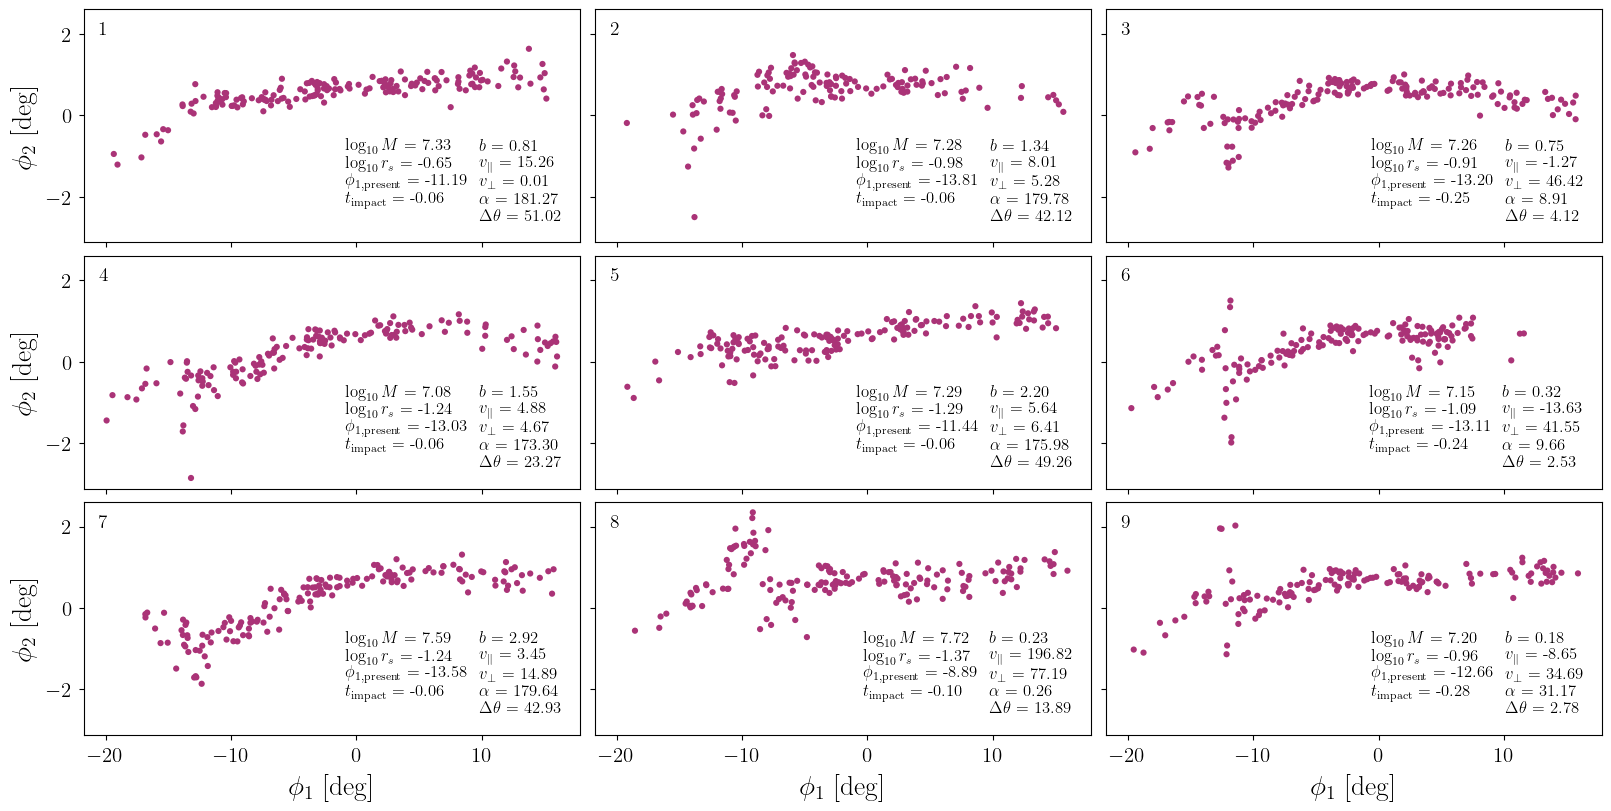

In [44]:
from matplotlib.offsetbox import TextArea, HPacker, AnchoredOffsetbox
plot_pretty(dpi=175, fontsize=17, labelsize=15, figsize=(8, 4), tex=True)

fig, axes = plt.subplots(
    3, 3,
    figsize=(16, 8),
    sharex=True, sharey=True,   # drop these if panels need independent axes
    layout="constrained",       # handles spacing automatically
)

param_tex = {
    "log_mass":            r"$\log_{10} M$",
    "log_scale_radius":    r"$\log_{10} r_s$",
    "phi1_impact_today":   r"$\phi_{1,\rm present}$",
    "time_impact":         r"$t_{\rm impact}$",
    "impact_parameter":    r"$b$",
    "v_rel_para":          r"$v_\parallel$",
    "v_rel_perp":          r"$v_\perp$",
    "angle_pos_at_impact": r"$\alpha$",
    "delta_angle":         r"$\Delta\theta$",
}

for rank, (feats_i, ax) in enumerate(zip(top1000_feats, axes.flat)):
    phi1_i = feats_i[:, 0]
    mask_i = (phi1_i >= phi1_min) & (phi1_i < phi1_max)
    feats_cut_i = feats_i[mask_i]

    ax.scatter(
        feats_cut_i[:, 0], feats_cut_i[:, 1],
        s=20, c=color_aau, alpha=1,
        edgecolors='none', rasterized=True,
    )

    params = dict(zip(labels_sub, all_posteriors_flat[top1000_idx[rank]].flatten()))

    items = [f"{param_tex[k]} = {v:.2f}" for k, v in params.items()]

    col1 = TextArea("\n".join(items[:4]), textprops=dict(fontsize=12))
    col2 = TextArea("\n".join(items[4:]), textprops=dict(fontsize=12))

    box = HPacker(children=[col1, col2], align="top", pad=0, sep=8)
    anchored = AnchoredOffsetbox(
        loc="lower right", child=box,
        pad=0.3, borderpad=0.5, frameon=True,
    )
    anchored.patch.set(facecolor="white", alpha=0.8, edgecolor="none")
    ax.add_artist(anchored)
    ax.text(
        0.03, 0.95, f"{rank + 1}",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=14,
    )


for ax in axes[-1, :]:
    ax.set_xlabel(r'$\phi_1$ [deg]', labelpad=6, fontsize=20)
for ax in axes[:, 0]:
    ax.set_ylabel(r'$\phi_2$ [deg]', fontsize=20, labelpad=6)

plt.savefig("top9_streams_with_params.pdf", bbox_inches="tight", dpi=300)

In [45]:
# I want to predict where the subhalo could potentially be today by making a molleweide plot of the subhalo's present day position on sky


#step 1, getting all the orbits to present day

w_impact_all = np.array(w_impact_all)   # (N, 6)
t_impact_all = np.array(t_impact_all)   # (N,), negative

orbits = agama.orbit(
    potential=potTotal,
    ic=w_impact_all,
    timestart=t_impact_all,
    time=-t_impact_all,      # integrate forward to t = 0
    trajsize=2,
)

w_today = np.array([traj[-1] for _, traj in orbits])   # (N, 6), Galactocentric
t_end   = np.array([times[-1] for times, _ in orbits])
print(np.abs(t_end).max())   # should be ~0

0.0


1000 orbits complete (47619 orbits/s)


In [46]:
#Checking it did it right

N = len(w_today)
back = agama.orbit(
    potential=potTotal, ic=w_today,
    timestart=np.zeros(N), time=t_impact_all, trajsize=2,
)
w_back = np.array([traj[-1] for _, traj in back])

print(np.abs(w_back - w_impact_all).max(axis=0))   # [kpc x3, km/s x3]

[4.95839741e-05 1.26846565e-04 1.16886617e-04 6.81437656e-05
 1.46975112e-03 3.00188164e-04]


1000 orbits complete (50000 orbits/s)


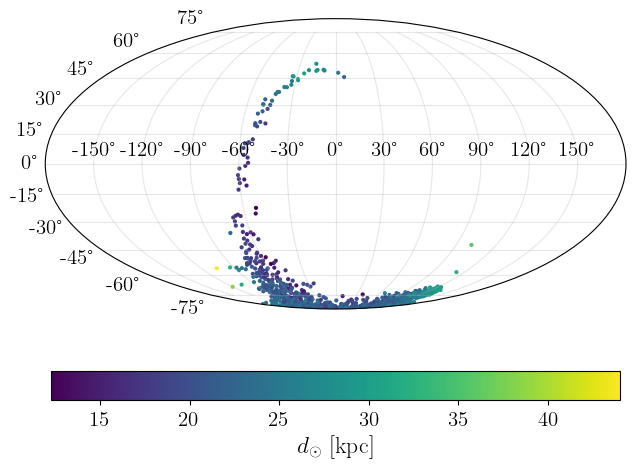

In [47]:
import astropy.units as u
from astropy.coordinates import SkyCoord, Galactocentric, Galactic

c = SkyCoord(
    x=w_today[:, 0]*u.kpc, y=w_today[:, 1]*u.kpc, z=w_today[:, 2]*u.kpc,
    v_x=w_today[:, 3]*u.km/u.s, v_y=w_today[:, 4]*u.km/u.s, v_z=w_today[:, 5]*u.km/u.s,
    frame=Galactocentric(),
).transform_to(Galactic())

l = c.l.wrap_at(180*u.deg).rad
b = c.b.rad
d = c.distance.kpc

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(projection="mollweide")
sc = ax.scatter(-l, b, c=d, s=4, cmap="viridis", rasterized=True)
fig.colorbar(sc, ax=ax, orientation="horizontal", shrink=0.6, label=r"$d_\odot$ [kpc]")
ax.grid(True, alpha=0.3)

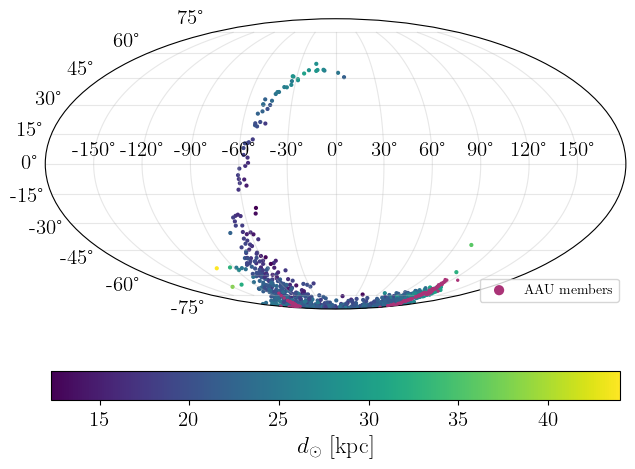

In [48]:
c_aau = SkyCoord(
    ra=aau["ra"].values * u.deg,
    dec=aau["dec"].values * u.deg,
    distance=aau["distance_kpc"].values * u.kpc,
    frame="icrs",
)

# Galactocentric Cartesian, same frame as w_today (kpc)
c_aau_galcen = c_aau.transform_to(Galactocentric())
xyz_aau = np.vstack([
    c_aau_galcen.x.to(u.kpc).value,
    c_aau_galcen.y.to(u.kpc).value,
    c_aau_galcen.z.to(u.kpc).value,
]).T

# heliocentric Galactic for the Mollweide overlay
c_aau_gal = c_aau.transform_to(Galactic())
l_aau = c_aau_gal.l.wrap_at(180*u.deg).rad
b_aau = c_aau_gal.b.rad

ax.scatter(-l_aau, b_aau, s=6, color=color_aau, edgecolors="none",
           label="AAU members", zorder=4, rasterized=True)
ax.legend(loc="lower right", fontsize=10, markerscale=3)
fig

In [49]:
import pandas as pd
import os
os.chdir('/global/homes/e/emarin4/scratch/training_sims/aau_sbi_fastsims/workspace/notebooks/local_volume_database')

gc_harris = pd.read_csv('data/gc_harris.csv')
gc_new    = pd.read_csv('data/gc_mw_new.csv')
gc_all    = pd.concat([gc_harris, gc_new], ignore_index=True)
dwarfs    = pd.read_csv('data/dwarf_mw.csv')

print(list(gc_all.columns))
c_dwarf = SkyCoord(
     ra=dwarfs["ra"].values * u.deg,
     dec=dwarfs["dec"].values * u.deg,
     distance=(10**((dwarfs["distance_modulus"].values + 5)/5))/1000 * u.kpc,
     frame="icrs",
)

c_gc = SkyCoord(
        ra=gc_all["ra"].values * u.deg,
        dec=gc_all["dec"].values * u.deg,
        distance=(10**((gc_all["distance_modulus"].values + 5)/5))/1000 * u.kpc,
        frame="icrs",
    )

# # Galactocentric Cartesian, same frame as w_today (kpc)
c_dwarf_galcen = c_dwarf.transform_to(Galactocentric())
c_gc_galcen = c_gc.transform_to(Galactocentric())

xyz_dwarf = np.vstack([
    c_dwarf_galcen.x.to(u.kpc).value,
    c_dwarf_galcen.y.to(u.kpc).value,
    c_dwarf_galcen.z.to(u.kpc).value,
]).T

xyz_gc = np.vstack([
    c_gc_galcen.x.to(u.kpc).value,
    c_gc_galcen.y.to(u.kpc).value,
    c_gc_galcen.z.to(u.kpc).value,
]).T




['key', 'ra', 'dec', 'name', 'host', 'confirmed_real', 'confirmed_galaxy', 'rhalf', 'rhalf_em', 'rhalf_ep', 'position_angle', 'position_angle_em', 'position_angle_ep', 'ellipticity', 'ellipticity_em', 'ellipticity_ep', 'ellipticity_ul', 'ref_structure', 'distance_modulus', 'distance_modulus_em', 'distance_modulus_ep', 'ref_distance', 'apparent_magnitude_v', 'apparent_magnitude_v_em', 'apparent_magnitude_v_ep', 'ref_m_v', 'vlos_systemic', 'vlos_systemic_em', 'vlos_systemic_ep', 'vlos_sigma', 'vlos_sigma_em', 'vlos_sigma_ep', 'vlos_sigma_ul', 'ref_vlos', 'pmra', 'pmra_em', 'pmra_ep', 'pmdec', 'pmdec_em', 'pmdec_ep', 'ref_proper_motion', 'metallicity_spectroscopic', 'metallicity_spectroscopic_em', 'metallicity_spectroscopic_ep', 'metallicity_spectroscopic_sigma', 'metallicity_spectroscopic_sigma_em', 'metallicity_spectroscopic_sigma_ep', 'metallicity_spectroscopic_sigma_ul', 'ref_metallicity_spectroscopic', 'rcore', 'rcore_em', 'rcore_ep', 'rking', 'rking_em', 'rking_ep', 'ref_structure_k

In [50]:
from astropy.coordinates import SkyCoord, SkyOffsetFrame, Galactic
import astropy.units as u
import numpy as np

center = SkyCoord(l=0*u.deg, b=-90*u.deg, frame=Galactic())
off_frame = SkyOffsetFrame(origin=center, rotation=180*u.deg)

def to_offset(coord):
    o = coord.transform_to(off_frame)
    return o.lon.wrap_at(180*u.deg).rad, o.lat.rad

def gal(lon_deg, lat_deg):
    return SkyCoord(l=lon_deg*u.deg, b=lat_deg*u.deg, frame=Galactic())

def plot_sky_curve(ax, lon_deg, lat_deg, **kw):
    """Plot a Galactic (l, b) curve in the rotated frame, splitting at the seam."""
    x, y = to_offset(gal(lon_deg, lat_deg))
    x = -x
    breaks = np.where(np.abs(np.diff(x)) > np.pi)[0] + 1
    for i, (xs, ys) in enumerate(zip(np.split(x, breaks), np.split(y, breaks))):
        ax.plot(xs, ys, **(kw if i == 0 else {k: v for k, v in kw.items() if k != "label"}))


def sky_text(ax, lon_deg, lat_deg, s, **kw):
    x, y = to_offset(gal(lon_deg, lat_deg))
    ax.text(-x, y, s, **kw)
    

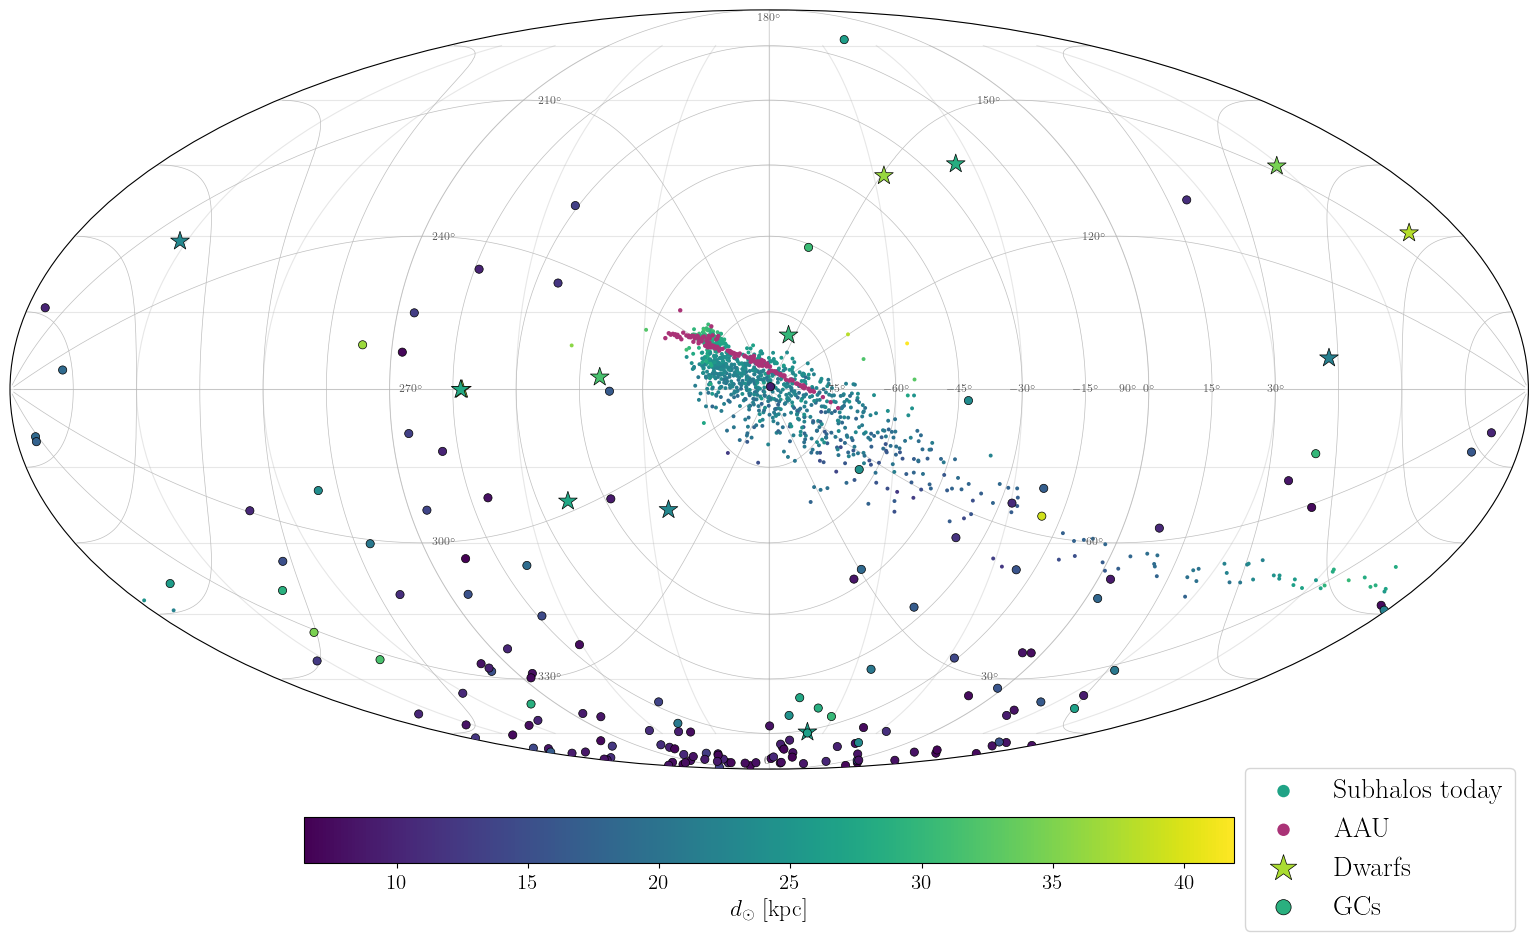

In [51]:
from astropy.coordinates import SkyOffsetFrame

# impact-time positions (from the round-trip check)
c_imp = SkyCoord(
    x=w_back[:, 0]*u.kpc, y=w_back[:, 1]*u.kpc, z=w_back[:, 2]*u.kpc,
    frame=Galactocentric(),
).transform_to(Galactic())

# map centered on the south Galactic pole, spun 180° about the center
center = SkyCoord(l=0*u.deg, b=-90*u.deg, frame=Galactic())
off_frame = SkyOffsetFrame(origin=center, rotation=180*u.deg)

def to_offset(coord):
    o = coord.transform_to(off_frame)
    return o.lon.wrap_at(180*u.deg).rad, o.lat.rad

x_now, y_now = to_offset(c)
x_imp, y_imp = to_offset(c_imp)
x_aau, y_aau = to_offset(c_aau_gal)

d_imp = c_imp.distance.kpc


fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(projection="mollweide")

#plotting the trajectories from impact to today
#for i in range(len(x_now)):
    #if abs(x_now[i] - x_imp[i]) < np.pi:
        #ax.plot([-x_imp[i], -x_now[i]], [y_imp[i], y_now[i]],
                #color="0.6", lw=0.3, alpha=0.3, zorder=1)

#ax.scatter(-x_imp, y_imp, c=d_imp, cmap="viridis", norm=norm,
           #s=10, marker="^", edgecolors="none",

#Only plotting the gcs and dwarfs within some distance range
d_lo = aau.distance_kpc.min() - 10
d_hi = aau.distance_kpc.max() + 10
norm = plt.Normalize(vmin=min(d_lo, d_imp.min()), vmax=max(d_hi, d_imp.max()))

# in_slice = (d >= d_lo) & (d <= d_hi)

# print(f"{in_slice.sum()} / {len(d)} subhalos in [{d_lo:.1f}, {d_hi:.1f}] kpc")

sc = ax.scatter(-x_now, y_now, c=d, cmap="viridis", norm=norm,
                s=8, marker="o", edgecolors="none",
                label="Subhalos today", zorder=3, rasterized=True)

ax.scatter(-x_aau, y_aau, s=10, color=color_aau, edgecolors="none",
           label="AAU", zorder=4, rasterized=True)

# mark the south Galactic pole at the map center
#ax.plot(0, 0, marker="+", color="k", ms=10, mew=1.5, zorder=5)

ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(True, alpha=0.3)

leg = ax.legend(loc="lower right", fontsize=10, markerscale=3)
for h in leg.legend_handles[:2]:
    h.set_color("0.4")

ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(True, alpha=0.3)
fig.colorbar(sc, ax=ax, orientation="horizontal", shrink=0.6, pad=0.05,
             label=r"$d_\odot$ [kpc]")
ax.legend(loc="lower right", fontsize=10, markerscale=3)


# Galactic graticule
grid_kw = dict(color="0.75", lw=0.5, zorder=0)
for bb in range(-75, 90, 15):
    plot_sky_curve(ax, np.linspace(0, 360, 361), np.full(361, bb), **grid_kw)
for ll in range(0, 360, 30):
    plot_sky_curve(ax, np.full(179, ll), np.linspace(-89, 89, 179), **grid_kw)

# graticule labels: b along one meridian, l just inside the Galactic plane
lab_lon = 90
lab_kw = dict(fontsize=8, color="0.35", ha="center", va="center", zorder=6)
for bb in (-75, -60, -45, -30, -15, 0, 15, 30):
    sky_text(ax, lab_lon, bb, rf"${bb}^\circ$", **lab_kw)
for ll in range(0, 360, 30):
    sky_text(ax, ll, -5, rf"${ll}^\circ$", **lab_kw)


#plotting an ellipse instead of the indiviudal subhalos
def sky_ellipse(l0, b0, a, b_ax, pa, n=400):
    """
    Ellipse on the sky, returned as a Galactic SkyCoord.

    l0, b0 : center in Galactic coordinates [deg]
    a, b_ax: semi-major and semi-minor axes [deg]
    pa     : position angle of the major axis [deg], measured from
             north (+b) toward increasing l
    """
    center = SkyCoord(l=l0*u.deg, b=b0*u.deg, frame=Galactic())
    phi = np.linspace(0, 2*np.pi, n)                 # direction from center
    dphi = phi - np.radians(pa)                      # angle from major axis
    r = a * b_ax / np.sqrt((b_ax*np.cos(dphi))**2 + (a*np.sin(dphi))**2)
    return center.directional_offset_by(phi*u.rad, r*u.deg)

def plot_sky_coord_curve(ax, coord, **kw):
    """Plot a SkyCoord curve in the rotated frame, splitting at the ±180° seam."""
    x, y = to_offset(coord)
    x = -x
    breaks = np.where(np.abs(np.diff(x)) > np.pi)[0] + 1
    for i, (xs, ys) in enumerate(zip(np.split(x, breaks), np.split(y, breaks))):
        ax.plot(xs, ys, **(kw if i == 0 else {k: v for k, v in kw.items() if k != "label"}))


#ell = sky_ellipse(l0=65, b0=-75, a=40, b_ax=8, pa=3)
#plot_sky_coord_curve(ax, ell, color="k", lw=1.2, ls="--", zorder=5, label="by eye")

x_dw, y_dw = to_offset(c_dwarf.transform_to(Galactic()))
x_gc, y_gc = to_offset(c_gc.transform_to(Galactic()))

d_dw = c_dwarf.distance.kpc
d_gc = c_gc.distance.kpc

d_dw_mask = (d_dw >= d_lo) & (d_dw <= d_hi)
d_gc_mask = (d_gc >= d_lo) & (d_gc <= d_hi)

ax.scatter(-x_dw[d_dw_mask], y_dw[d_dw_mask], c=d_dw[d_dw_mask], cmap="viridis", norm=norm,
           marker="*", s=200, edgecolors="k", linewidths=0.5,
           zorder=6, label="Dwarfs")
ax.scatter(-x_gc[d_gc_mask], y_gc[d_gc_mask], c=d_gc[d_gc_mask], cmap="viridis", norm=norm,
           marker="o", s=35, edgecolors="k", linewidths=0.5,
           zorder=6, label="GCs")

leg = ax.legend(loc="upper right", bbox_to_anchor=(1.0, 0.02),
                fontsize=20, markerscale=1)

sizes = {"Subhalos today": 80, "AAU": 80, "Dwarfs": 400, "GCs": 120}
for h in leg.legend_handles:
    lab = h.get_label()
    h.set_sizes([sizes[lab]])
    if lab in ("Subhalos today", "Dwarfs", "GCs"):
        h.set_facecolor("0.6")

plt.savefig("/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/subhalo_positions_mollweide.pdf", bbox_inches="tight", dpi=300)

Dwarfs: 13 arrows, 1 without vlos (assumed 0, dashed), speed 142-387 km/s
GCs: 155 arrows, 13 without vlos (assumed 0, dashed), speed 20-733 km/s


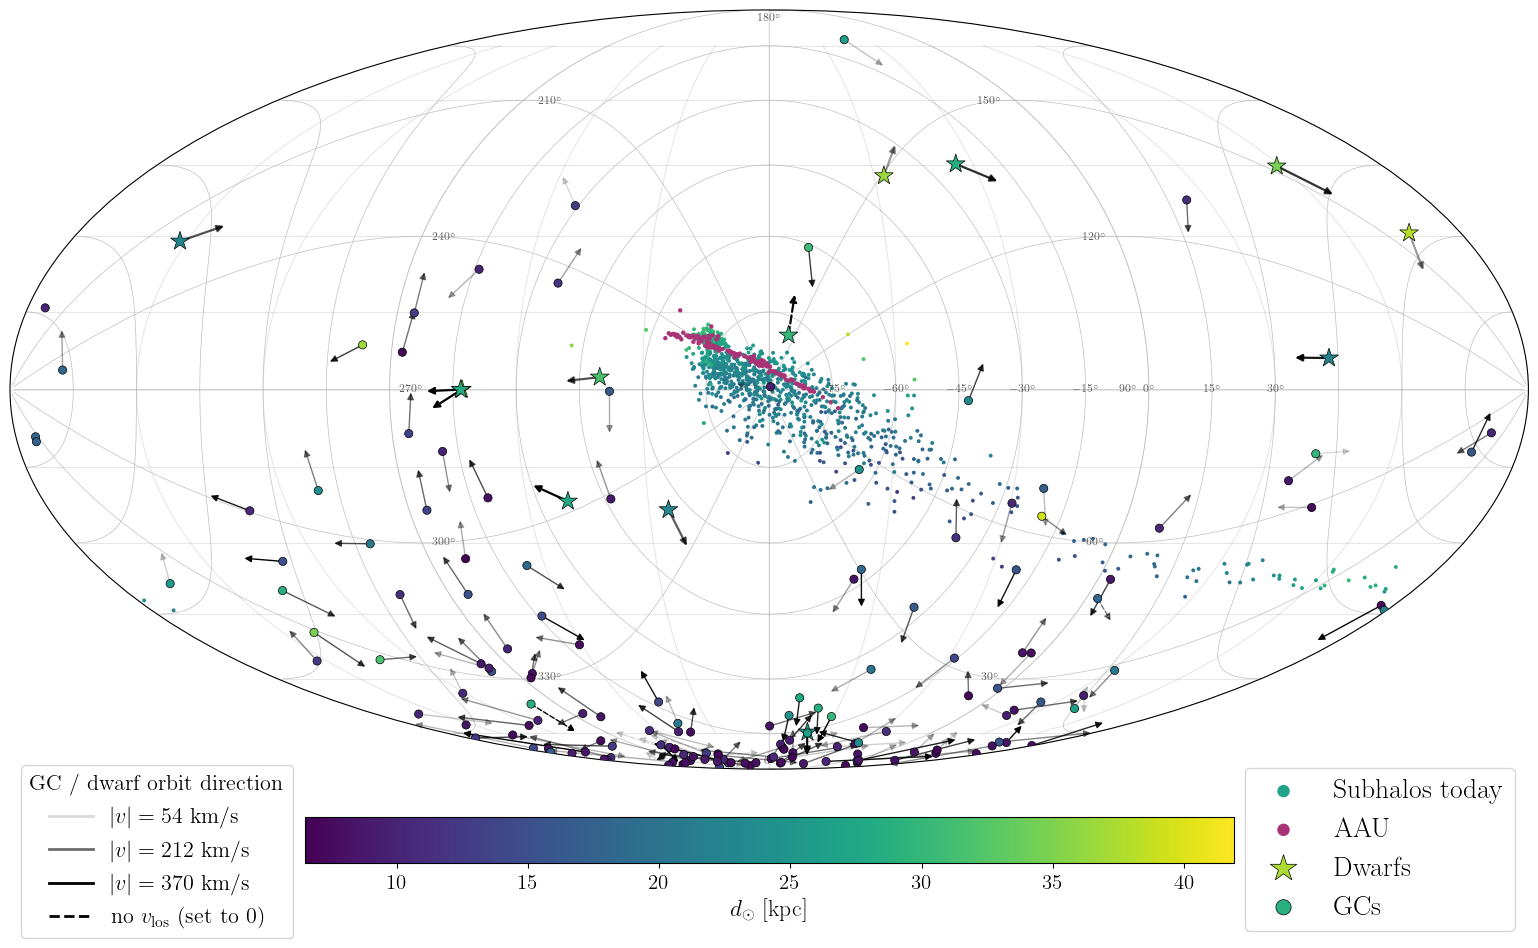

In [52]:
# ── orbital-direction arrows for GCs and dwarfs ───────────────────────────────
from matplotlib.lines import Line2D
from astropy.coordinates import CartesianRepresentation

ARROW_LEN_DEG = 8.0          # arrow length on the sky (same for every object)
DT            = 0.1 * u.Myr  # step used only to get the direction of motion
ALPHA_MIN, ALPHA_MAX = 0.15, 1.0

def galcen_kinematics(cat, dist_kpc):
    """Galactocentric position/velocity for a catalog; missing vlos -> 0 (flagged)."""
    no_vlos = cat["vlos_systemic"].isna().to_numpy()
    c6 = SkyCoord(
        ra=cat["ra"].values * u.deg, dec=cat["dec"].values * u.deg,
        distance=dist_kpc * u.kpc,
        pm_ra_cosdec=cat["pmra"].values * u.mas/u.yr,
        pm_dec=cat["pmdec"].values * u.mas/u.yr,
        radial_velocity=np.nan_to_num(cat["vlos_systemic"].values) * u.km/u.s,
        frame="icrs",
    ).transform_to(Galactocentric())
    return c6, no_vlos

def orbit_arrows(cat, dist_kpc, sel):
    """Arrow start/end in map coords, Galactocentric speed, and a no-vlos flag."""
    has_pm = cat["pmra"].notna().to_numpy() & cat["pmdec"].notna().to_numpy()
    sel = sel & has_pm
    c6, no_vlos = galcen_kinematics(cat[sel], dist_kpc[sel])

    pos = c6.cartesian.without_differentials()
    vel = c6.velocity                                   # CartesianDifferential, km/s
    speed = vel.norm().to_value(u.km/u.s)

    # step along the Galactocentric velocity -> where it moves on the (heliocentric) sky
    step = CartesianRepresentation((vel.d_xyz * DT).to(u.kpc))
    now  = SkyCoord(pos,        frame=Galactocentric()).transform_to(Galactic())
    nxt  = SkyCoord(pos + step, frame=Galactocentric()).transform_to(Galactic())

    pa  = now.position_angle(nxt)
    end = now.directional_offset_by(pa, ARROW_LEN_DEG * u.deg)

    x0, y0 = to_offset(now)
    x1, y1 = to_offset(end)
    return -x0, y0, -x1, y1, speed, no_vlos

d_dw_all = (10**((dwarfs["distance_modulus"].values + 5)/5)) / 1000
d_gc_all = (10**((gc_all["distance_modulus"].values + 5)/5)) / 1000

arrows = {
    "Dwarfs": orbit_arrows(dwarfs, d_dw_all, (d_dw_all >= d_lo) & (d_dw_all <= d_hi)),
    "GCs":    orbit_arrows(gc_all, d_gc_all, (d_gc_all >= d_lo) & (d_gc_all <= d_hi)),
}

# alpha scales linearly with Galactocentric speed, shared across GCs + dwarfs
all_speed = np.concatenate([a[4] for a in arrows.values()])
v_lo, v_hi = np.percentile(all_speed, [5, 95])
def speed_alpha(v):
    return ALPHA_MIN + (ALPHA_MAX - ALPHA_MIN) * np.clip((v - v_lo) / (v_hi - v_lo), 0, 1)

for kind, (x0, y0, x1, y1, speed, no_vlos) in arrows.items():
    lw = 1.6 if kind == "Dwarfs" else 1.0
    for i in range(len(x0)):
        if abs(x1[i] - x0[i]) > np.pi / 2:      # arrow would cross the ±180° seam
            continue
        ax.annotate(
            "", xy=(x1[i], y1[i]), xytext=(x0[i], y0[i]),
            arrowprops=dict(arrowstyle="-|>", color="k", lw=lw, alpha=speed_alpha(speed[i]),
                            linestyle="--" if no_vlos[i] else "-",
                            shrinkA=0, shrinkB=0, mutation_scale=10),
            zorder=5,
        )
    print(f"{kind}: {len(x0)} arrows, {no_vlos.sum()} without vlos (assumed 0, dashed), "
          f"speed {speed.min():.0f}-{speed.max():.0f} km/s")

# second legend: speed -> alpha key
key_v = np.linspace(v_lo, v_hi, 3)
key_handles = [Line2D([], [], color="k", lw=2, alpha=speed_alpha(v)) for v in key_v]
key_handles.append(Line2D([], [], color="k", lw=2, ls="--"))
key_labels = [rf"$|v| = {v:.0f}$ km/s" for v in key_v] + [r"no $v_{\rm los}$ (set to 0)"]
key = ax.legend(key_handles, key_labels, loc="upper left", bbox_to_anchor=(0.0, 0.02),
                fontsize=16, title="GC / dwarf orbit direction", title_fontsize=16)
ax.add_artist(leg)     # keep the original legend too

fig.savefig("/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/subhalo_positions_mollweide_orbits.pdf",
            bbox_inches="tight", dpi=300)
fig


In [54]:
is_cet = (dwarfs["name"] == "Cetus II").to_numpy()


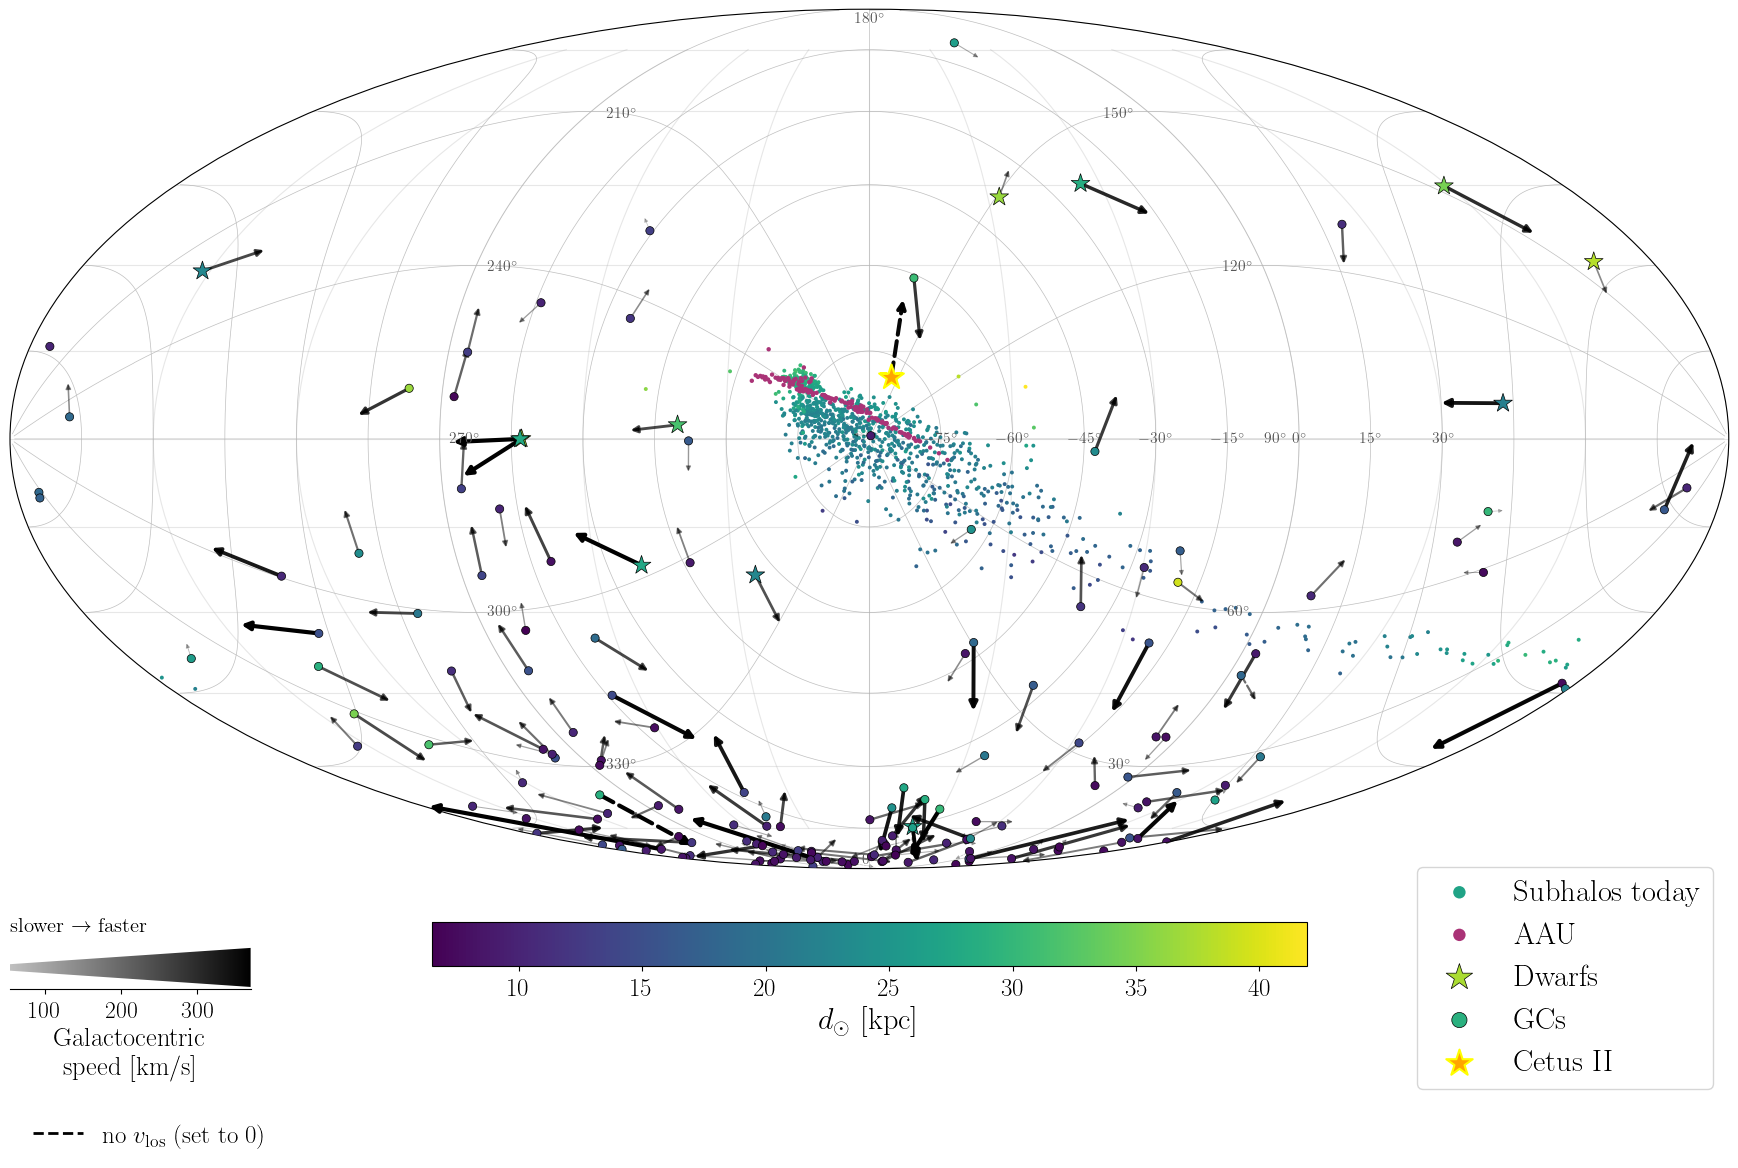

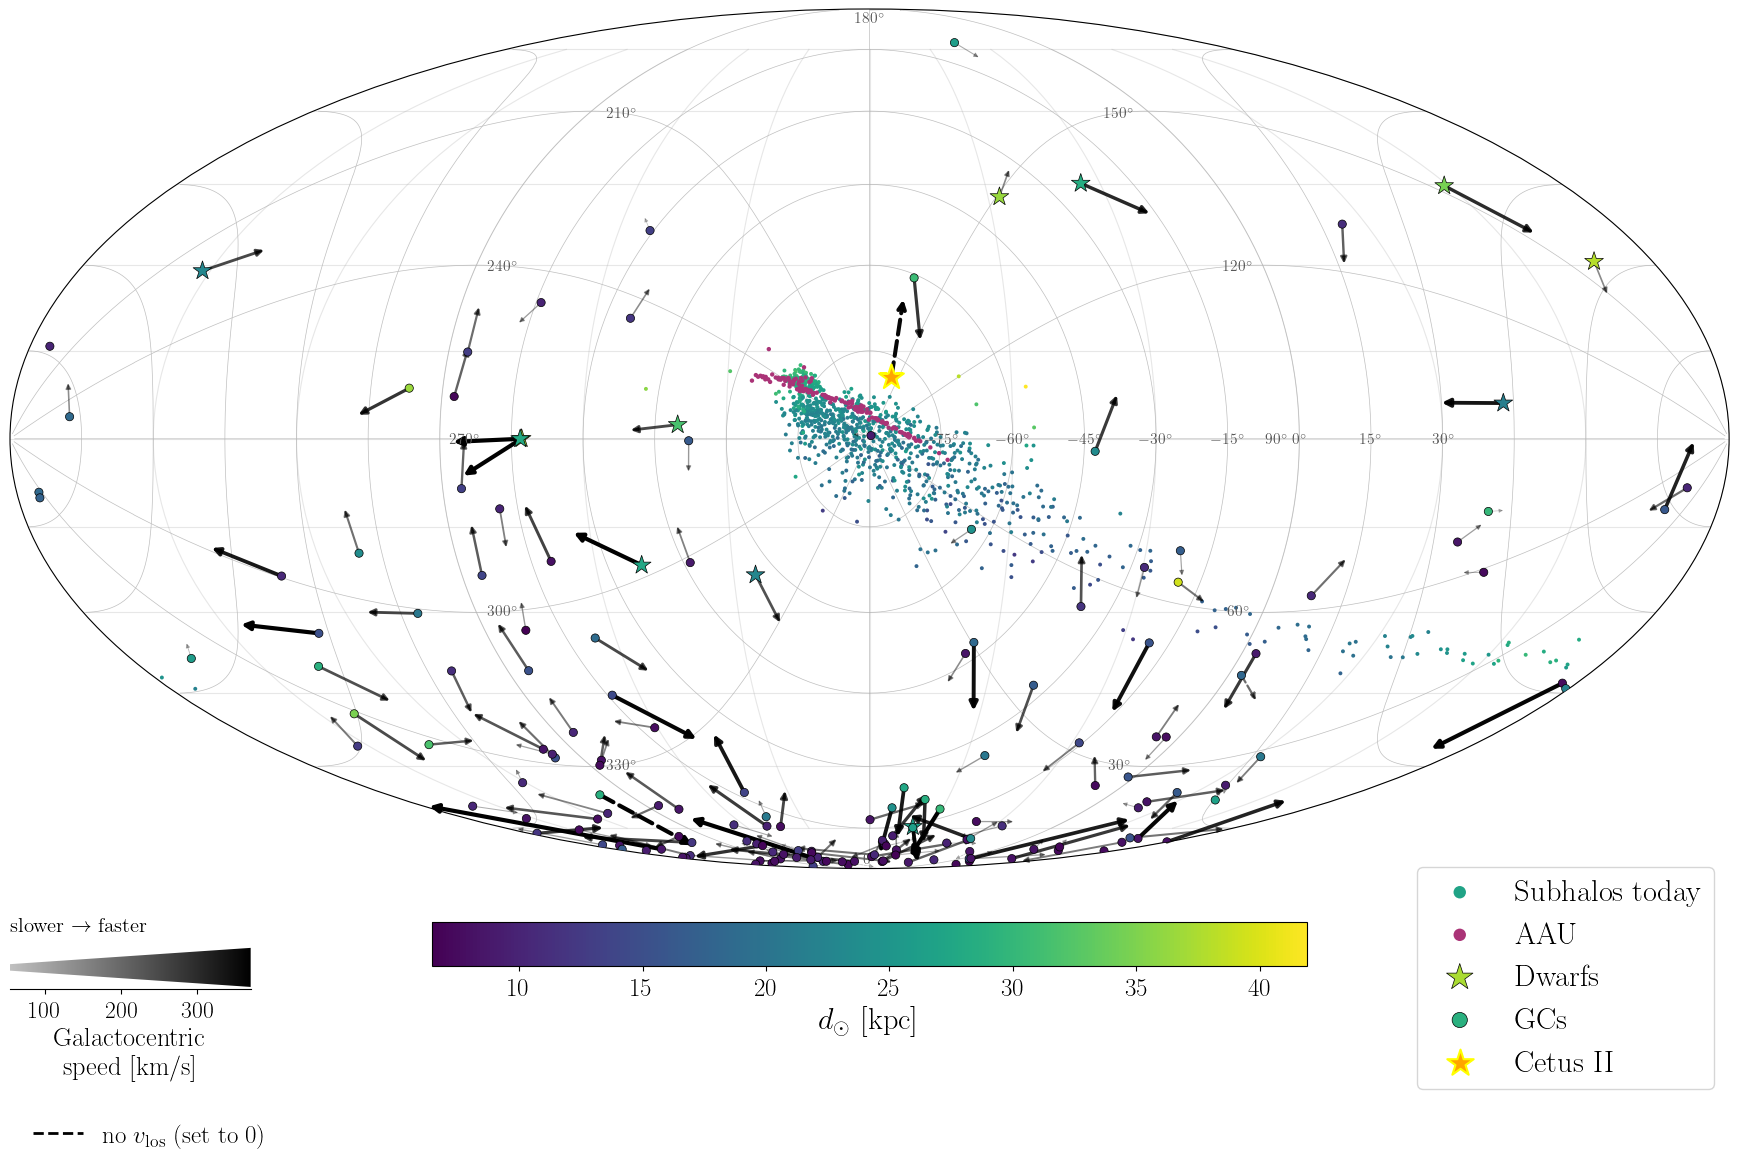

In [56]:
# ── version 2: speed -> shading + line thickness + arrow length ──────────────
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
from astropy.coordinates import CartesianRepresentation

LEN_MIN, LEN_MAX     = 3.0, 14.0    # arrow length on the sky [deg]
LW_MIN,  LW_MAX      = 0.5, 3.0     # line width [pt]
ALPHA_MIN, ALPHA_MAX = 0.25, 1.0
DT = 0.1 * u.Myr                    # step used only to get the direction of motion

def orbit_direction(cat, dist_kpc, sel):
    """Galactic position now, sky position angle of Galactocentric motion, speed, no-vlos flag."""
    sel = sel & cat["pmra"].notna().to_numpy() & cat["pmdec"].notna().to_numpy()
    sub = cat[sel]
    no_vlos = sub["vlos_systemic"].isna().to_numpy()
    c6 = SkyCoord(
        ra=sub["ra"].values * u.deg, dec=sub["dec"].values * u.deg,
        distance=dist_kpc[sel] * u.kpc,
        pm_ra_cosdec=sub["pmra"].values * u.mas/u.yr,
        pm_dec=sub["pmdec"].values * u.mas/u.yr,
        radial_velocity=np.nan_to_num(sub["vlos_systemic"].values) * u.km/u.s,
        frame="icrs",
    ).transform_to(Galactocentric())
    pos, vel = c6.cartesian.without_differentials(), c6.velocity
    step = CartesianRepresentation((vel.d_xyz * DT).to(u.kpc))
    now = SkyCoord(pos,        frame=Galactocentric()).transform_to(Galactic())
    nxt = SkyCoord(pos + step, frame=Galactocentric()).transform_to(Galactic())
    return now, now.position_angle(nxt), vel.norm().to_value(u.km/u.s), no_vlos

d_dw_all = (10**((dwarfs["distance_modulus"].values + 5)/5)) / 1000
d_gc_all = (10**((gc_all["distance_modulus"].values + 5)/5)) / 1000
dirs = {
    "Dwarfs": orbit_direction(dwarfs, d_dw_all, (d_dw_all >= d_lo) & (d_dw_all <= d_hi)),
    "GCs":    orbit_direction(gc_all, d_gc_all, (d_gc_all >= d_lo) & (d_gc_all <= d_hi)),
}

all_speed = np.concatenate([v[2] for v in dirs.values()])
v_lo, v_hi = np.percentile(all_speed, [5, 95])
def frac(v):
    return np.clip((v - v_lo) / (v_hi - v_lo), 0, 1)

# ── base map (same as the figure above) ──────────────────────────────────────
fig2 = plt.figure(figsize=(18, 12))
ax2 = fig2.add_subplot(projection="mollweide")

sc2 = ax2.scatter(-x_now, y_now, c=d, cmap="viridis", norm=norm, s=8, edgecolors="none",
                  label="Subhalos today", zorder=3, rasterized=True)
ax2.scatter(-x_aau, y_aau, s=10, color=color_aau, edgecolors="none",
            label="AAU", zorder=4, rasterized=True)

grid_kw = dict(color="0.75", lw=0.5, zorder=0)
for bb in range(-75, 90, 15):
    plot_sky_curve(ax2, np.linspace(0, 360, 361), np.full(361, bb), **grid_kw)
for ll in range(0, 360, 30):
    plot_sky_curve(ax2, np.full(179, ll), np.linspace(-89, 89, 179), **grid_kw)
lab_kw = dict(fontsize=11, color="0.35", ha="center", va="center", zorder=6)
for bb in (-75, -60, -45, -30, -15, 0, 15, 30):
    sky_text(ax2, 90, bb, rf"${bb}^\circ$", **lab_kw)
for ll in range(0, 360, 30):
    sky_text(ax2, ll, -5, rf"${ll}^\circ$", **lab_kw)
ax2.set_xticklabels([]); ax2.set_yticklabels([])
ax2.grid(True, alpha=0.3)

is_cet = (dwarfs["name"] == "Cetus II").to_numpy()
dw_plot = d_dw_mask & ~is_cet
ax2.scatter(-x_dw[dw_plot], y_dw[dw_plot], c=d_dw[dw_plot], cmap="viridis", norm=norm,
            marker="*", s=200, edgecolors="k", linewidths=0.5, zorder=6, label="Dwarfs")
ax2.scatter(-x_gc[d_gc_mask], y_gc[d_gc_mask], c=d_gc[d_gc_mask], cmap="viridis", norm=norm,
            marker="o", s=35, edgecolors="k", linewidths=0.5, zorder=6, label="GCs")
ax2.scatter(-x_dw[is_cet], y_dw[is_cet], marker="*", s=350, facecolor="orange",
            edgecolors="yellow", linewidths=1.5, zorder=7, label="Cetus II")

cb2 = fig2.colorbar(sc2, ax=ax2, orientation="horizontal", shrink=0.5, pad=0.05)
cb2.set_label(r"$d_\odot$ [kpc]", fontsize=22)
cb2.ax.tick_params(labelsize=18)
leg2 = ax2.legend(loc="upper right", bbox_to_anchor=(1.0, 0.02), fontsize=22, markerscale=1)
sizes = {"Subhalos today": 80, "AAU": 80, "Dwarfs": 400, "GCs": 120, "Cetus II": 400}
for h in leg2.legend_handles:
    lab = h.get_label()
    h.set_sizes([sizes[lab]])
    if lab in ("Subhalos today", "Dwarfs", "GCs"):
        h.set_facecolor("0.6")

# ── arrows: shading, thickness and length all grow with speed ────────────────
for kind, (now, pa, speed, no_vlos) in dirs.items():
    f = frac(speed)
    end = now.directional_offset_by(pa, (LEN_MIN + (LEN_MAX - LEN_MIN) * f) * u.deg)
    x0, y0 = to_offset(now); x1, y1 = to_offset(end)
    x0, x1 = -x0, -x1
    for i in range(len(x0)):
        if abs(x1[i] - x0[i]) > np.pi / 2:      # arrow would cross the ±180° seam
            continue
        lw = LW_MIN + (LW_MAX - LW_MIN) * f[i]
        ax2.annotate(
            "", xy=(x1[i], y1[i]), xytext=(x0[i], y0[i]),
            arrowprops=dict(arrowstyle="-|>", color="k", lw=lw,
                            alpha=ALPHA_MIN + (ALPHA_MAX - ALPHA_MIN) * f[i],
                            linestyle="--" if no_vlos[i] else "-",
                            shrinkA=0, shrinkB=0, mutation_scale=6 + 6 * f[i]),
            zorder=5,
        )

# ── sliding-scale key: a wedge that thickens and darkens with speed ──────────
kax = ax2.inset_axes([0.0, -0.14, 0.14, 0.05])
grad = np.linspace(0, 1, 256)[None, :]
img = kax.imshow(np.ones((1, 256)), extent=[v_lo, v_hi, -1, 1], aspect="auto",
                 cmap="gray_r", vmin=0, vmax=1,
                 alpha=ALPHA_MIN + (ALPHA_MAX - ALPHA_MIN) * grad)
h_min = LW_MIN / LW_MAX
wedge = Polygon([[v_lo, -h_min], [v_hi, -1], [v_hi, 1], [v_lo, h_min]], closed=True,
                facecolor="none", edgecolor="none", transform=kax.transData)
kax.add_patch(wedge)
img.set_clip_path(wedge)
kax.set_xlim(v_lo, v_hi); kax.set_ylim(-1.1, 1.1)
kax.set_yticks([])
for s in ("left", "right", "top"):
    kax.spines[s].set_visible(False)
kax.tick_params(labelsize=17)
kax.set_xlabel("Galactocentric\nspeed [km/s]", fontsize=19)
kax.text(0, 1.25, "slower $\\rightarrow$ faster",
         transform=kax.transAxes, fontsize=15, ha="left", va="bottom")

key2 = ax2.legend([Line2D([], [], color="k", lw=2, ls="--")], [r"no $v_{\rm los}$ (set to 0)"],
                  loc="upper left", bbox_to_anchor=(0.0, -0.27), fontsize=18, frameon=False)
ax2.add_artist(leg2)

fig2.savefig("/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/subhalo_positions_mollweide_orbits_v2.pdf",
             bbox_inches="tight", dpi=300)
fig2


In [102]:
print(d_dw.min(), d_dw.max())
print(d_gc.min(), d_gc.max())

21.57744409152669 369.8281797802659
1.8509726429316478 145.88142602753473


In [53]:
sgp = SkyCoord(l=0*u.deg, b=-90*u.deg, frame=Galactic())
c_dw_gal = c_dwarf.transform_to(Galactic())

sep = c_dw_gal.separation(sgp).deg
sep_masked = np.where(d_dw_mask, sep, np.inf)   # drop the mask to search all dwarfs
i = np.argmin(sep_masked)

row = dwarfs.iloc[i]
print(row["name"], f"sep = {sep[i]:.1f} deg, d = {c_dw_gal.distance[i].to_value(u.kpc):.1f} kpc")

# see which mass / radius columns your table has
print([col for col in dwarfs.columns if "mass" in col or "rhalf" in col or "sigma" in col])

Cetus II sep = 11.5 deg, d = 29.9 kpc
['rhalf', 'rhalf_em', 'rhalf_ep', 'vlos_sigma', 'vlos_sigma_em', 'vlos_sigma_ep', 'vlos_sigma_ul', 'metallicity_spectroscopic_sigma', 'metallicity_spectroscopic_sigma_em', 'metallicity_spectroscopic_sigma_ep', 'metallicity_spectroscopic_sigma_ul', 'metallicity_photometric_sigma', 'metallicity_photometric_sigma_em', 'metallicity_photometric_sigma_ep', 'metallicity_photometric_sigma_ul', 'mass_stellar', 'mass_HI', 'mass_HI_ul', 'mass_dynamical_wolf', 'mass_dynamical_wolf_em', 'mass_dynamical_wolf_ep', 'mass_dynamical_wolf_ul', 'rhalf_physical', 'rhalf_physical_em', 'rhalf_physical_ep', 'rhalf_sph_physical', 'rhalf_sph_physical_em', 'rhalf_sph_physical_ep', 'surface_brightness_rhalf']


In [54]:
cols = ["rhalf", "rhalf_physical", "rhalf_physical_em", "rhalf_physical_ep",
        "rhalf_sph_physical", "rhalf_sph_physical_em", "rhalf_sph_physical_ep",
        "vlos_sigma", "vlos_sigma_ul",
        "mass_dynamical_wolf", "mass_dynamical_wolf_em", "mass_dynamical_wolf_ep",
        "mass_dynamical_wolf_ul", "mass_stellar"]
print(row[cols])

rhalf                       1.9
rhalf_physical            16.26
rhalf_physical_em          6.37
rhalf_physical_ep          6.78
rhalf_sph_physical        16.26
rhalf_sph_physical_em      6.37
rhalf_sph_physical_ep      6.78
vlos_sigma                  NaN
vlos_sigma_ul               NaN
mass_dynamical_wolf         NaN
mass_dynamical_wolf_em      NaN
mass_dynamical_wolf_ep      NaN
mass_dynamical_wolf_ul      NaN
mass_stellar               2.23
Name: 16, dtype: object


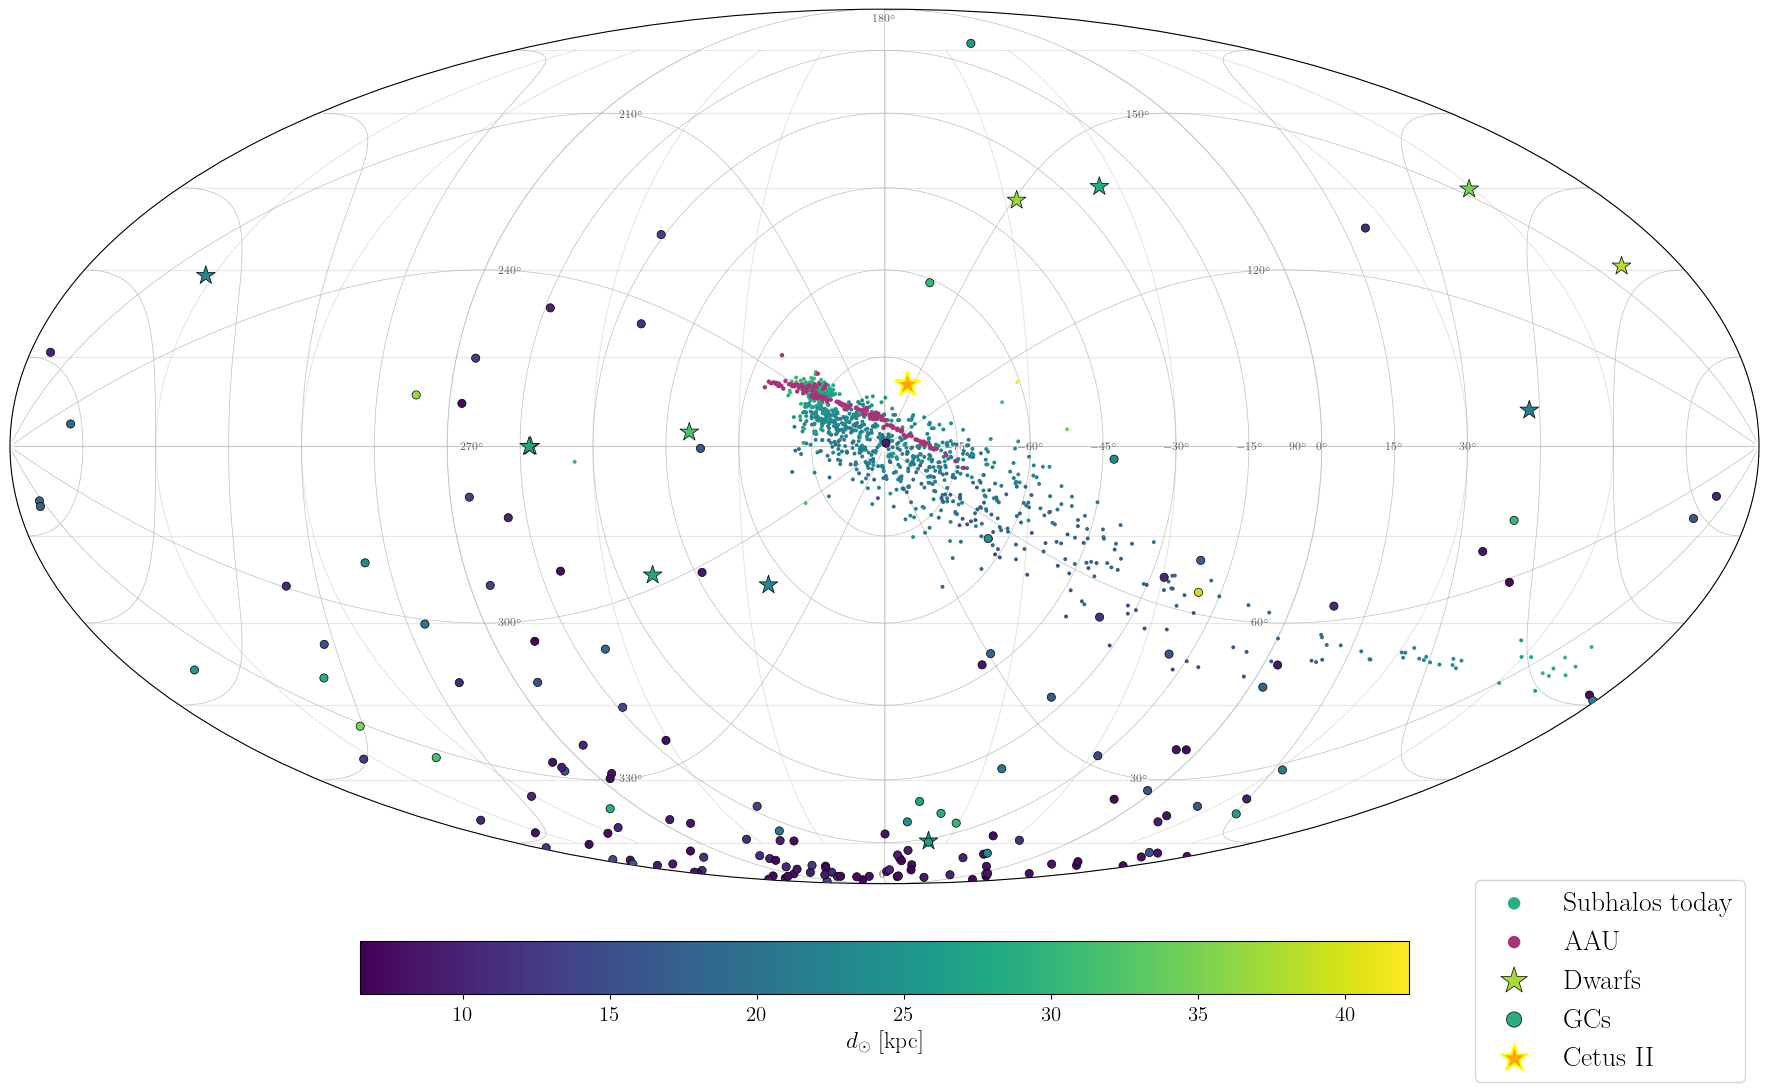

In [56]:
from astropy.coordinates import SkyOffsetFrame

# impact-time positions (from the round-trip check)
c_imp = SkyCoord(
    x=w_back[:, 0]*u.kpc, y=w_back[:, 1]*u.kpc, z=w_back[:, 2]*u.kpc,
    frame=Galactocentric(),
).transform_to(Galactic())

# map centered on the south Galactic pole, spun 180° about the center
center = SkyCoord(l=0*u.deg, b=-90*u.deg, frame=Galactic())
off_frame = SkyOffsetFrame(origin=center, rotation=180*u.deg)

def to_offset(coord):
    o = coord.transform_to(off_frame)
    return o.lon.wrap_at(180*u.deg).rad, o.lat.rad

x_now, y_now = to_offset(c)
x_imp, y_imp = to_offset(c_imp)
x_aau, y_aau = to_offset(c_aau_gal)

d_imp = c_imp.distance.kpc


fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(projection="mollweide")

#plotting the trajectories from impact to today
#for i in range(len(x_now)):
    #if abs(x_now[i] - x_imp[i]) < np.pi:
        #ax.plot([-x_imp[i], -x_now[i]], [y_imp[i], y_now[i]],
                #color="0.6", lw=0.3, alpha=0.3, zorder=1)

#ax.scatter(-x_imp, y_imp, c=d_imp, cmap="viridis", norm=norm,
           #s=10, marker="^", edgecolors="none",

#Only plotting the gcs and dwarfs within some distance range
d_lo = aau.distance_kpc.min() - 10
d_hi = aau.distance_kpc.max() + 10
norm = plt.Normalize(vmin=min(d_lo, d_imp.min()), vmax=max(d_hi, d_imp.max()))

# in_slice = (d >= d_lo) & (d <= d_hi)

# print(f"{in_slice.sum()} / {len(d)} subhalos in [{d_lo:.1f}, {d_hi:.1f}] kpc")

sc = ax.scatter(-x_now, y_now, c=d, cmap="viridis", norm=norm,
                s=8, marker="o", edgecolors="none",
                label="Subhalos today", zorder=3, rasterized=True)

ax.scatter(-x_aau, y_aau, s=10, color=color_aau, edgecolors="none",
           label="AAU", zorder=4, rasterized=True)

# mark the south Galactic pole at the map center
#ax.plot(0, 0, marker="+", color="k", ms=10, mew=1.5, zorder=5)

ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(True, alpha=0.3)

leg = ax.legend(loc="lower right", fontsize=10, markerscale=3)
for h in leg.legend_handles[:2]:
    h.set_color("0.4")

ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(True, alpha=0.3)
fig.colorbar(sc, ax=ax, orientation="horizontal", shrink=0.6, pad=0.05,
             label=r"$d_\odot$ [kpc]")
ax.legend(loc="lower right", fontsize=10, markerscale=3)


# Galactic graticule
grid_kw = dict(color="0.75", lw=0.5, zorder=0)
for bb in range(-75, 90, 15):
    plot_sky_curve(ax, np.linspace(0, 360, 361), np.full(361, bb), **grid_kw)
for ll in range(0, 360, 30):
    plot_sky_curve(ax, np.full(179, ll), np.linspace(-89, 89, 179), **grid_kw)

# graticule labels: b along one meridian, l just inside the Galactic plane
lab_lon = 90
lab_kw = dict(fontsize=8, color="0.35", ha="center", va="center", zorder=6)
for bb in (-75, -60, -45, -30, -15, 0, 15, 30):
    sky_text(ax, lab_lon, bb, rf"${bb}^\circ$", **lab_kw)
for ll in range(0, 360, 30):
    sky_text(ax, ll, -5, rf"${ll}^\circ$", **lab_kw)


#plotting an ellipse instead of the indiviudal subhalos
def sky_ellipse(l0, b0, a, b_ax, pa, n=400):
    """
    Ellipse on the sky, returned as a Galactic SkyCoord.

    l0, b0 : center in Galactic coordinates [deg]
    a, b_ax: semi-major and semi-minor axes [deg]
    pa     : position angle of the major axis [deg], measured from
             north (+b) toward increasing l
    """
    center = SkyCoord(l=l0*u.deg, b=b0*u.deg, frame=Galactic())
    phi = np.linspace(0, 2*np.pi, n)                 # direction from center
    dphi = phi - np.radians(pa)                      # angle from major axis
    r = a * b_ax / np.sqrt((b_ax*np.cos(dphi))**2 + (a*np.sin(dphi))**2)
    return center.directional_offset_by(phi*u.rad, r*u.deg)

def plot_sky_coord_curve(ax, coord, **kw):
    """Plot a SkyCoord curve in the rotated frame, splitting at the ±180° seam."""
    x, y = to_offset(coord)
    x = -x
    breaks = np.where(np.abs(np.diff(x)) > np.pi)[0] + 1
    for i, (xs, ys) in enumerate(zip(np.split(x, breaks), np.split(y, breaks))):
        ax.plot(xs, ys, **(kw if i == 0 else {k: v for k, v in kw.items() if k != "label"}))
c_dw_gal = c_dwarf.transform_to(Galactic())
c_gc_gal = c_gc.transform_to(Galactic())

x_dw, y_dw = to_offset(c_dw_gal)
x_gc, y_gc = to_offset(c_gc_gal)

d_dw = c_dw_gal.distance.kpc
d_gc = c_gc_gal.distance.kpc

d_dw_mask = (d_dw >= d_lo) & (d_dw <= d_hi)
d_gc_mask = (d_gc >= d_lo) & (d_gc <= d_hi)

# Cetus II: pulled out of the regular dwarf scatter and highlighted
is_cet = (dwarfs["name"] == "Cetus II").to_numpy()
dw_plot = d_dw_mask & ~is_cet

ax.scatter(-x_dw[dw_plot], y_dw[dw_plot], c=d_dw[dw_plot], cmap="viridis", norm=norm,
           marker="*", s=200, edgecolors="k", linewidths=0.5,
           zorder=6, label="Dwarfs")
ax.scatter(-x_gc[d_gc_mask], y_gc[d_gc_mask], c=d_gc[d_gc_mask], cmap="viridis", norm=norm,
           marker="o", s=35, edgecolors="k", linewidths=0.5,
           zorder=6, label="GCs")
ax.scatter(-x_dw[is_cet], y_dw[is_cet], marker="*", s=350,
           facecolor="orange", edgecolors="yellow", linewidths=1.5,
           zorder=7, label="Cetus II")

leg = ax.legend(loc="upper right", bbox_to_anchor=(1.0, 0.02),
                fontsize=20, markerscale=1)

sizes = {"Subhalos today": 80, "AAU": 80, "Dwarfs": 400, "GCs": 120, "Cetus II": 400}
for h in leg.legend_handles:
    lab = h.get_label()
    h.set_sizes([sizes[lab]])
    if lab in ("Subhalos today", "Dwarfs", "GCs"):
        h.set_facecolor("0.6")

plt.savefig("/global/homes/e/emarin4/scratch/sbi_stream_personal/inference/subhalo_positions_mollweide2.pdf",
            bbox_inches="tight", dpi=300)

In [56]:
print(aau.distance_kpc.min() - 5, aau.distance_kpc.max() + 5)

11.475918803241349 34.92656023918217


In [64]:
import h5py

save_path = "aau_top1000_map_streams.h5"
n_streams = len(top1000_feats)
n_per_stream = np.array([len(f) for f in top1000_feats], dtype=np.int64)

# build pointer array: ptr[i] to ptr[i+1] gives the slice for stream i
ptr = np.zeros(n_streams + 1, dtype=np.int64)
ptr[1:] = np.cumsum(n_per_stream)

# concatenate all particle arrays
all_phi1 = np.concatenate([f[:, 0] for f in top1000_feats])
all_phi2 = np.concatenate([f[:, 1] for f in top1000_feats])
all_vr   = np.concatenate([f[:, 2] for f in top1000_feats])
all_pm1  = np.concatenate([f[:, 3] for f in top1000_feats])
all_pm2  = np.concatenate([f[:, 4] for f in top1000_feats])
all_dist = np.concatenate([f[:, 5] for f in top1000_feats])

# per-stream scalar params from top1000_idx
# columns: [log_mass, log_scale_radius, phi1_impact_today, time_impact,
#            impact_parameter, v_rel_para, v_rel_perp, angle_pos_at_impact, delta_angle]
top1000_params = np.array([
    all_posteriors_flat[idx].flatten() for idx in top1000_idx
])

with h5py.File(save_path, 'w') as f:
    # ── per-stream scalars ────────────────────────────────────────────────────
    f.create_dataset('mass',              data=10**top1000_params[:, 0],  dtype='f8')
    f.create_dataset('scale_radius',      data=10**top1000_params[:, 1],  dtype='f8')
    f.create_dataset('phi1_impact_today', data=top1000_params[:, 2],      dtype='f8')
    f.create_dataset('impact_time',       data=top1000_params[:, 3],      dtype='f8')
    f.create_dataset('impact_param',      data=top1000_params[:, 4],      dtype='f8')
    f.create_dataset('v_para',            data=top1000_params[:, 5],      dtype='f8')
    f.create_dataset('v_perp',            data=top1000_params[:, 6],      dtype='f8')
    f.create_dataset('angle_pos',         data=top1000_params[:, 7],      dtype='f8')
    f.create_dataset('angle_vel',         data=top1000_params[:, 7] + top1000_params[:, 8], dtype='f8')

    # ── pointer and count arrays ──────────────────────────────────────────────
    f.create_dataset('num_particles',     data=n_per_stream,               dtype='i8')
    f.create_dataset('ptr',               data=ptr,                        dtype='i8')

    # ── concatenated particle arrays ──────────────────────────────────────────
    f.create_dataset('phi1',              data=all_phi1,                   dtype='f8')
    f.create_dataset('phi2',              data=all_phi2,                   dtype='f8')
    f.create_dataset('vr',               data=all_vr,                     dtype='f8')
    f.create_dataset('pm1',              data=all_pm1,                    dtype='f8')
    f.create_dataset('pm2',              data=all_pm2,                    dtype='f8')
    f.create_dataset('dist',             data=all_dist,                   dtype='f8')

print(f"Saved {n_streams} streams to {save_path}")
print(f"Total particles: {ptr[-1]:,}")

# ── quick sanity check ────────────────────────────────────────────────────────
with h5py.File(save_path, 'r') as f:
    print("\nDataset shapes:")
    for key in f.keys():
        print(f"  {key}: {f[key].shape}")

    # verify ptr: stream 0 particles
    p0, p1 = f['ptr'][0], f['ptr'][1]
    print(f"\nStream 0: {p1-p0} particles, phi1 range [{f['phi1'][p0:p1].min():.2f}, {f['phi1'][p0:p1].max():.2f}]")

Saved 1000 streams to aau_top1000_map_streams.h5
Total particles: 200,000

Dataset shapes:
  angle_pos: (1000,)
  angle_vel: (1000,)
  dist: (200000,)
  impact_param: (1000,)
  impact_time: (1000,)
  mass: (1000,)
  num_particles: (1000,)
  phi1: (200000,)
  phi1_impact_today: (1000,)
  phi2: (200000,)
  pm1: (200000,)
  pm2: (200000,)
  ptr: (1001,)
  scale_radius: (1000,)
  v_para: (1000,)
  v_perp: (1000,)
  vr: (200000,)

Stream 0: 200 particles, phi1 range [-32.92, 150.28]


In [85]:
# ── save all top-1000 PS stream features from phi1 = -25 to 25 ───────────────
save_phi1_min, save_phi1_max = -25, 25

streams_to_save = []

for feats_i in top1000_feats:
    phi1_i = feats_i[:, 0]
    mask_i = (phi1_i >= save_phi1_min) & (phi1_i < save_phi1_max)
    streams_to_save.append(feats_i[mask_i])

# save as a list of arrays — each entry is one stream's particles
# columns: [phi1, phi2, vr, pm1, pm2, dist]
np.save(
    "aau_top1000_streams_raw.npy",
    np.array(streams_to_save, dtype=object),
    allow_pickle=True,
)
print(f"Saved {len(streams_to_save)} streams")
print(f"Example: stream 0 has shape {streams_to_save[0].shape}")
print(f"Columns: ['phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist']")

Saved 1000 streams
Example: stream 0 has shape (190, 6)
Columns: ['phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist']


Saved aau_top100_envelopes.npz


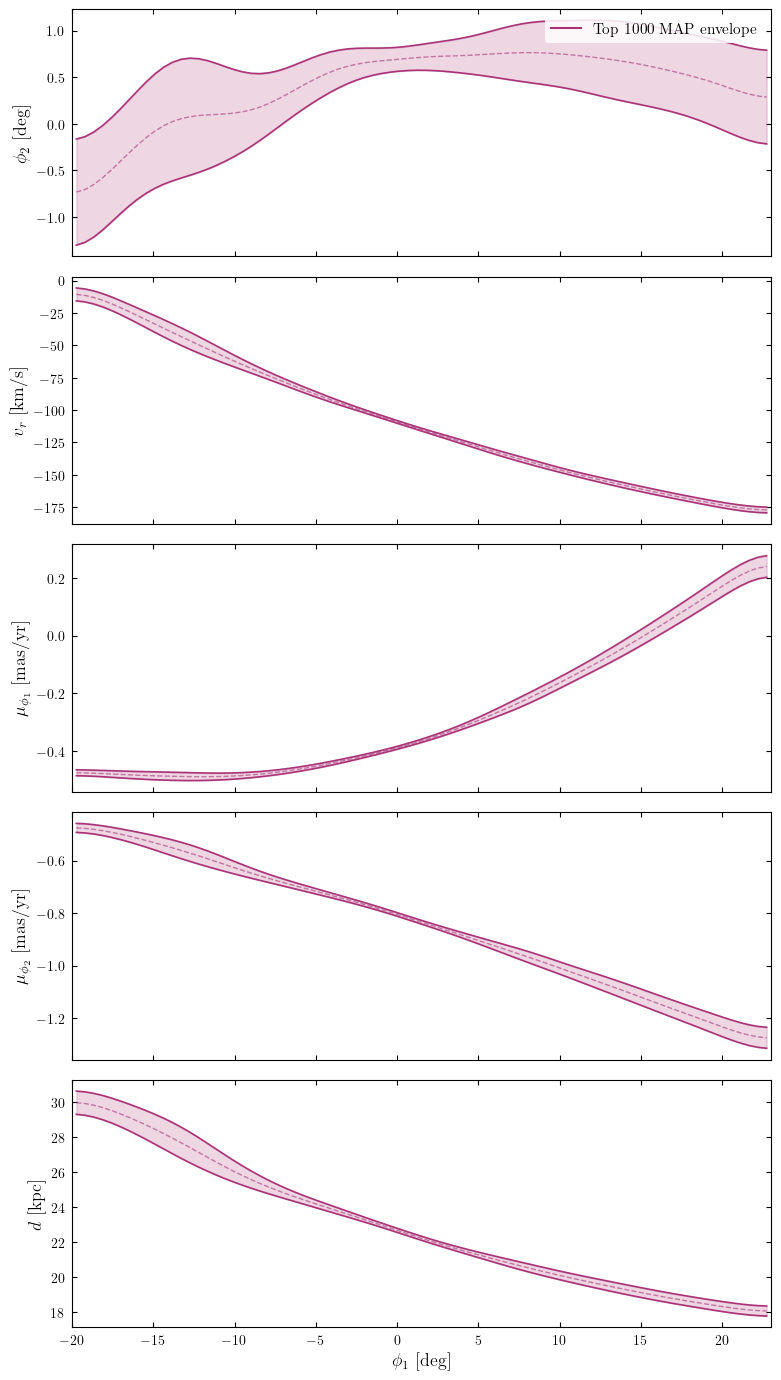

In [86]:
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter1d

plot_pretty(dpi=175, fontsize=13, labelsize=11, figsize=(8, 8), tex=True)
plt.close('all')

features  = ['phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist']
ylabels   = [
    r'$\phi_2$ [deg]',
    r'$v_r$ [km/s]',
    r'$\mu_{\phi_1}$ [mas/yr]',
    r'$\mu_{\phi_2}$ [mas/yr]',
    r'$d$ [kpc]',
]
feat_cols = [1, 2, 3, 4, 5]

# ── stack all top-1000 streams ────────────────────────────────────────────────
all_phi1 = []
all_feats = [[] for _ in feat_cols]

env_phi1_min, env_phi1_max = -20, 23

for feats_i in top1000_feats:
    phi1_i = feats_i[:, 0]
    mask_i = (phi1_i >= env_phi1_min) & (phi1_i < env_phi1_max)
    all_phi1.append(feats_i[mask_i, 0])
    for k, col in enumerate(feat_cols):
        all_feats[k].append(feats_i[mask_i, col])

all_phi1  = np.concatenate(all_phi1)
all_feats = [np.concatenate(f) for f in all_feats]

# ── envelope in phi1 bins ─────────────────────────────────────────────────────
n_bins  = 80
sigma   = 3
edges   = np.linspace(env_phi1_min, env_phi1_max, n_bins + 1)
centers = 0.5 * (edges[:-1] + edges[1:])

fig, axes = plt.subplots(5, 1, figsize=(8, 14), sharex=True)
fig.subplots_adjust(hspace=0.08, left=0.14, right=0.97, top=0.97, bottom=0.06)

envelope_data = {}
for ax, feat_vals, ylabel, col in zip(axes, all_feats, ylabels, feat_cols):
    lo_arr, hi_arr = [], []
    for l, r in zip(edges[:-1], edges[1:]):
        mask = (all_phi1 >= l) & (all_phi1 < r)
        if mask.sum() >= 5:
            lo_arr.append(np.percentile(feat_vals[mask], 16))
            hi_arr.append(np.percentile(feat_vals[mask], 84))
        else:
            lo_arr.append(np.nan)
            hi_arr.append(np.nan)

    lo_arr = np.array(lo_arr)
    hi_arr = np.array(hi_arr)
    valid      = ~(np.isnan(lo_arr) | np.isnan(hi_arr))
    cx         = centers[valid]
    lo_smooth  = gaussian_filter1d(lo_arr[valid], sigma=sigma)
    hi_smooth  = gaussian_filter1d(hi_arr[valid], sigma=sigma)
    mid_smooth = 0.5 * (lo_smooth + hi_smooth)

    # ── save ──────────────────────────────────────────────────────────────────
    fname = features[col]
    envelope_data[f'{fname}_cx']  = cx
    envelope_data[f'{fname}_lo']  = lo_smooth
    envelope_data[f'{fname}_hi']  = hi_smooth
    envelope_data[f'{fname}_mid'] = mid_smooth

    # ── plot ──────────────────────────────────────────────────────────────────
    ax.fill_between(cx, lo_smooth, hi_smooth,
                    color=color_aau, alpha=0.20, zorder=2)
    ax.plot(cx, hi_smooth,  color=color_aau, linewidth=1.2, zorder=3)
    ax.plot(cx, lo_smooth,  color=color_aau, linewidth=1.2, zorder=3)
    ax.plot(cx, mid_smooth, color=color_aau, linewidth=1.0,
            linestyle='--', alpha=0.6, zorder=3)

    ax.set_ylabel(ylabel, fontsize=13)
    ax.yaxis.set_minor_locator(plt.AutoLocator())
    ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=10)
    ax.set_xlim(env_phi1_min, env_phi1_max)

axes[0].legend(
    handles=[Line2D([0], [0], color=color_aau, linewidth=1.5,
                    label='Top 1000 MAP envelope')],
    loc='upper right', framealpha=0.85, edgecolor='none', fontsize=11,
)
axes[-1].set_xlabel(r'$\phi_1$ [deg]', fontsize=13)

np.savez("aau_top100_envelopes.npz", **envelope_data)
print("Saved aau_top100_envelopes.npz")

plt.savefig("aau_top1000_envelopes.png", dpi=300, bbox_inches="tight")
plt.show()

Saved aau_top1000_envelopes_hdi.npz  (HDI 68%)


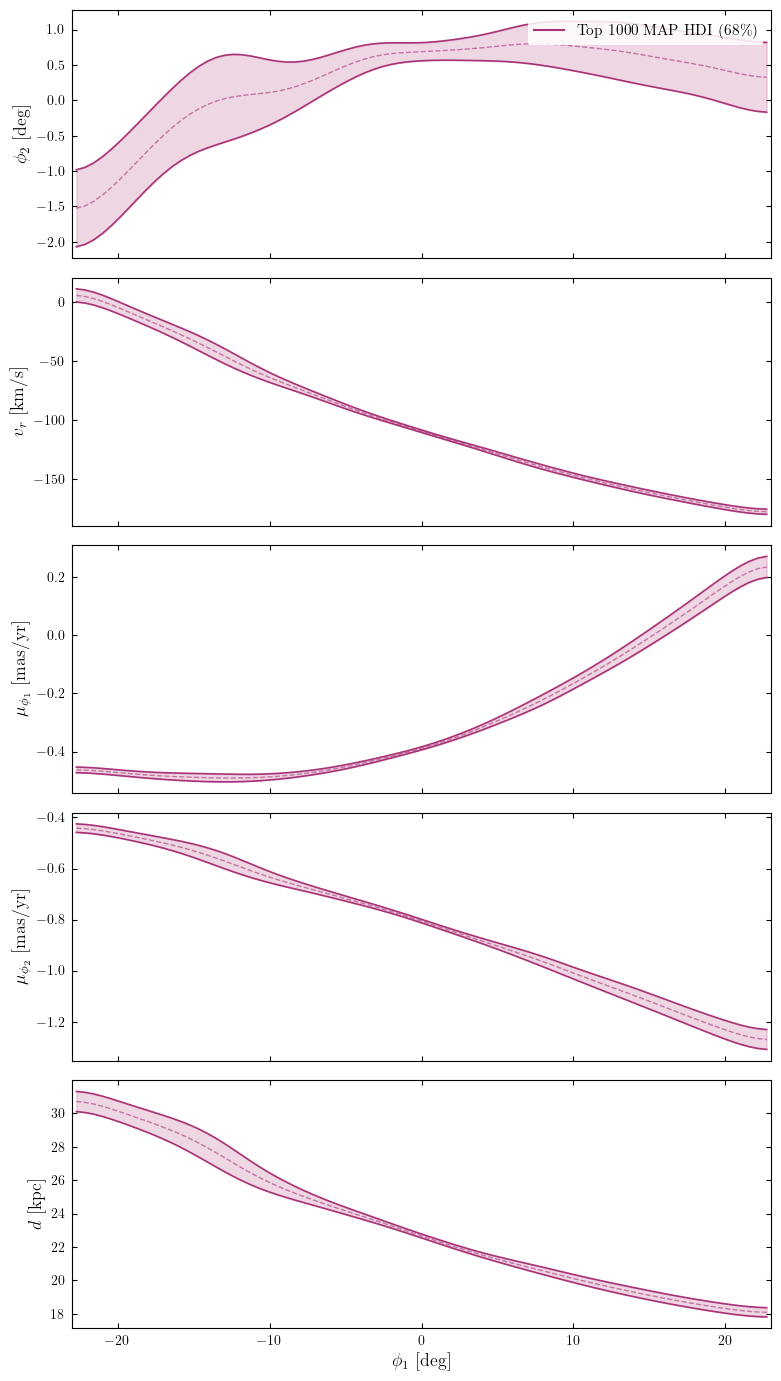

In [87]:
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter1d

plot_pretty(dpi=175, fontsize=13, labelsize=11, figsize=(8, 8), tex=True)
plt.close('all')

def hdi(values, credible_mass=0.68):
    """Shortest interval containing `credible_mass` fraction of values."""
    values = np.sort(values)
    n = len(values)
    interval_width = int(np.floor(credible_mass * n))
    widths  = values[interval_width:] - values[:n - interval_width]
    min_idx = np.argmin(widths)
    return values[min_idx], values[min_idx + interval_width]

features  = ['phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist']
ylabels   = [
    r'$\phi_2$ [deg]',
    r'$v_r$ [km/s]',
    r'$\mu_{\phi_1}$ [mas/yr]',
    r'$\mu_{\phi_2}$ [mas/yr]',
    r'$d$ [kpc]',
]
feat_cols = [1, 2, 3, 4, 5]

# ── stack all top-1000 streams ────────────────────────────────────────────────
all_phi1  = []
all_feats = [[] for _ in feat_cols]

env_phi1_min, env_phi1_max = -23, 23

for feats_i in top1000_feats:
    phi1_i = feats_i[:, 0]
    mask_i = (phi1_i >= env_phi1_min) & (phi1_i < env_phi1_max)
    all_phi1.append(feats_i[mask_i, 0])
    for k, col in enumerate(feat_cols):
        all_feats[k].append(feats_i[mask_i, col])

all_phi1  = np.concatenate(all_phi1)
all_feats = [np.concatenate(f) for f in all_feats]

# ── envelope in phi1 bins ─────────────────────────────────────────────────────
n_bins        = 80
sigma         = 3
credible_mass = 0.68   # ← adjust this to widen/narrow the HDI band
edges         = np.linspace(env_phi1_min, env_phi1_max, n_bins + 1)
centers       = 0.5 * (edges[:-1] + edges[1:])

fig, axes = plt.subplots(5, 1, figsize=(8, 14), sharex=True)
fig.subplots_adjust(hspace=0.08, left=0.14, right=0.97, top=0.97, bottom=0.06)

envelope_data_hdi = {}
for ax, feat_vals, ylabel, col in zip(axes, all_feats, ylabels, feat_cols):
    lo_arr, hi_arr = [], []

    for l, r in zip(edges[:-1], edges[1:]):
        mask = (all_phi1 >= l) & (all_phi1 < r)
        if mask.sum() >= 5:
            lo, hi = hdi(feat_vals[mask], credible_mass=credible_mass)
            lo_arr.append(lo)
            hi_arr.append(hi)
        else:
            lo_arr.append(np.nan)
            hi_arr.append(np.nan)

    lo_arr = np.array(lo_arr)
    hi_arr = np.array(hi_arr)
    valid      = ~(np.isnan(lo_arr) | np.isnan(hi_arr))
    cx         = centers[valid]
    lo_smooth  = gaussian_filter1d(lo_arr[valid], sigma=sigma)
    hi_smooth  = gaussian_filter1d(hi_arr[valid], sigma=sigma)
    mid_smooth = 0.5 * (lo_smooth + hi_smooth)

    # ── save ──────────────────────────────────────────────────────────────────
    fname = features[col]
    envelope_data_hdi[f'{fname}_cx']  = cx
    envelope_data_hdi[f'{fname}_lo']  = lo_smooth
    envelope_data_hdi[f'{fname}_hi']  = hi_smooth
    envelope_data_hdi[f'{fname}_mid'] = mid_smooth

    # ── plot ──────────────────────────────────────────────────────────────────
    ax.fill_between(cx, lo_smooth, hi_smooth,
                    color=color_aau, alpha=0.20, zorder=2)
    ax.plot(cx, hi_smooth,  color=color_aau, linewidth=1.2, zorder=3)
    ax.plot(cx, lo_smooth,  color=color_aau, linewidth=1.2, zorder=3)
    ax.plot(cx, mid_smooth, color=color_aau, linewidth=1.0,
            linestyle='--', alpha=0.6, zorder=3)

    ax.set_ylabel(ylabel, fontsize=13)
    ax.yaxis.set_minor_locator(plt.AutoLocator())
    ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=10)
    ax.set_xlim(env_phi1_min, env_phi1_max)

axes[0].legend(
    handles=[Line2D([0], [0], color=color_aau, linewidth=1.5,
                    label=f'Top 1000 MAP HDI ({int(credible_mass*100)}\\%)')],
    loc='upper right', framealpha=0.85, edgecolor='none', fontsize=11,
)
axes[-1].set_xlabel(r'$\phi_1$ [deg]', fontsize=13)

np.savez("aau_top1000_envelopes_hdi.npz",
         credible_mass=credible_mass,
         phi1_min=env_phi1_min, phi1_max=env_phi1_max,
         **envelope_data_hdi)
print(f"Saved aau_top1000_envelopes_hdi.npz  (HDI {int(credible_mass*100)}%)")

plt.savefig("aau_top1000_envelopes_hdi.png", dpi=300, bbox_inches="tight")
plt.show()

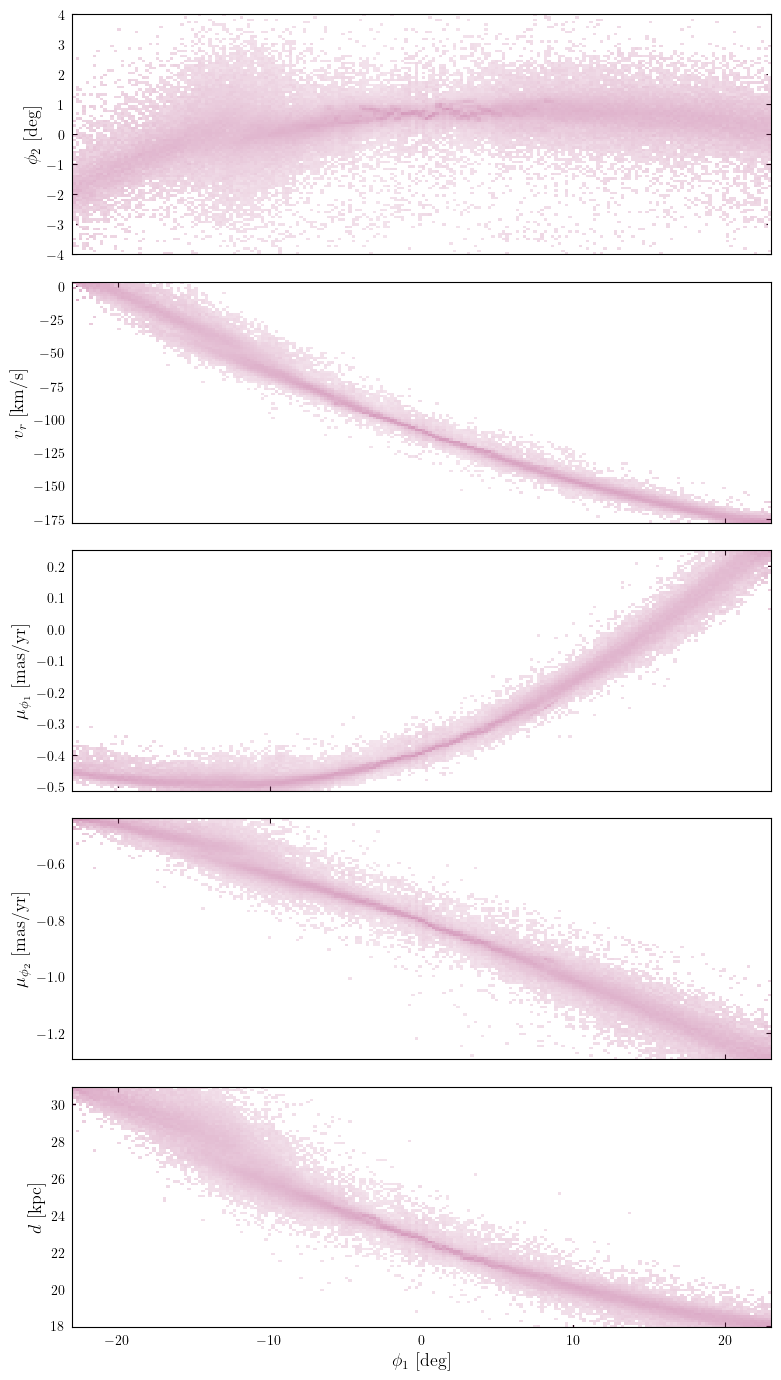

In [112]:
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

plot_pretty(dpi=175, fontsize=13, labelsize=11, figsize=(8, 8), tex=True)
plt.close('all')

features  = ['phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist']
ylabels   = [
    r'$\phi_2$ [deg]',
    r'$v_r$ [km/s]',
    r'$\mu_{\phi_1}$ [mas/yr]',
    r'$\mu_{\phi_2}$ [mas/yr]',
    r'$d$ [kpc]',
]
feat_cols = [1, 2, 3, 4, 5]

# ── custom colormap: white → color_aau ───────────────────────────────────────
cmap_aau = LinearSegmentedColormap.from_list(
    'white_to_aau',
    [(0.00, 'white',),
     (0.15, (*mcolors.to_rgb(color_aau), 0.1)),
     (1.00, (*mcolors.to_rgb(color_aau), 0.5))],
)

# ── stack all top-1000 streams ────────────────────────────────────────────────
all_phi1  = []
all_feats = [[] for _ in feat_cols]

env_phi1_min, env_phi1_max = -23, 23

for feats_i in top1000_feats:
    phi1_i = feats_i[:, 0]
    mask_i = (phi1_i >= env_phi1_min) & (phi1_i < env_phi1_max)
    all_phi1.append(feats_i[mask_i, 0])
    for k, col in enumerate(feat_cols):
        all_feats[k].append(feats_i[mask_i, col])

all_phi1  = np.concatenate(all_phi1)
all_feats = [np.concatenate(f) for f in all_feats]

# ── phi1-normalised 2D histogram ──────────────────────────────────────────────
def phi1_normalised_hist2d(phi1, feat, bins_phi1=200, bins_feat=150,
                            phi1_range=None, feat_range=None):
    H, xedges, yedges = np.histogram2d(
        phi1, feat,
        bins=[bins_phi1, bins_feat],
        range=[phi1_range, feat_range],
    )
    col_sums = H.sum(axis=1, keepdims=True)
    col_sums[col_sums == 0] = 1
    H_norm = H / col_sums
    return H_norm.T, xedges, yedges

# ── tune these ────────────────────────────────────────────────────────────────
gamma     = 0.20
bins_phi1 = 200
bins_feat = 100 #100
clip_lo   = 1
clip_hi   = 99

# ── per-feature y ranges: None = use clip percentiles, tuple = manual ─────────
feat_ranges = [
    (-4.0, 4.0),   # phi2  ← manual, avoids hard clip edges
    None,           # vr
    None,           # pm1
    None,           # pm2
    None,           # dist
]

fig, axes = plt.subplots(5, 1, figsize=(8, 14), sharex=True)
fig.subplots_adjust(hspace=0.08, left=0.14, right=0.97, top=0.97, bottom=0.06)

for i, (ax, feat_vals, ylabel) in enumerate(zip(axes, all_feats, ylabels)):

    if feat_ranges[i] is not None:
        feat_lo, feat_hi = feat_ranges[i]
    else:
        feat_lo = np.percentile(feat_vals, clip_lo)
        feat_hi = np.percentile(feat_vals, clip_hi)

    feat_mask = (feat_vals >= feat_lo) & (feat_vals <= feat_hi)

    H_norm, xedges, yedges = phi1_normalised_hist2d(
        all_phi1[feat_mask], feat_vals[feat_mask],
        bins_phi1=bins_phi1, bins_feat=bins_feat,
        phi1_range=[env_phi1_min, env_phi1_max],
        feat_range=[feat_lo, feat_hi],
    )

    #H_norm = gaussian_filter(H_norm, sigma=1.0) #smoothing histogram

    ax.pcolormesh(
        xedges, yedges, H_norm,
        cmap=cmap_aau,
        norm=PowerNorm(gamma=gamma, vmin=0, vmax=H_norm.max()),
        zorder=2,
        rasterized=True,
    )

    ax.set_ylabel(ylabel, fontsize=13)
    ax.yaxis.set_minor_locator(plt.AutoLocator())
    ax.tick_params(which='both', direction='in', top=True, right=True, labelsize=10)
    ax.set_xlim(env_phi1_min, env_phi1_max)

# axes[0].legend(
#     handles=[Line2D([0], [0], color=color_aau, linewidth=4, alpha=0.6,
#                     label='Top 1000 MAP')],
#     loc='upper right', framealpha=0.85, edgecolor='none', fontsize=11,
# )
axes[-1].set_xlabel(r'$\phi_1$ [deg]', fontsize=13)

plt.savefig("aau_top1000_hist2d_normed.png", dpi=300, bbox_inches="tight")
plt.show()

In [113]:
import pickle

# ── recompute and save all heatmap arrays ─────────────────────────────────────
heatmap_data = {}

for i, (feat_vals, ylabel) in enumerate(zip(all_feats, ylabels)):
    fname = features[feat_cols[i]]   # 'phi2', 'vr', etc.

    if feat_ranges[i] is not None:
        feat_lo, feat_hi = feat_ranges[i]
    else:
        feat_lo = np.percentile(feat_vals, clip_lo)
        feat_hi = np.percentile(feat_vals, clip_hi)

    feat_mask = (feat_vals >= feat_lo) & (feat_vals <= feat_hi)

    H_norm, xedges, yedges = phi1_normalised_hist2d(
        all_phi1[feat_mask], feat_vals[feat_mask],
        bins_phi1=bins_phi1, bins_feat=bins_feat,
        phi1_range=[env_phi1_min, env_phi1_max],
        feat_range=[feat_lo, feat_hi],
    )

    heatmap_data[fname] = {
        'H_norm'  : H_norm,
        'xedges'  : xedges,
        'yedges'  : yedges,
        'feat_lo' : feat_lo,
        'feat_hi' : feat_hi,
        'ylabel'  : ylabel,
    }
    print(f"  {fname}: H_norm {H_norm.shape}, y=[{feat_lo:.3f}, {feat_hi:.3f}]")

# save gamma and phi1 range too so you can reproduce the norm later
heatmap_data['_meta'] = {
    'gamma'        : gamma,
    'env_phi1_min' : env_phi1_min,
    'env_phi1_max' : env_phi1_max,
    'bins_phi1'    : bins_phi1,
    'bins_feat'    : bins_feat,
    'clip_lo'      : clip_lo,
    'clip_hi'      : clip_hi,
    'feat_ranges'  : feat_ranges,
}

with open("aau_top1000_heatmaps.pkl", "wb") as f:
    pickle.dump(heatmap_data, f)

print("Saved aau_top1000_heatmaps.pkl")

  phi2: H_norm (100, 200), y=[-4.000, 4.000]
  vr: H_norm (100, 200), y=[-177.897, 3.141]
  pm1: H_norm (100, 200), y=[-0.513, 0.250]
  pm2: H_norm (100, 200), y=[-1.292, -0.441]
  dist: H_norm (100, 200), y=[17.911, 30.965]
Saved aau_top1000_heatmaps.pkl


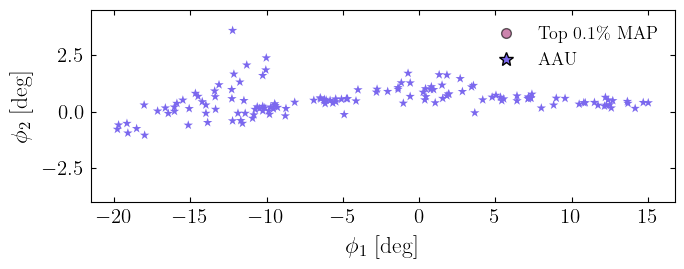

In [89]:
plot_pretty(dpi=175, fontsize=17, labelsize=15, figsize=(8, 4), tex=True)

from matplotlib.lines import Line2D

alphas = np.linspace(0.05, 0.35, 100)[::-1]

fig, ax = plt.subplots(1, 1, figsize=(7, 3))

# Top 100 MAP streams
for rank, feats_i in enumerate(top100_feats):
    phi1_i      = feats_i[:, 0]
    mask_i      = (phi1_i >= phi1_min) & (phi1_i < phi1_max)
    feats_cut_i = feats_i[mask_i]
    ax.scatter(
        feats_cut_i[:, 0], feats_cut_i[:, 1],
        s=2, c=color_aau, alpha=alphas[rank],
        edgecolors='none', rasterized=True,
    )

# AAU data overlay
# ax.scatter(
#     aau_cut['phi1'].values, aau_cut['phi2'].values,
#     s=50, c='mediumslateblue', alpha=1.0, zorder=6,
#     marker='*', edgecolors='none', rasterized=True,
# )

ax.scatter(stream_used_cut[:, 0], stream_used_cut[:, 1],
               s=50, c='mediumslateblue', alpha=1.0, zorder=6, marker='*', edgecolors='none', rasterized=True)

ax.set_ylabel(r'$\phi_2$ [deg]', labelpad=6)
ax.set_xlabel(r'$\phi_1$ [deg]', labelpad=6)
ax.yaxis.set_minor_locator(plt.AutoLocator())
ax.tick_params(which='both', direction='in', top=True, right=True)

legend_elements = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=color_aau,
           markersize=7, alpha=0.6, label=r'Top 0.1\% MAP'),
    Line2D([0], [0], marker='*', color='none', markerfacecolor='mediumslateblue',
           markersize=10, label='AAU'),
]

ax.legend(handles=legend_elements, loc='upper right',
          framealpha=0.85, edgecolor='none', fontsize=13)
plt.ylim(-4, 4.5)
plt.tight_layout()
plt.savefig("aau_top100_map_streams_phi1_phi2_nomock.png", dpi = 300, bbox_inches="tight")
plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

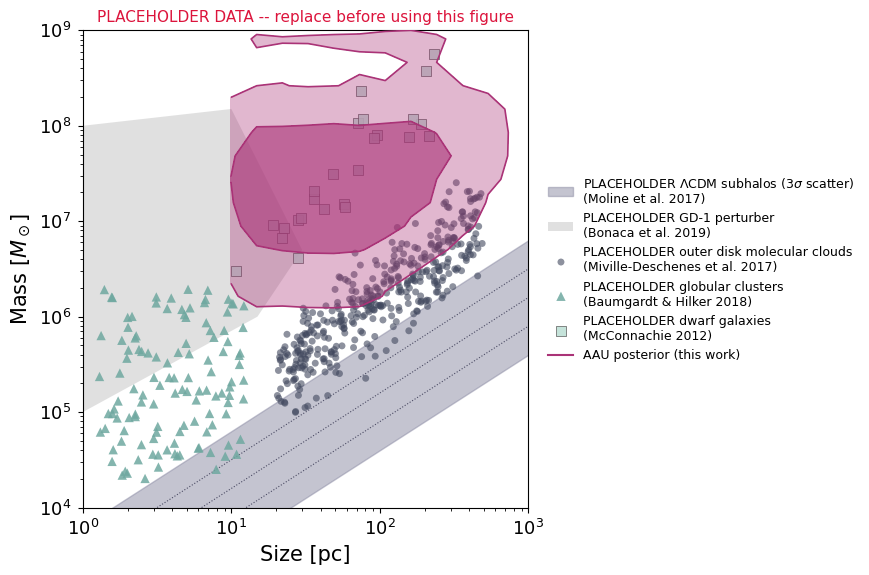

In [90]:
# ============================================================================
# TEMPLATE ONLY -- every point/region below is PLACEHOLDER data, not real
# catalog values. This just sets up the axes/style/legend so you can swap in
# the actual digitized data from each paper:
#   - GD-1 perturber region:       Bonaca et al. 2019
#   - Outer disk molecular clouds: Miville-Deschenes et al. 2017
#   - Globular clusters:           Baumgardt & Hilker 2018
#   - Dwarf galaxies:              McConnachie 2012
#   - LambdaCDM subhalos (3-sigma):Moline et al. 2017
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Polygon

placeholder_rng = np.random.default_rng(42)

# scoped to this figure only -- avoids depending on the notebook's global
# text.usetex=True (set earlier by plot_pretty(..., tex=True)), whose real
# LaTeX subprocess is failing on this system ("No pages of output"). None of
# this figure's text needs real LaTeX -- mathtext handles \Lambda/\sigma/\odot.
with plt.rc_context({'text.usetex': False}):
    fig, ax = plt.subplots(figsize=(9, 6))

    # --- LambdaCDM subhalo band (PLACEHOLDER diagonal band + dotted guide lines) ---
    size_grid = np.logspace(0, 3, 200)
    band_center = 10**3.2 * size_grid**1.0          # placeholder power-law scaling
    band_lo, band_hi = band_center / 10**0.6, band_center * 10**0.6
    ax.fill_between(size_grid, band_lo, band_hi, color='#8a8aa3', alpha=0.5, zorder=1,
                     label='PLACEHOLDER $\\Lambda$CDM subhalos (3$\\sigma$ scatter)\n(Moline et al. 2017)')
    for shift in (-0.3, 0.0, 0.3):
        ax.plot(size_grid, band_center * 10**shift, ':', color='#4a4a63', lw=0.8, zorder=1)

    # --- GD-1 perturber region (PLACEHOLDER polygon) ---
    gd1_poly = np.array([[1, 1e5], [1, 1e8], [10, 1.5e8], [30, 5e6], [15, 1e6], [1, 1e5]])
    ax.add_patch(Polygon(gd1_poly, closed=True, facecolor='#d9d9d9', edgecolor='none',
                          alpha=0.8, zorder=2, label='PLACEHOLDER GD-1 perturber\n(Bonaca et al. 2019)'))

    # --- Outer disk molecular clouds (PLACEHOLDER scatter) ---
    n = 400
    mc_size = 10**placeholder_rng.uniform(1.3, 2.7, n)
    mc_mass = 10**(4.0 + 1.1 * np.log10(mc_size) + placeholder_rng.normal(0, 0.25, n))
    ax.scatter(mc_size, mc_mass, s=25, color='#41485e', alpha=0.6, edgecolor='none', zorder=3,
               label='PLACEHOLDER outer disk molecular clouds\n(Miville-Deschenes et al. 2017)')

    # --- Globular clusters (PLACEHOLDER scatter) ---
    n = 120
    gc_size = 10**placeholder_rng.uniform(0.1, 1.1, n)
    gc_mass = 10**placeholder_rng.uniform(4.3, 6.3, n)
    ax.scatter(gc_size, gc_mass, marker='^', s=45, color='#6fa8a0', alpha=0.85, edgecolor='none', zorder=3,
               label='PLACEHOLDER globular clusters\n(Baumgardt & Hilker 2018)')

    # --- Dwarf galaxies (PLACEHOLDER scatter) ---
    n = 25
    dg_size = 10**placeholder_rng.uniform(1.0, 2.4, n)
    dg_mass = 10**(5.0 + 1.4 * np.log10(dg_size) + placeholder_rng.normal(0, 0.3, n))
    ax.scatter(dg_size, dg_mass, marker='s', s=60, color='#bfe0d6', edgecolor='#4a4a4a',
               linewidth=0.5, alpha=0.9, zorder=4, label='PLACEHOLDER dwarf galaxies\n(McConnachie 2012)')

    # --- Overlay our AAU subhalo posterior -- REAL data, not placeholder ---
    # Reuses the same log_mass / log_scale_radius posterior samples as the
    # log10(M/Msun) vs log10(r_s/kpc) corner plot above.
    idx_ms = [labels.index('log_mass'), labels.index('log_scale_radius')]
    posterior_ms = all_posteriors[0][:, idx_ms]      # (N, 2): [log10(M/Msun), log10(rs/kpc)]
    log_mass_samples = posterior_ms[:, 0]
    log_size_pc_samples = posterior_ms[:, 1] + 3.0   # kpc -> pc: log10(x*1000) = log10(x)+3

    def _hpd_2d_contour(x, y, bins=40, levels=(0.68, 0.95)):
        """2D histogram + highest-posterior-density contour levels --
        the same approach corner.py's hist2d uses internally."""
        H, xedges, yedges = np.histogram2d(x, y, bins=bins)
        xcenters = 0.5 * (xedges[1:] + xedges[:-1])
        ycenters = 0.5 * (yedges[1:] + yedges[:-1])

        Hflat = np.sort(H.flatten())[::-1]
        sm = np.cumsum(Hflat)
        sm /= sm[-1]
        V = np.sort([Hflat[min(np.searchsorted(sm, lvl), len(Hflat) - 1)] for lvl in levels])
        return xcenters, ycenters, H, V

    x_centers, y_centers, H_ms, V_ms = _hpd_2d_contour(
        log_size_pc_samples, log_mass_samples, bins=40, levels=(0.68, 0.95))
    size_grid_pc = 10**x_centers
    mass_grid_msun = 10**y_centers

    contourf_colors = [mcolors.to_rgba(color_aau, 0.35), mcolors.to_rgba(color_aau, 0.75)]
    ax.contourf(size_grid_pc, mass_grid_msun, H_ms.T,
                levels=list(V_ms) + [H_ms.max() * (1 + 1e-4)],
                colors=contourf_colors, zorder=5)
    ax.contour(size_grid_pc, mass_grid_msun, H_ms.T, levels=V_ms,
               colors=color_aau, linewidths=1.2, zorder=6)
    ax.plot([], [], color=color_aau, lw=1.5, label='AAU posterior (this work)')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1, 1e3)
    ax.set_ylim(1e4, 1e9)
    ax.set_xlabel('Size [pc]')
    ax.set_ylabel('Mass [$M_\\odot$]')
    ax.set_title('PLACEHOLDER DATA -- replace before using this figure', fontsize=11, color='crimson')
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()
